**Open h5 results file**

This code opens the h5 file and prints its structure, to make easier to find objects

In [ ]:
# Open h5 file and import necessary modules
import h5py

def inspect_h5_file(file_path):
    def print_structure(name, obj):
        # Evaluate needed identation based on the depth in the hierarchy
        indent = '  ' * name.count('/')

        if isinstance(obj, h5py.Group):
            print(f"{indent}Group: {name}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}Dataset: {name} - Shape: {obj.shape}, Dtype: {obj.dtype}")

            if obj.attrs:
                for attr_name, attr_value in obj.attrs.items():
                    print(f"{indent}  Attribute: {attr_name} = {attr_value}")

    print(f"Inspecting HDF5 file: {file_path}")
    with h5py.File(file_path, 'r') as h5file:
        h5file.visititems(print_structure)

# Example usage
file_path = r'output\base_case_10_dd\2050\optimization_results.h5'
inspect_h5_file(file_path)

Just to open the h5 file and scratch into the sizes of components

In [ ]:
from __future__ import annotations
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

def _to_scalar(x):
    """
    Convert dataset HDF5 to Python scalar if possible.
    Handles: scalars, 0-d arrays, 1-element arrays.
    """
    if isinstance(x, (np.generic,)):
        return float(x.item())
    x = np.asarray(x)
    if x.shape == ():          # 0-d
        return float(x.item())
    if x.size == 1:
        return float(x.reshape(-1)[0].item())
    return x  # if it's a real array (should not be for capex_tot)

def create_base_df(h5_path: str | Path,
                   year: str = "2022") -> pd.DataFrame:
    """
    Check structure of the HDF5 file and create a base DataFrame for design results.
    DF structure:
    | node | component |
    """
    h5_path = Path(h5_path)

    rows = []
    base = f"design/nodes/{year}"
    
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")

        g_year = f[base]

        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]

            for comp in g_node.keys():
                rows.append({"node": node, "component": comp})
        
    df = pd.DataFrame(rows)

    return df
        

def load_design_results(dataset_name: str,
                      h5_path: str | Path,
                      year: str = "2022",
                      base_df: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Extracts dataset_name for each component: design/nodes/{year}/{node}/{component}/{dataset_name}
    Adds dataset_name to the base DataFrame created by create_base_df.
    DF structure:
    | node | component | dataset_name |
    """
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"

    if base_df is None:
        df = create_base_df(h5_path, year)
    else:
        df = base_df.copy()
        if not isinstance(df.index, pd.MultiIndex) or df.index.names != ['node', 'component']:
            df = df.set_index(['node', 'component']).sort_index()

    # Add dataset_name to the base DataFrame created by create_base_df
    df[dataset_name] = np.nan  # initialize column dataset_name with NaN

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        
        g_year = f[base]

        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]

            for comp in g_node.keys():
                ds_path = f"{g_node_path}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    # # Check if the node/component pair exists in the base DataFrame
                    # mask = (df['node'] == node) & (df['component'] == comp)
                    # if mask.any():
                    #     df.loc[mask, dataset_name] = val
                    # else:
                    #     print(f"Warning: node/component pair ({node}, {comp}) not found in base DataFrame. Skipping {dataset_name} for this pair.")
                    df.loc[(node, comp), dataset_name] = val

    return df.reset_index()

results_path = r"output\base_case_10_dd\2050\optimization_results.h5"
year = '2022'

# Create standard df for design results
components_df = create_base_df(results_path, year)

# Load capex data
components_df = load_design_results("capex_tot", results_path, year, components_df)

# Load size data
components_df = load_design_results("size", results_path, year, components_df)

print(components_df)

**Pipeline design map**

This code opens the h5 file and plots the map according to the positions of the nodes and the installed pipeline. Thickness of the lines is based on **design** variable

In [ ]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

def _to_scalar(x):
    """Convert HDF5 dataset to Python scalar if possible, with special handling for bytes -> str."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == ():
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    if x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    # array vero
    if x.dtype.kind in ("S", "O"):
        try:
            return np.vectorize(lambda b: b.decode("utf-8") if isinstance(b, (bytes, bytearray)) else b)(x)
        except Exception:
            pass
    return x

def read_network_edges(h5_path: str | Path,
                       year: str = "2022",
                       network: str = "hydrogenPipelineOnshore",
                       dataset: str = "capex") -> pd.DataFrame:
    """
    design/networks/{year}/{network}/{edge_id}/...
    Reads the selected dataset along with fromNode and toNode if they exist.
    """
    h5_path = Path(h5_path)
    base = f"design/networks/{year}/{network}"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g = f[base]
        edge_ids = list(g.keys())

        rows = []
        for eid in edge_ids:
            row = {"edge_id": eid}

            p_val = f"{base}/{eid}/{dataset}"
            p_from = f"{base}/{eid}/fromNode"
            p_to = f"{base}/{eid}/toNode"

            row[dataset] = _to_scalar(f[p_val][()]) if p_val in f else np.nan
            row["fromNode"] = _to_scalar(f[p_from][()]) if p_from in f else np.nan
            row["toNode"] = _to_scalar(f[p_to][()]) if p_to in f else np.nan
            rows.append(row)

    return pd.DataFrame(rows)

def attach_geometry(edges_df: pd.DataFrame, nodes_csv: str | Path) -> pd.DataFrame:
    """
    Adds lon/lat columns for from/to using plants_clusters_summary.csv
    (expected columns: cluster, latitude, longitude)
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    coords = nodes.set_index("cluster")[["latitude", "longitude"]]

    out = edges_df.copy()
    out["fromNode"] = out["fromNode"].astype(str)
    out["toNode"]   = out["toNode"].astype(str)

    out["from_lat"] = out["fromNode"].map(coords["latitude"])
    out["from_lon"] = out["fromNode"].map(coords["longitude"])
    out["to_lat"]   = out["toNode"].map(coords["latitude"])
    out["to_lon"]   = out["toNode"].map(coords["longitude"])
    return out

def make_geopandas_map(edges_df: pd.DataFrame,
                       nodes_csv: str | Path,
                       weight_col: str = "capex",
                       bbox=(2.0, 49.0, 9.5, 54.0),
                       min_width=0.5,
                       max_width=6.0,
                       title=None):
    """
    Plots with GeoPandas + Matplotlib:
    - NaturalEarth basemap
    - nodes as points
    - edges as LineString with linewidth scaled on weight_col
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    # GeoDataFrame nodes
    g_nodes = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326"
    )

    # Filter valid edges and create LineString
    ed = edges_df.copy()
    ed[weight_col] = pd.to_numeric(ed[weight_col], errors="coerce")

    valid = ed[["from_lon","from_lat","to_lon","to_lat"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()

    ed["geometry"] = ed.apply(
        lambda r: LineString([(r["from_lon"], r["from_lat"]), (r["to_lon"], r["to_lat"])]),
        axis=1
    )
    g_edges = gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:4326")

    # Clip on bbox (lon_min, lat_min, lon_max, lat_max)
    lon_min, lat_min, lon_max, lat_max = bbox
    g_nodes_roi = g_nodes.cx[lon_min:lon_max, lat_min:lat_max]
    g_edges_roi = g_edges.cx[lon_min:lon_max, lat_min:lat_max]

    # Basemap
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    world_roi = world.cx[lon_min:lon_max, lat_min:lat_max]

    # Scale linewidth
    w = g_edges_roi[weight_col].to_numpy(dtype=float)
    w_pos = w[np.isfinite(w) & (w > 0)]
    w_max = float(w_pos.max()) if w_pos.size else 0.0

    def _lw(val):
        if not np.isfinite(val) or val <= 0 or w_max <= 0:
            return 0.0
        return min_width + (max_width - min_width) * (val / w_max)

    g_edges_roi["lw"] = g_edges_roi[weight_col].apply(_lw)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 9))
    world_roi.plot(ax=ax, color="#f0f0f0", edgecolor="#888888", linewidth=0.5)

    # plot edges: draw only those with lw>0 (so zeros don't "pollute")
    g_edges_plot = g_edges_roi[g_edges_roi["lw"] > 0]
    if len(g_edges_plot):
        for lw_i in sorted(g_edges_plot["lw"].unique()):
            g_edges_plot[g_edges_plot["lw"] == lw_i].plot(ax=ax, linewidth=lw_i, alpha=0.8)

    # nodes
    g_nodes_roi.plot(ax=ax, markersize=35, alpha=0.9)

    # node labels (optional: comment out if cluttered)
    for _, r in g_nodes_roi.iterrows():
        ax.text(r["longitude"] + 0.05, r["latitude"] + 0.05, str(r["cluster"]), fontsize=9)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title or f"Network {weight_col} (scaled linewidth)")
    ax.grid(True, linewidth=0.2, alpha=0.4)

    return fig, ax, g_nodes_roi, g_edges_roi


# main
h5_path = r"output\2030\optimization_results.h5"
nodes_csv = r"case_studies\2030\plants_clusters_summary.csv"
year = "2022"

edges = read_network_edges(h5_path, year=year, network="hydrogenPipelineOnshore", dataset="capex")
edges = attach_geometry(edges, nodes_csv)

fig, ax, g_nodes_roi, g_edges_roi = make_geopandas_map(
    edges, nodes_csv, weight_col="capex",
    title="Hydrogen pipeline CAPEX"
)
plt.show()


Plots on costs of the components (CAPEX + OPEX) and costs/revenues of the carriers

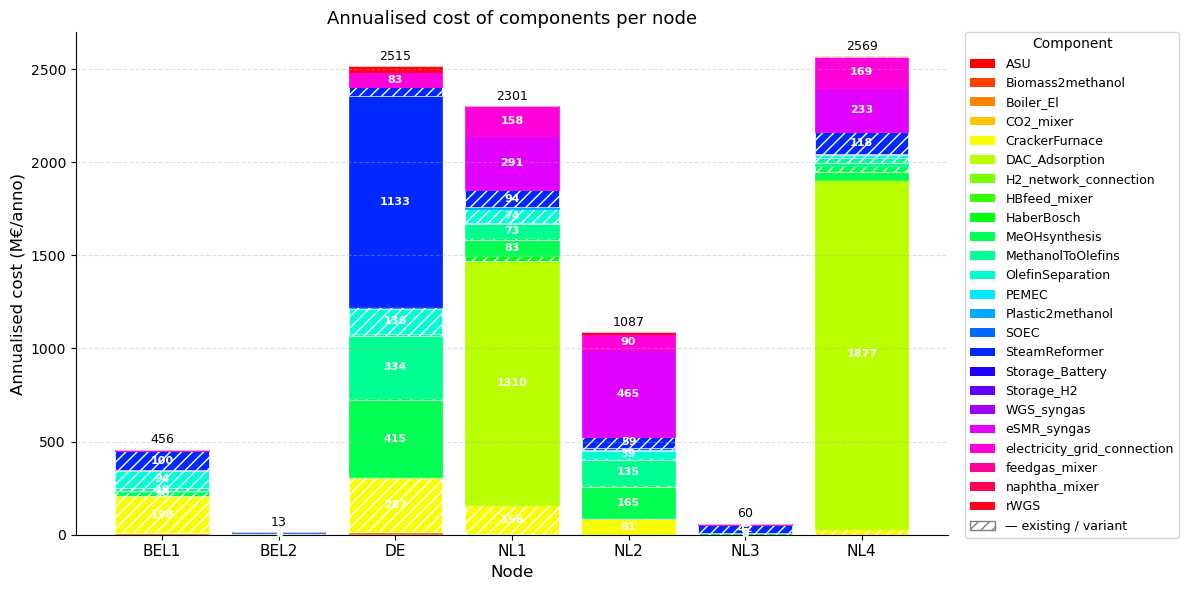

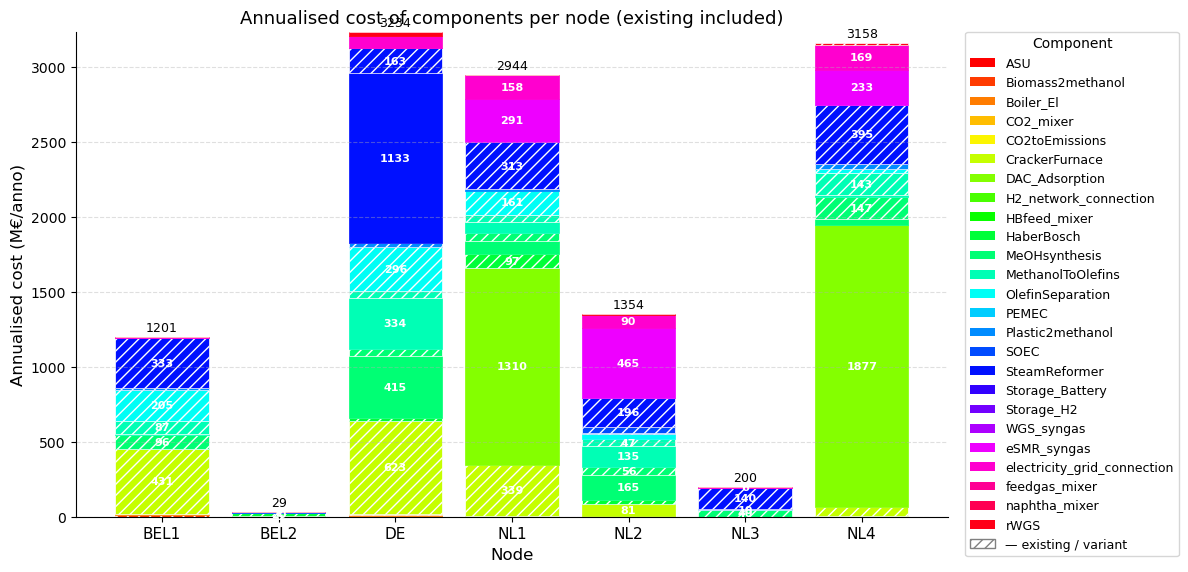

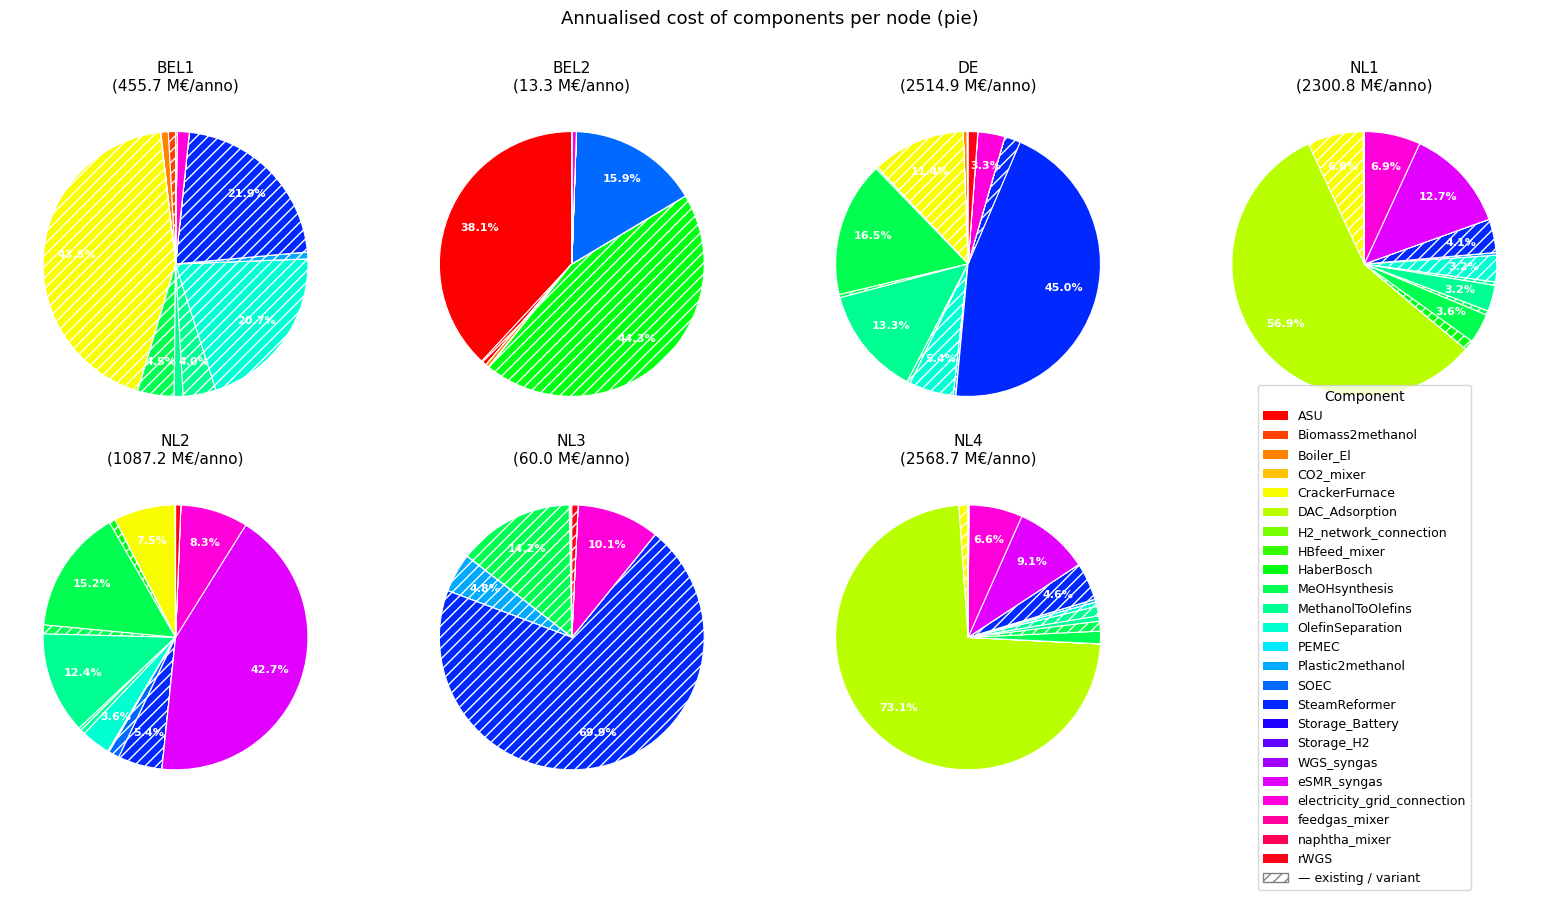

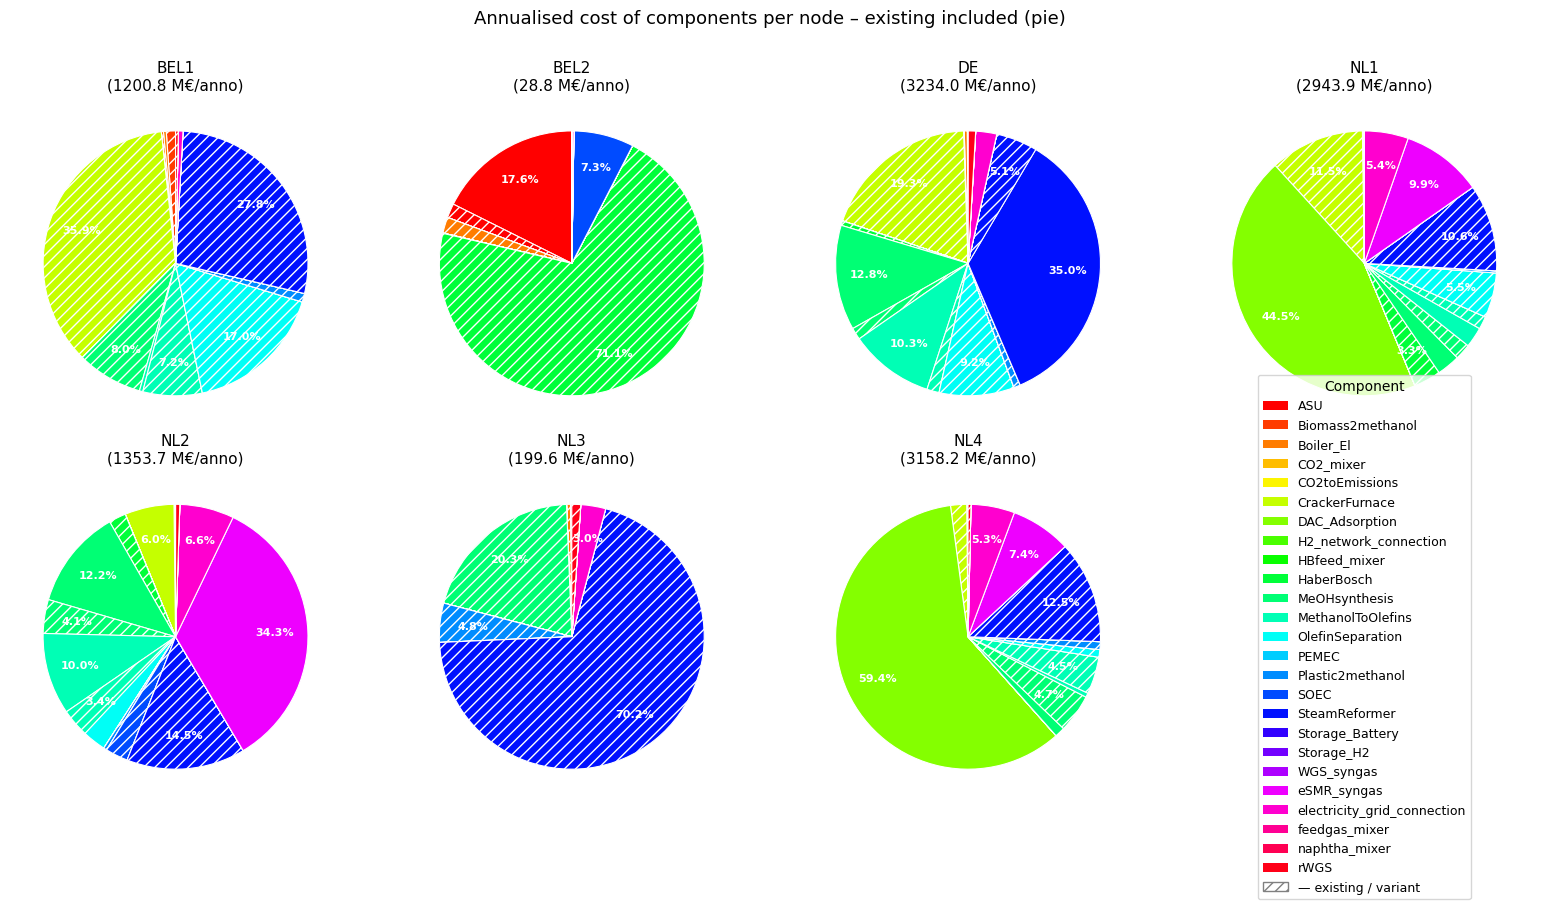

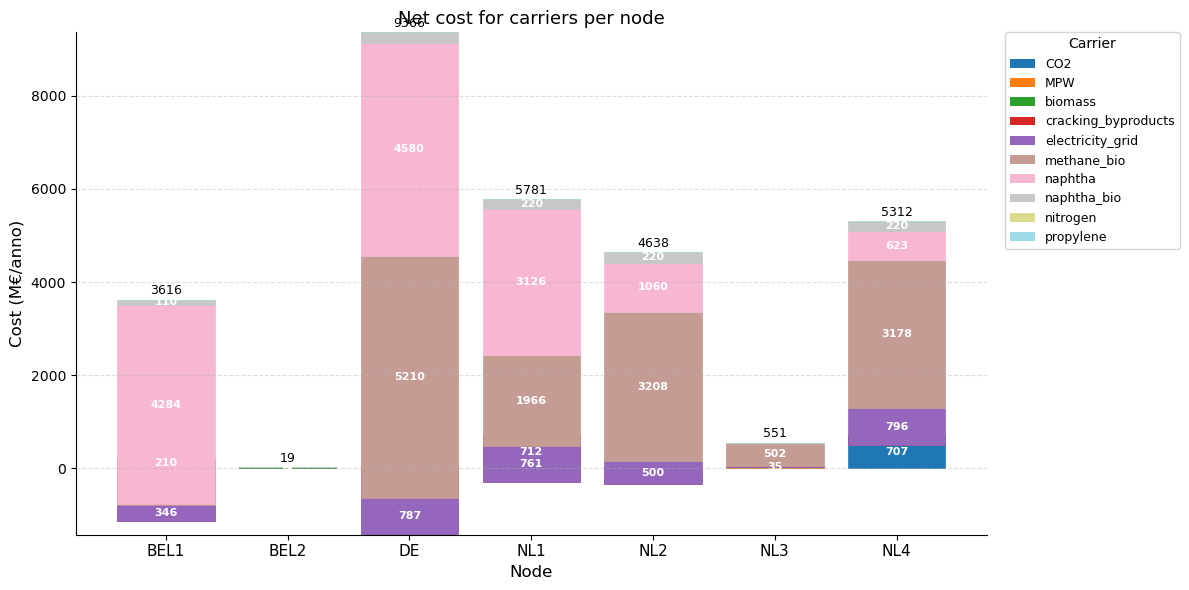

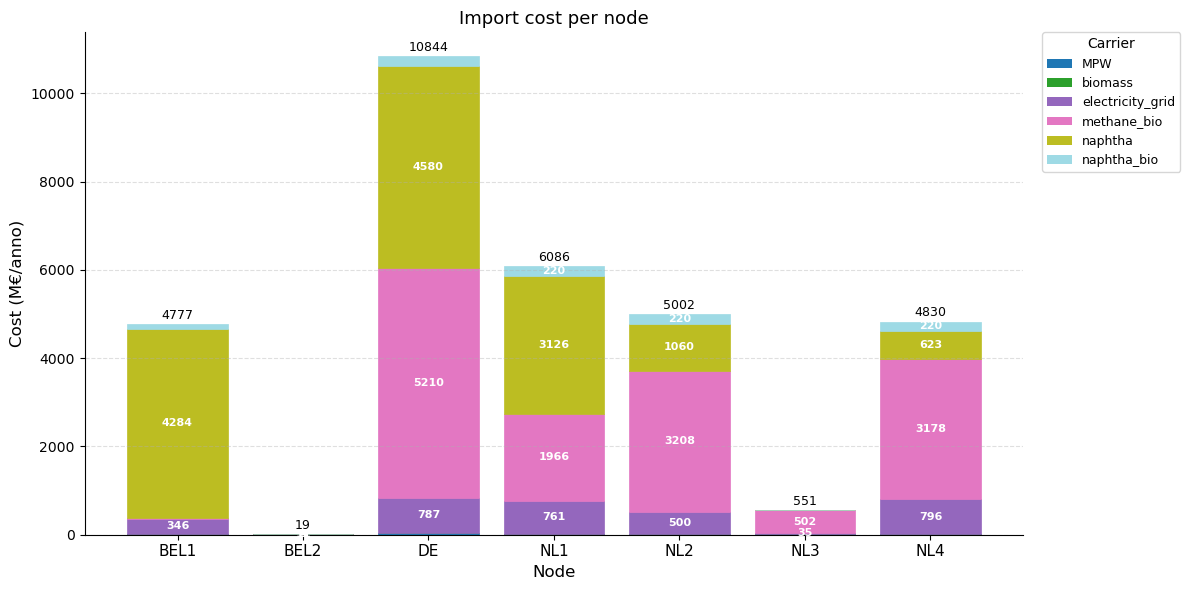

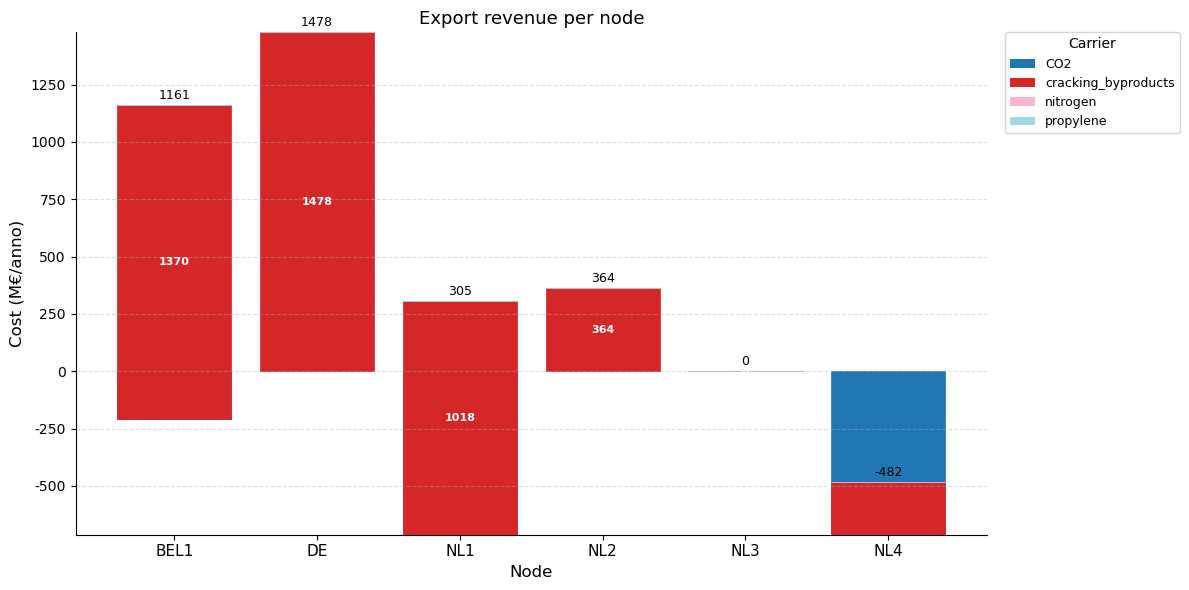

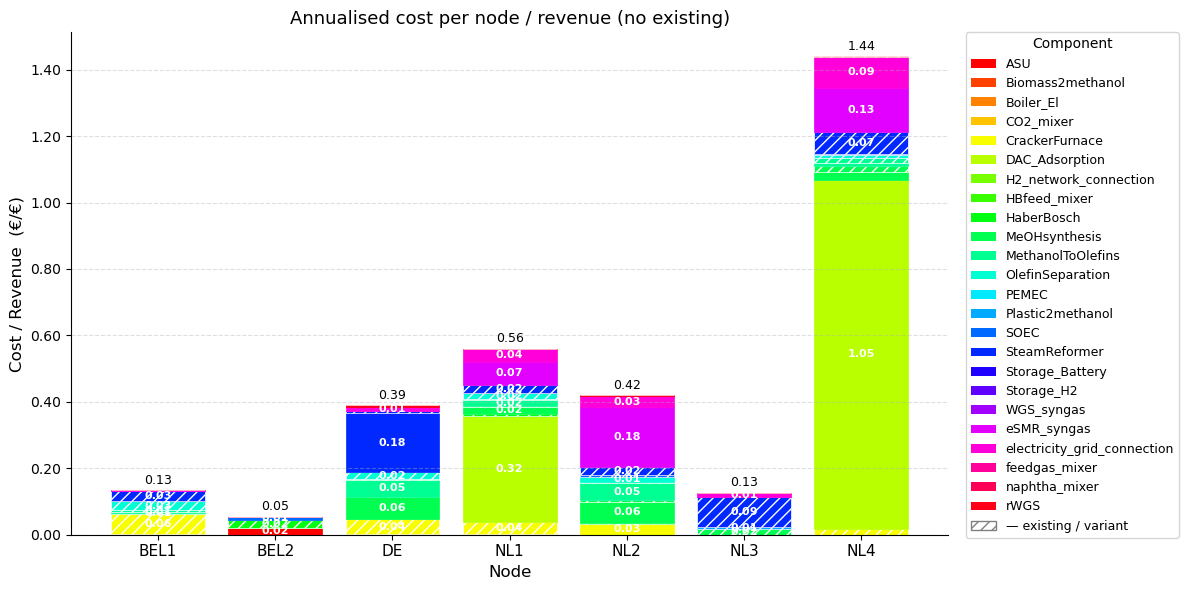

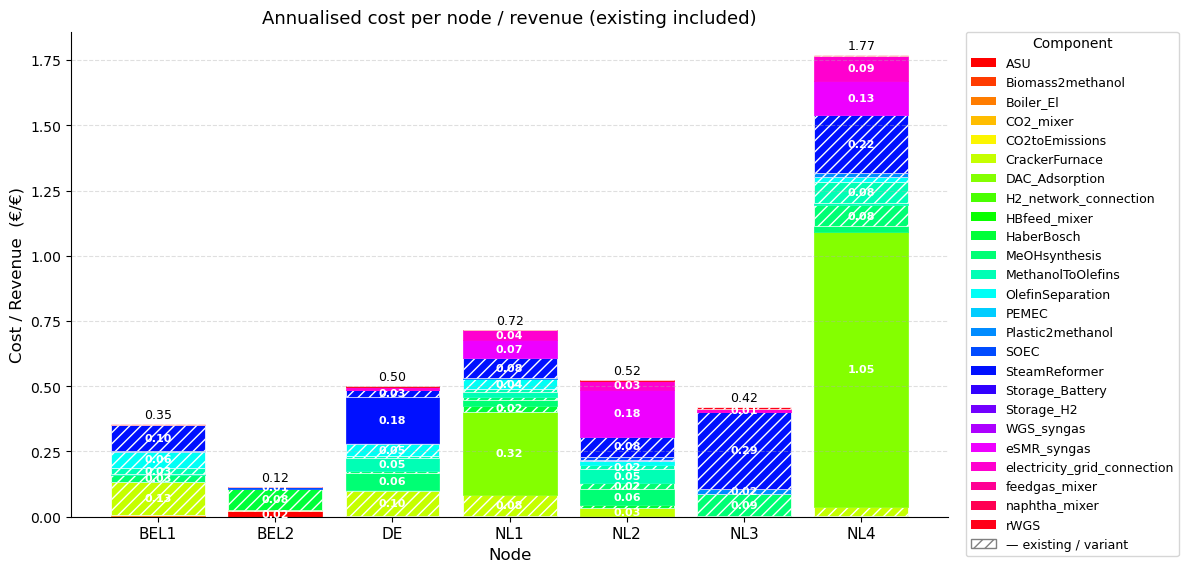

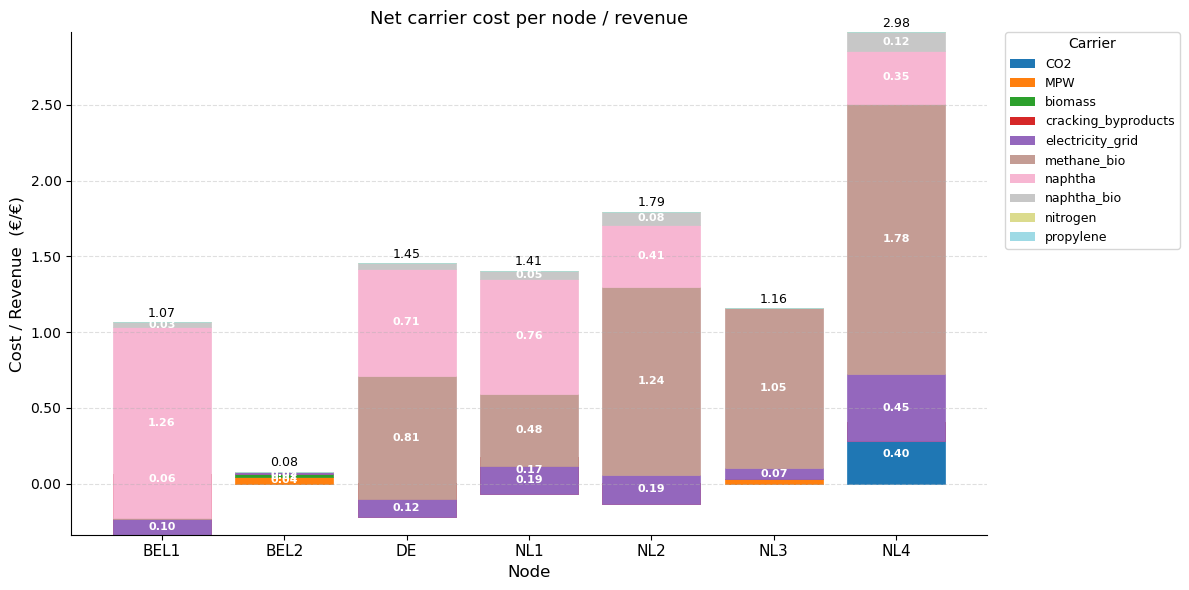

In [19]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


# ─────────────────────────────────────────────
#  HDF5 helpers
# ─────────────────────────────────────────────

def _to_scalar(x):
    """HDF5 dataset -> python scalar, decodes bytes."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


def _annualise(unit_capex: float, size: float,
               discount_rate: float, lifetime: int) -> float:
    """
    Evaluates annualised CAPEX for a component of given size, using the formula:
        CRF = r*(1+r)^n / ((1+r)^n - 1)
        annualized_capex = unit_capex * size * CRF
    where r = discount_rate, n = lifetime.
    """
    r, n = discount_rate, lifetime
    crf = r * (1 + r)**n / ((1 + r)**n - 1)
    return unit_capex * size * crf


def _find_json_recursive(technology_data_root: str | Path, tec_name: str) -> Path | None:
    """
    Searches recursively in technology_data_root for a file named '{tec_name}.json'.
    Returns the Path if found, else None. If multiple matches are found, a warning is printed and the first one is returned.
    """
    root = Path(technology_data_root)
    matches = list(root.rglob(f"{tec_name}.json"))
    if not matches:
        return None
    if len(matches) > 1:
        print(f"[Warning] Found {len(matches)} files for '{tec_name}', using the first: {matches[0]}")
    return matches[0]

def _aggregate_network_components(df: pd.DataFrame) -> pd.DataFrame:
    """
    Raggruppa i componenti il cui nome inizia con uno dei prefissi in
    _NETWORK_COMPONENT_PREFIXES seguito da '_qualcosa', rinominandoli
    al solo prefisso base. Il successivo pivot_table sommerà automaticamente
    le righe con lo stesso nome nodo+componente.
    """
    import re

    d = df.copy()
    patterns = [
        (re.compile(rf"^{re.escape(p)}_.+$"), p)
        for p in _NETWORK_COMPONENT_PREFIXES
    ]
    def _rename(name: str) -> str:
        for pat, base in patterns:
            if pat.match(name):
                return base
        return name
    d["component"] = d["component"].apply(_rename)
    return d


def create_base_df(h5_path: str | Path, year: str = "2022") -> pd.DataFrame:
    """Returns all (node, component) pairs under design/nodes/{year}."""
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for node in f[base].keys():
            for comp in f[base][node].keys():
                rows.append({"node": str(node), "component": str(comp)})
    return pd.DataFrame(rows)


def load_technologies_design_results(
    dataset_name: str, # e.g. 'capex_tot', 'opex_fixed', 'opex_variable'
    h5_path: str | Path,
    year: str = "2022",
    base_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Adds a column with dataset_name values to base_df."""
    h5_path = Path(h5_path)
    df = base_df.copy() if base_df is not None else pd.DataFrame()
    df[dataset_name] = np.nan
    base = f"design/nodes/{year}"
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for node in f[base].keys():
            for comp in f[base][node].keys():
                ds_path = f"{base}/{node}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    mask = (df["node"] == str(node)) & (df["component"] == str(comp))
                    df.loc[mask, dataset_name] = float(val) if val is not None else np.nan
    return df

def load_existing_annualized_capex(
    h5_path: str | Path,
    technology_data_root: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    For each component with suffix '_existing' under design/nodes/{year}, reads its 'size' from the HDF5 and the economic parameters from the corresponding JSON in technology_data_root,
    then computes the annualized CAPEX using the _annualise() function.
    Returns a DataFrame with columns:
        node, component, size, unit_capex, discount_rate, lifetime, annualized_capex_existing
        where 'component' is the full name with '_existing' suffix, and 'annualized_capex_existing' is the computed annualized CAPEX for that component.
    """
    h5_path = Path(h5_path)
    base    = f"design/nodes/{year}"
    rows    = []

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")

        for node in f[base].keys():
            for comp in f[base][node].keys():
                if not comp.endswith("_existing"):
                    continue

                # ── size from the h5 ──────────────────────────────
                size_path = f"{base}/{node}/{comp}/size"
                if size_path not in f:
                    print(f"[Warning] 'size' not found for {node}/{comp}, skip.")
                    continue
                size = float(_to_scalar(f[size_path][()]))

                # ── json of the technology ─────────────────────
                tec_name = comp[: -len("_existing")]   # remove suffix to get technology name
                json_path = _find_json_recursive(technology_data_root, tec_name)
                if json_path is None:
                    print(f"[Warning] JSON not found for '{tec_name}', skip.")
                    continue

                with open(json_path, "r") as jf:
                    tec_data = json.load(jf)

                econ         = tec_data["Economics"]
                unit_capex   = float(econ["unit_capex"])
                discount_rate = float(econ["discount_rate"])
                lifetime     = int(econ["lifetime"])

                ann_capex = _annualise(unit_capex, size, discount_rate, lifetime)

                rows.append({
                    "node":                      str(node),
                    "component":                 str(comp),
                    "size":                      size,
                    "unit_capex":                unit_capex,
                    "discount_rate":             discount_rate,
                    "lifetime":                  lifetime,
                    "annualized_capex_existing": ann_capex,
                })

    return pd.DataFrame(rows)


def load_networks_design_results(
    dataset_name: str,
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """Reads design/networks/{year}/... and splits capex 50/50 between fromNode and toNode."""
    h5_path = Path(h5_path)
    base = f"design/networks/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        for network in f[base].keys():
            for edge_id in f[base][network].keys():
                edge_path = f"{base}/{network}/{edge_id}"
                from_node = _to_scalar(f[f"{edge_path}/fromNode"][()]) if f"{edge_path}/fromNode" in f else None
                to_node   = _to_scalar(f[f"{edge_path}/toNode"][()]) if f"{edge_path}/toNode" in f else None
                val = _to_scalar(f[f"{edge_path}/{dataset_name}"][()]) if f"{edge_path}/{dataset_name}" in f else np.nan
                val = float(val) / 2 if val is not None else np.nan
                rows.append({"node": str(from_node), "component": str(network), dataset_name: val})
                rows.append({"node": str(to_node),   "component": str(network), dataset_name: val})

    df = pd.DataFrame(rows)
    df = df.groupby(["node", "component"], as_index=False)[dataset_name].sum()
    return df


# ─────────────────────────────────────────────
#  Annual cost: capex_tot + opex_fixed + opex_variable
# ─────────────────────────────────────────────

def compute_annual_cost(
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    For every (node, component) reads three datasets from design/nodes/{year}:
        capex_tot      — already annualised CAPEX  (€/year)
        opex_fixed     — fixed operating cost      (€/year)
        opex_variable  — variable operating cost   (€/year)

    Returns a DataFrame with columns:
        node, component, capex_tot, opex_fixed, opex_variable, annual_cost

    where annual_cost = capex_tot + opex_fixed + opex_variable.
    Rows where all three are zero or NaN are kept; filtering is left to the caller.
    """
    base = create_base_df(h5_path, year=year)
    for col in ("capex_tot", "opex_fixed", "opex_variable"):
        base = load_technologies_design_results(col, h5_path, year=year, base_df=base)

    base["annual_cost"] = (
        base["capex_tot"].fillna(0)
        + base["opex_fixed"].fillna(0)
        + base["opex_variable"].fillna(0)
    )
    return base

def compute_annual_cost_with_existing(
    h5_path: str | Path,
    technology_data_root: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    As compute_annual_cost, but for '_existing' technologies replaces capex_tot (which is 0 in the HDF5) with the annualized_capex computed from the JSON.
    Returns the same columns as compute_annual_cost:
        node, component, capex_tot, opex_fixed, opex_variable, annual_cost
    """
    df = compute_annual_cost(h5_path, year=year)

    existing_capex = load_existing_annualized_capex(h5_path, technology_data_root, year=year)

    if existing_capex.empty:
        return df

    # Merging and substitution of capex_tot for the _existing rows
    df = df.merge(
        existing_capex[["node", "component", "annualized_capex_existing"]],
        on=["node", "component"],
        how="left",
    )
    mask = df["annualized_capex_existing"].notna()
    df.loc[mask, "capex_tot"] = df.loc[mask, "annualized_capex_existing"]
    df["annual_cost"] = (
        df["capex_tot"].fillna(0)
        + df["opex_fixed"].fillna(0)
        + df["opex_variable"].fillna(0)
    )
    df = df.drop(columns=["annualized_capex_existing"])
    return df


# ─────────────────────────────────────────────
#  Import / Export cost loader
# ─────────────────────────────────────────────

def load_import_export_costs(
    h5_path: str | Path,
    year: str = "2022",
) -> pd.DataFrame:
    """
    For every (node, carrier) pair computes the annual import and export costs
    using the k-means weighting factors stored in k_means_specs/{year}/factors.

    Annual cost formula (weighted sum over typical-day timesteps):
        import_cost  = sum_t( import[t]  * import_price[t]  * factor[t] )
        export_cost  = sum_t( export[t]  * export_price[t]  * factor[t] )
        net_cost     = import_cost - export_cost   (positive = net spend)

    Returns a DataFrame with columns:
        node, carrier, import_cost, export_cost, net_cost
    """
    h5_path = Path(h5_path)
    rows = []

    with h5py.File(h5_path, "r") as f:
        factors_path = f"k_means_specs/{year}/factors"
        if factors_path not in f:
            raise KeyError(f"Path '{factors_path}' not found in the file.")
        factors = np.array(f[factors_path], dtype=float)

        eb_base = f"operation/energy_balance/{year}"
        if eb_base not in f:
            raise KeyError(f"Path '{eb_base}' not found in the file.")

        for node in f[eb_base].keys():
            for carrier in f[eb_base][node].keys():
                carrier_path = f"{eb_base}/{node}/{carrier}"

                imp       = np.array(f[f"{carrier_path}/import"],       dtype=float)
                exp       = np.array(f[f"{carrier_path}/export"],       dtype=float)
                imp_price = np.array(f[f"{carrier_path}/import_price"], dtype=float)
                exp_price = np.array(f[f"{carrier_path}/export_price"], dtype=float)

                import_cost = float(np.sum(imp * imp_price * factors))
                export_cost = float(np.sum(exp * exp_price * factors))

                rows.append({
                    "node":        str(node),
                    "carrier":     str(carrier),
                    "import_cost": import_cost,
                    "export_cost": export_cost,
                    "net_cost":    import_cost - export_cost,
                })

    return pd.DataFrame(rows)


def revenues_from_chemicals(
    h5_path: str | Path,
    chemical_prices: dict[str, float],
    year: str = "2022",
) -> pd.DataFrame:
    """
    For each node, computes the annual revenue from chemical production.
 
    For each chemical in chemical_prices, reads the 'demand' array from
    operation/energy_balance/{year}/{node}/{chemical}/demand, weights it
    with the k-means factors (same approach as load_import_export_costs),
    and multiplies by the price in €/tonne.
 
    Parameters
    ----------
    h5_path : path to the HDF5 file
    chemical_prices : dict mapping chemical name -> price in €/tonne
                      e.g. {'ammonia': 578, 'methanol': 527, ...}
    year : scenario year (default "2022")
 
    Returns
    -------
    DataFrame with columns:
        node, <chemical_1>, <chemical_2>, ..., total_revenue
    where each chemical column is the annual revenue in € for that node.
    """
    h5_path = Path(h5_path)
    rows = []
 
    with h5py.File(h5_path, "r") as f:
        # Load k-means weighting factors (same as in load_import_export_costs)
        factors_path = f"k_means_specs/{year}/factors"
        if factors_path not in f:
            raise KeyError(f"Path '{factors_path}' not found in the file.")
        factors = np.array(f[factors_path], dtype=float)
 
        eb_base = f"operation/energy_balance/{year}"
        if eb_base not in f:
            raise KeyError(f"Path '{eb_base}' not found in the file.")
 
        for node in f[eb_base].keys():
            row = {"node": str(node)}
            for chemical, price in chemical_prices.items():
                demand_path = f"{eb_base}/{node}/{chemical}/demand"
                export_path = f"{eb_base}/{node}/{chemical}/export"
                if demand_path in f:
                    demand = np.array(f[demand_path], dtype=float)
                    # Weighted sum over typical-day timesteps, same as import/export
                else:
                    demand = np.zeros_like(factors)
                if export_path in f:
                    export = np.array(f[export_path], dtype=float)
                else:
                    export = np.zeros_like(factors)
                annual_production = float(np.sum(demand * factors) + np.sum(export * factors))
                row[chemical] = annual_production * price
            rows.append(row)
 
    df = pd.DataFrame(rows)
 
    # Total revenue per node (sum across all chemicals)
    chemical_cols = list(chemical_prices.keys())
    df["total_revenue"] = df[chemical_cols].sum(axis=1)
 
    return df


# ─────────────────────────────────────────────
#  Color + hatch palette
# ─────────────────────────────────────────────

_HATCH_PATTERN = "///"
_KNOWN_SUFFIXES = ["_existing", "_new", "_ccs"]
_NETWORK_COMPONENT_PREFIXES = [
    "H2_network_connection",
    "electricity_grid_connection",
]


def _strip_suffix(name: str) -> str:
    for suffix in _KNOWN_SUFFIXES:
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return name


def _has_suffix(name: str) -> bool:
    return any(name.endswith(s) for s in _KNOWN_SUFFIXES)


def _build_palette(
    components: list[str],
    cmap_name: str = "tab20",
) -> tuple[dict[str, str], dict[str, str]]:
    """
    Returns (color_map, hatch_map) keyed on component name.
    Colors assigned to base names; variants share the color but get hatch.
    """
    seen: dict[str, None] = {}
    for comp in components:
        seen[_strip_suffix(comp)] = None
    base_names = list(seen.keys())

    n = len(base_names)
    cmap   = plt.get_cmap(cmap_name) if n <= 20 else plt.get_cmap("hsv")
    colors = [mcolors.to_hex(cmap(i / max(n - 1, 1))) for i in range(n)]

    base_color = dict(zip(base_names, colors))
    color_map  = {comp: base_color[_strip_suffix(comp)] for comp in components}
    hatch_map  = {comp: (_HATCH_PATTERN if _has_suffix(comp) else "") for comp in components}
    return color_map, hatch_map


def _build_simple_palette(items: list[str], cmap_name: str = "tab20") -> dict[str, str]:
    n = len(items)
    cmap   = plt.get_cmap(cmap_name) if n <= 20 else plt.get_cmap("hsv")
    colors = [mcolors.to_hex(cmap(i / max(n - 1, 1))) for i in range(n)]
    return dict(zip(items, colors))


# ─────────────────────────────────────────────
#  Generic stacked bar plot
# ─────────────────────────────────────────────

def _plot_stacked(
    pivot: pd.DataFrame,
    color_map: dict[str, str],
    hatch_map: dict[str, str] | None,
    ax: plt.Axes,
    min_fraction_label: float,
    value_decimals: int = 0,
):
    hatch_map = hatch_map or {c: "" for c in pivot.columns}
    x       = np.arange(len(pivot.index))
    bottoms = np.zeros(len(pivot.index))

    for comp in pivot.columns:
        values = pivot[comp].values
        bars   = ax.bar(
            x, values, bottom=bottoms,
            color=color_map[comp],
            hatch=hatch_map[comp],
            edgecolor="white" if hatch_map[comp] else color_map[comp],
            linewidth=0.5,
            label=comp,
        )
        node_totals = pivot.sum(axis=1).values
        for i, (bar, v) in enumerate(zip(bars, values)):
            if node_totals[i] > 0 and v / node_totals[i] >= min_fraction_label:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottoms[i] + v / 2,
                    f"{v:.{value_decimals}f}",
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold",
                )
        bottoms += values

    for i, total in enumerate(pivot.sum(axis=1).values):
        ax.text(
            x[i], total + 0.01 * (pivot.values.max() or 1),
            f"{total:.{value_decimals}f}",
            ha="center", va="bottom", fontsize=9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=0, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{value_decimals}f}"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)


# ─────────────────────────────────────────────
#  Plot: annualised cost per node and component
# ─────────────────────────────────────────────

def plot_stacked_annual_cost_by_node(
    df: pd.DataFrame,
    cost_col: str = "annual_cost",
    node_order: list[str] | None = None,
    top_n_components: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "Annualised cost of components per node",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
):
    """
    Stacked bar chart: x=node, stack=component, y=annual_cost.
    annual_cost = capex_tot + opex_fixed + opex_variable (all already in €/year).
    Components with a known suffix (_existing, _new, …) share the base color
    but are drawn with diagonal hatch stripes.
    """
    d = df.copy()
    d = _aggregate_network_components(d)
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col] > 0]
    d[cost_col] /= scale

    pivot = d.pivot_table(index="node", columns="component",
                          values=cost_col, aggfunc="sum", fill_value=0.0)

    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()

    if top_n_components is not None:
        base_totals = (
            pivot.rename(columns=_strip_suffix).T.groupby(level=0).sum().T
            .sum(axis=0).sort_values(ascending=False)
        )
        keep_bases = set(base_totals.index[:top_n_components])
        keep_cols  = [c for c in pivot.columns if _strip_suffix(c) in keep_bases]
        other      = pivot[[c for c in pivot.columns if c not in keep_cols]].sum(axis=1)
        pivot      = pivot[keep_cols].copy()
        if (other > 0).any():
            pivot["Other"] = other

    components           = list(pivot.columns)
    color_map, hatch_map = _build_palette(components, cmap_name)

    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label)

    ax.set_ylabel(f"Annualised cost ({scale_label})", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)

    legend_handles = []
    seen_bases: set[str] = set()
    for comp in components:
        base = _strip_suffix(comp)
        if base not in seen_bases:
            seen_bases.add(base)
            legend_handles.append(mpatches.Patch(facecolor=color_map[comp], label=base))
    if any(v for v in hatch_map.values()):
        legend_handles.append(
            mpatches.Patch(facecolor="white", edgecolor="gray",
                           hatch=_HATCH_PATTERN, label="— existing / variant")
        )
    ax.legend(handles=legend_handles, title="Component",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)

    plt.tight_layout()
    # plt.savefig("annual_cost_stacked.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_pie_annual_cost_by_node(
    df: pd.DataFrame,
    cost_col: str = "annual_cost",
    node_order: list[str] | None = None,
    top_n_components: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "Annualised cost of components per node",
    figsize: tuple[int, int] | None = None,
    min_fraction_label: float = 0.03,
):
    """
    Grid of pie charts: one pie per node, slices = components.
    Uses the same color/hatch palette as plot_stacked_annual_cost_by_node.
    """
    d = df.copy()
    d = _aggregate_network_components(d)
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col] > 0]
    d[cost_col] /= scale

    pivot = d.pivot_table(
        index="node", columns="component",
        values=cost_col, aggfunc="sum", fill_value=0.0,
    )

    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()

    if top_n_components is not None:
        base_totals = (
            pivot.rename(columns=_strip_suffix).T.groupby(level=0).sum().T
            .sum(axis=0).sort_values(ascending=False)
        )
        keep_bases = set(base_totals.index[:top_n_components])
        keep_cols  = [c for c in pivot.columns if _strip_suffix(c) in keep_bases]
        other      = pivot[[c for c in pivot.columns if c not in keep_cols]].sum(axis=1)
        pivot      = pivot[keep_cols].copy()
        if (other > 0).any():
            pivot["Other"] = other

    components           = list(pivot.columns)
    color_map, hatch_map = _build_palette(components, cmap_name)
    colors               = [color_map[c] for c in components]
    hatches              = [hatch_map[c] for c in components]

    nodes   = list(pivot.index)
    n_nodes = len(nodes)

    # Layout: try to make a roughly square grid
    n_cols = min(n_nodes, 4)
    n_rows = int(np.ceil(n_nodes / n_cols))

    if figsize is None:
        figsize = (n_cols * 4, n_rows * 4)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes_flat = np.array(axes).flatten()

    for ax, node in zip(axes_flat, nodes):
        values = pivot.loc[node].values
        total  = values.sum()

        # Only show label on slices above min_fraction_label
        def _autopct(pct):
            return f"{pct:.1f}%" if pct / 100 >= min_fraction_label else ""

        wedges, texts, autotexts = ax.pie(
            values,
            colors=colors,
            autopct=_autopct,
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 0.8},
            pctdistance=0.75,
        )
        # Apply hatch patterns to wedges
        for wedge, hatch in zip(wedges, hatches):
            wedge.set_hatch(hatch)

        for autotext in autotexts:
            autotext.set_fontsize(8)
            autotext.set_color("white")
            autotext.set_fontweight("bold")

        ax.set_title(f"{node}\n({total:.1f} {scale_label})", fontsize=11)

    # Hide unused axes
    for ax in axes_flat[n_nodes:]:
        ax.set_visible(False)

    # Shared legend (same logic as the bar chart)
    legend_handles = []
    seen_bases: set[str] = set()
    for comp in components:
        base = _strip_suffix(comp)
        if base not in seen_bases:
            seen_bases.add(base)
            legend_handles.append(mpatches.Patch(facecolor=color_map[comp], label=base))
    if any(v for v in hatch_map.values()):
        legend_handles.append(
            mpatches.Patch(facecolor="white", edgecolor="gray",
                           hatch=_HATCH_PATTERN, label="— existing / variant")
        )

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()

    # Metti la legenda nell'ultimo axes vuoto, se esiste
    empty_axes = axes_flat[n_nodes:]
    if len(empty_axes) > 0:
        legend_ax = empty_axes[-1]
        legend_ax.set_visible(True)
        legend_ax.axis("off")
        legend_ax.legend(
            handles=legend_handles,
            title="Component",
            loc="center",
            fontsize=9,
            frameon=True,
        )
    else:
        # Fallback: legenda fuori dalla figura in basso
        fig.legend(
            handles=legend_handles,
            title="Component",
            loc="lower center",
            ncol=min(len(legend_handles), 5),
            fontsize=9,
            bbox_to_anchor=(0.5, -0.02),
        )

    plt.show()


# ─────────────────────────────────────────────
#  Plot: costs for import/export by node and carrier
# ─────────────────────────────────────────────

def plot_stacked_import_export_by_node(
    df: pd.DataFrame,
    cost_col: str = "net_cost",
    node_order: list[str] | None = None,
    top_n_carriers: int | None = None,
    drop_zeros: bool = True,
    scale: float = 1e6,
    scale_label: str = "M€/anno",
    cmap_name: str = "tab20",
    title: str = "Import/export costs by node",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
):
    """
    Stacked bar chart of import/export costs by node and carrier.
    cost_col: 'import_cost', 'export_cost', or 'net_cost'.
    """
    d = df.copy()
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col].abs() > 0]
    d[cost_col] /= scale

    pivot = d.pivot_table(index="node", columns="carrier",
                          values=cost_col, aggfunc="sum", fill_value=0.0)

    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()

    if top_n_carriers is not None and pivot.shape[1] > top_n_carriers:
        totals = pivot.abs().sum(axis=0).sort_values(ascending=False)
        keep   = totals.index[:top_n_carriers].tolist()
        other  = pivot.drop(columns=keep).sum(axis=1)
        pivot  = pivot[keep].copy()
        if (other.abs() > 0).any():
            pivot["Other"] = other

    carriers  = list(pivot.columns)
    color_map = _build_simple_palette(carriers, cmap_name)
    hatch_map = {c: "" for c in carriers}

    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label)

    ax.set_ylabel(f"Cost ({scale_label})", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)

    legend_handles = [mpatches.Patch(facecolor=color_map[c], label=c) for c in carriers]
    ax.legend(handles=legend_handles, title="Carrier",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)

    plt.tight_layout()
    # plt.savefig("import_export_costs.png", dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────
#  Normalised stacked bar plots
# ─────────────────────────────────────────────
 
def plot_stacked_annual_cost_normalised(
    cost_df: pd.DataFrame,
    revenue_df: pd.DataFrame,
    cost_col: str = "annual_cost",
    node_order: list[str] | None = None,
    top_n_components: int | None = None,
    drop_zeros: bool = True,
    cmap_name: str = "tab20",
    title: str = "Annualised cost per node (normalised by revenue)",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
    output_filename: str = "annual_cost_normalised.png",
):
    """
    Same as plot_stacked_annual_cost_by_node, but each cost value is divided
    by the total_revenue of that node.  Y-axis is therefore dimensionless
    (cost / revenue, i.e. €/€).
 
    Parameters
    ----------
    cost_df    : output of compute_annual_cost or compute_annual_cost_with_existing
    revenue_df : output of revenues_from_chemicals  (must have 'node' and 'total_revenue')
    All other parameters: same meaning as in plot_stacked_annual_cost_by_node.
    """
    d = cost_df.copy()
    d = _aggregate_network_components(d)
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col] > 0]
 
    # Build revenue map: node -> total_revenue
    rev_map = revenue_df.set_index("node")["total_revenue"].to_dict()
 
    # Divide each cost by the revenue of its node (skip nodes with zero/missing revenue)
    def _normalise(row):
        rev = rev_map.get(row["node"], 0.0)
        if rev > 0:
            return row[cost_col] / rev
        return np.nan
 
    d["cost_normalised"] = d.apply(_normalise, axis=1)
    d = d.dropna(subset=["cost_normalised"])
 
    pivot = d.pivot_table(
        index="node", columns="component",
        values="cost_normalised", aggfunc="sum", fill_value=0.0,
    )
 
    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()
 
    if top_n_components is not None:
        base_totals = (
            pivot.rename(columns=_strip_suffix).T.groupby(level=0).sum().T
            .sum(axis=0).sort_values(ascending=False)
        )
        keep_bases = set(base_totals.index[:top_n_components])
        keep_cols  = [c for c in pivot.columns if _strip_suffix(c) in keep_bases]
        other      = pivot[[c for c in pivot.columns if c not in keep_cols]].sum(axis=1)
        pivot      = pivot[keep_cols].copy()
        if (other > 0).any():
            pivot["Other"] = other
 
    components           = list(pivot.columns)
    color_map, hatch_map = _build_palette(components, cmap_name)
 
    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label, value_decimals=2)
 
    ax.set_ylabel("Cost / Revenue  (€/€)", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)
 
    legend_handles = []
    seen_bases: set[str] = set()
    for comp in components:
        base = _strip_suffix(comp)
        if base not in seen_bases:
            seen_bases.add(base)
            legend_handles.append(mpatches.Patch(facecolor=color_map[comp], label=base))
    if any(v for v in hatch_map.values()):
        legend_handles.append(
            mpatches.Patch(facecolor="white", edgecolor="gray",
                           hatch=_HATCH_PATTERN, label="— existing / variant")
        )
    ax.legend(handles=legend_handles, title="Component",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)
 
    plt.tight_layout()
    # plt.savefig(output_filename, dpi=150, bbox_inches="tight")
    plt.show()
 
 
def plot_stacked_import_export_normalised(
    ie_df: pd.DataFrame,
    revenue_df: pd.DataFrame,
    cost_col: str = "net_cost",
    node_order: list[str] | None = None,
    top_n_carriers: int | None = None,
    drop_zeros: bool = True,
    cmap_name: str = "tab20",
    title: str = "Import/export costs per node (normalised by revenue)",
    figsize: tuple[int, int] = (12, 6),
    min_fraction_label: float = 0.03,
    output_filename: str = "import_export_normalised.png",
):
    """
    Same as plot_stacked_import_export_by_node, but each cost value is divided
    by the total_revenue of that node.
 
    Parameters
    ----------
    ie_df      : output of load_import_export_costs
    revenue_df : output of revenues_from_chemicals  (must have 'node' and 'total_revenue')
    All other parameters: same meaning as in plot_stacked_import_export_by_node.
    """
    d = ie_df.copy()
    d[cost_col] = pd.to_numeric(d[cost_col], errors="coerce").fillna(0.0)
    if drop_zeros:
        d = d[d[cost_col].abs() > 0]
 
    # Build revenue map: node -> total_revenue
    rev_map = revenue_df.set_index("node")["total_revenue"].to_dict()
 
    def _normalise(row):
        rev = rev_map.get(row["node"], 0.0)
        if rev > 0:
            return row[cost_col] / rev
        return np.nan
 
    d["cost_normalised"] = d.apply(_normalise, axis=1)
    d = d.dropna(subset=["cost_normalised"])
 
    pivot = d.pivot_table(
        index="node", columns="carrier",
        values="cost_normalised", aggfunc="sum", fill_value=0.0,
    )
 
    if node_order is not None:
        valid = [n for n in node_order if n in pivot.index]
        pivot = pivot.reindex(valid + [n for n in pivot.index if n not in valid])
    else:
        pivot = pivot.sort_index()
 
    if top_n_carriers is not None and pivot.shape[1] > top_n_carriers:
        totals = pivot.abs().sum(axis=0).sort_values(ascending=False)
        keep   = totals.index[:top_n_carriers].tolist()
        other  = pivot.drop(columns=keep).sum(axis=1)
        pivot  = pivot[keep].copy()
        if (other.abs() > 0).any():
            pivot["Other"] = other
 
    carriers  = list(pivot.columns)
    color_map = _build_simple_palette(carriers, cmap_name)
    hatch_map = {c: "" for c in carriers}
 
    fig, ax = plt.subplots(figsize=figsize)
    _plot_stacked(pivot, color_map, hatch_map, ax, min_fraction_label, value_decimals=2)
 
    ax.set_ylabel("Cost / Revenue  (€/€)", fontsize=12)
    ax.set_xlabel("Node", fontsize=12)
    ax.set_title(title, fontsize=13)
 
    legend_handles = [mpatches.Patch(facecolor=color_map[c], label=c) for c in carriers]
    ax.legend(handles=legend_handles, title="Carrier",
              bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=9)
 
    plt.tight_layout()
    # plt.savefig(output_filename, dpi=150, bbox_inches="tight")
    plt.show()


# ─────────────────────────────────────────────
#  Main
# ─────────────────────────────────────────────

if __name__ == "__main__":
    h5_path               = Path(r"output\base_case_5_dd\2040\optimization_results.h5")
    technology_data_root  = Path(r"adopt_net0\database\templates\technology_data")
    year                  = "2022"
    node_order            = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]

    chemicals_prices = {
        'ammonia': 621, # €/tonne, source: https://www.imarcgroup.com/ammonia-pricing-report
        'methanol': 560, # €/tonne, source: https://www.imarcgroup.com/methanol-pricing-report
        'ethylene': 1028, # €/tonne, source: https://www.imarcgroup.com/ethylene-pricing-report
        'propylene': 960, # €/tonne, source: https://www.imarcgroup.com/propylene-pricing-report
    }

    revenue_df = revenues_from_chemicals(h5_path, chemical_prices=chemicals_prices, year=year)

    # ── Plot 1: annualised cost per node and component (only optimised capex, existing = 0) ──
    cost_df = compute_annual_cost(h5_path, year=year)
    plot_stacked_annual_cost_by_node(
        cost_df,
        cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost of components per node",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Plot 2: as plot 1, but with annualised CAPEX for existing technologies ──
    cost_df_with_existing = compute_annual_cost_with_existing(
        h5_path, technology_data_root, year=year
    )
    plot_stacked_annual_cost_by_node(
        cost_df_with_existing,
        cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost of components per node (existing included)",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Plot 1b: pie chart versione del Plot 1 ──────────────────────────────
    plot_pie_annual_cost_by_node(
        cost_df,
        cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost of components per node (pie)",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Plot 2b: pie chart versione del Plot 2 (con existing) ───────────────
    plot_pie_annual_cost_by_node(
        cost_df_with_existing,
        cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost of components per node – existing included (pie)",
        scale=1e6, scale_label="M€/anno",
    )

    # ── Import/export plots ──────────────────────────────────────────────────────
    ie_costs = load_import_export_costs(h5_path, year=year)
    plot_stacked_import_export_by_node(
        ie_costs, cost_col="net_cost",
        node_order=node_order,
        title="Net cost for carriers per node",
        scale=1e6, scale_label="M€/anno",
    )
    plot_stacked_import_export_by_node(
        ie_costs, cost_col="import_cost",
        node_order=node_order,
        title="Import cost per node",
        scale=1e6, scale_label="M€/anno",
    )
    plot_stacked_import_export_by_node(
        ie_costs, cost_col="export_cost",
        node_order=node_order,
        title="Export revenue per node",
        scale=1e6, scale_label="M€/anno",
    )

    # Plot 4: costo annualizzato normalizzato (senza existing)
    plot_stacked_annual_cost_normalised(
        cost_df, revenue_df, cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost per node / revenue (no existing)",
        output_filename="annual_cost_normalised.png",
    )

    # Plot 5: costo annualizzato normalizzato (con existing)
    plot_stacked_annual_cost_normalised(
        cost_df_with_existing, revenue_df, cost_col="annual_cost",
        node_order=node_order,
        title="Annualised cost per node / revenue (existing included)",
        output_filename="annual_cost_with_existing_normalised.png",
    )

    # Plot 6: import/export normalizzato
    plot_stacked_import_export_normalised(
        ie_costs, revenue_df, cost_col="net_cost",
        node_order=node_order,
        title="Net carrier cost per node / revenue",
        output_filename="import_export_normalised.png",
    )

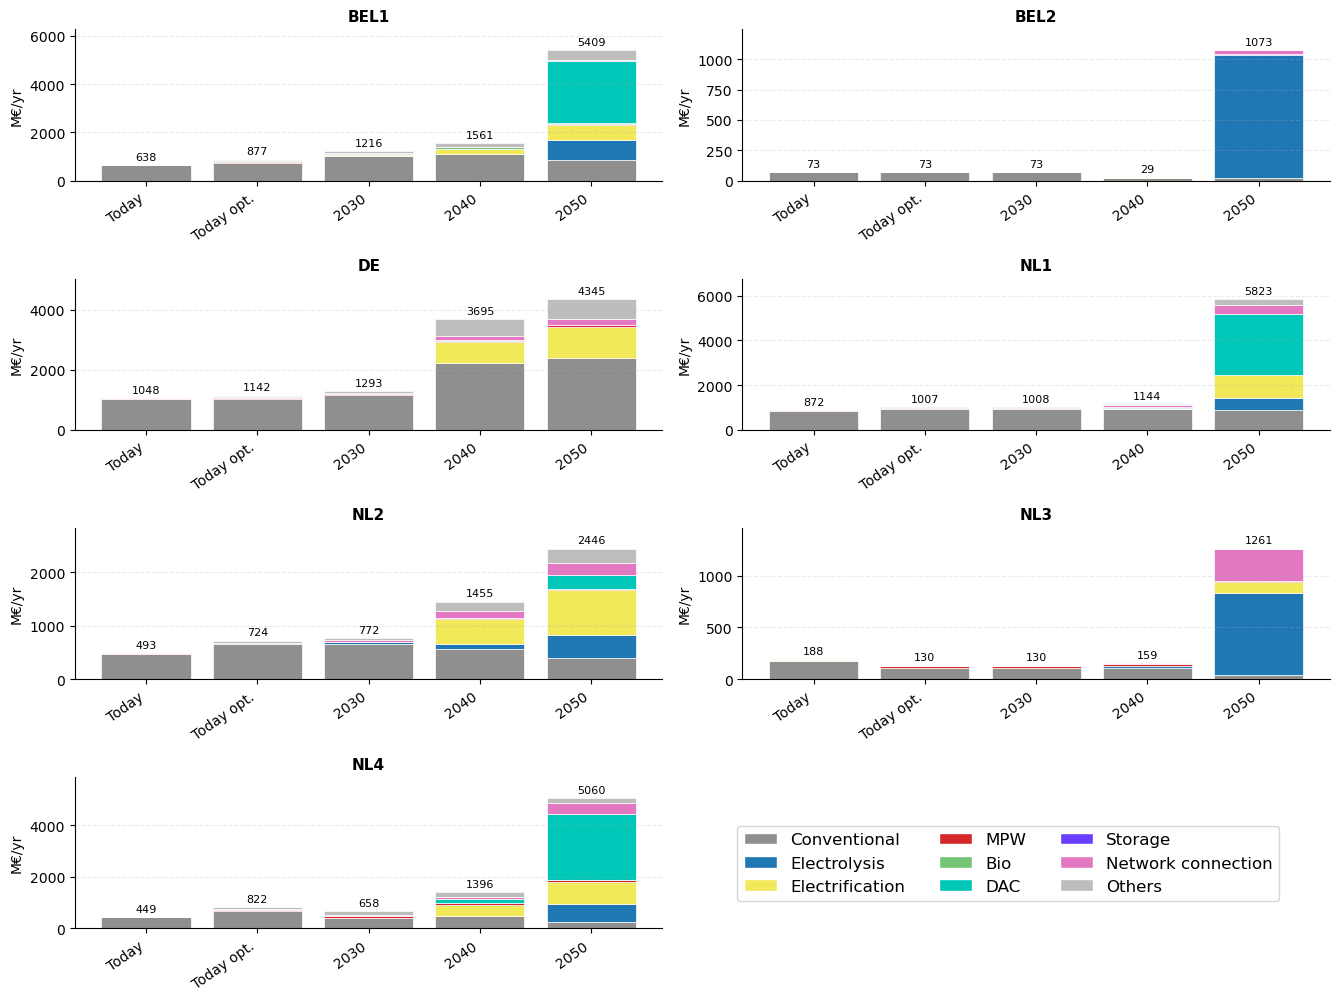

In [3]:
from __future__ import annotations

from pathlib import Path
import json
import re

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# =============================================================================
# User settings
# =============================================================================

H5_FILES = [
    Path(r"output/high_feedstock_availability_5_dd/2020/optimization_results.h5"),
    Path(r"output/high_feedstock_availability_5_dd/2025/optimization_results.h5"),
    Path(r"output/high_feedstock_availability_5_dd/2030/optimization_results.h5"),
    Path(r"output/high_feedstock_availability_5_dd/2040/optimization_results.h5"),
    Path(r"output/high_feedstock_availability_5_dd/2050/optimization_results.h5"),
]

TECHNOLOGY_DATA_ROOT = Path(r"adopt_net0\database\templates\technology_data")

INTERNAL_YEAR = "2022"

NODE_ORDER = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]

SCENARIO_LABELS = {
    2020: "Today",
    2025: "Today opt.",
    2030: "2030",
    2040: "2040",
    2050: "2050",
}

SCENARIO_ORDER = ["Today", "Today opt.", "2030", "2040", "2050"]

TECH_CLASSES = {
    "SOEC": "Electrolysis",
    "PEMEC": "Electrolysis",

    "HaberBosch": "Conventional",
    "SteamReformer": "Conventional",
    "CrackerFurnace": "Conventional",
    "OlefinSeparation": "Conventional",
    "MeOHsynthesis": "Conventional",

    "Storage_Battery": "Storage",
    "Storage_H2": "Storage",

    "HBfeed_mixer": "Others",
    "MethanolToOlefins": "Others",
    "feedgas_mixer": "Others",
    "HBfeed_splitter": "Others",
    "CO2_mixer": "Others",
    "naphtha_mixer": "Others",
    "CO2toEmissions": "Others",

    "ASU": "Electrification",
    "Boiler_El": "Electrification",
    "WGS_syngas": "Electrification",
    "eSMR_syngas": "Electrification",
    "eCrackerFurnace": "Electrification",
    "rWGS": "Electrification",

    "Plastic2methanol": "MPW",

    "Biomass2methanol": "Bio",

    "DAC_Adsorption": "DAC",

    "electricity_grid_connection_BE": "Network connection",
    "electricity_grid_connection_DE": "Network connection",
    "electricity_grid_connection_NL": "Network connection",
    "H2_network_connection_in": "Network connection",
    "H2_network_connection_out": "Network connection",
}

CLASS_ORDER = [
    "Conventional",
    "Electrolysis",
    "Electrification",
    "MPW",
    "Bio",
    "DAC",
    "Storage",
    "Network connection",
    "Others",
    "Unknown",
]

CLASS_COLORS = {
    "Conventional": "#8f8f8f",
    "Electrolysis": "#1f77b4",
    "Electrification": "#f1e85a",
    "Bio": "#74c476",
    "MPW": "#d62728",
    "DAC": "#00c7b7",
    "Storage": "#6a3dff",
    "Network connection": "#e377c2",
    "Others": "#bdbdbd",
    "Unknown": "#000000",
}


# =============================================================================
# Helpers
# =============================================================================

KNOWN_SUFFIXES = ["_existing", "_new", "_ccs"]


def to_scalar(x):
    """Convert HDF5 scalar-like datasets to Python scalars."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")

    if isinstance(x, np.generic):
        value = x.item()
        if isinstance(value, (bytes, bytearray)):
            return value.decode("utf-8")
        return value

    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        value = x.reshape(-1)[0].item()
        if isinstance(value, (bytes, bytearray)):
            return value.decode("utf-8")
        return value

    return x


def strip_known_suffix(component: str) -> str:
    """Remove known technology suffixes, e.g. SteamReformer_existing -> SteamReformer."""
    for suffix in KNOWN_SUFFIXES:
        if component.endswith(suffix):
            return component[: -len(suffix)]
    return component


def infer_scenario_year_from_path(h5_path: str | Path) -> int:
    """
    Infer scenario year from parent folders.
    Example:
        output/base_case_5_dd/2030/optimization_results.h5 -> 2030
    """
    h5_path = Path(h5_path)

    for parent in h5_path.parents:
        if re.fullmatch(r"(19|20)\d{2}", parent.name):
            return int(parent.name)

    match = re.search(r"(19|20)\d{2}", h5_path.stem)
    if match:
        return int(match.group(0))

    raise ValueError(f"Could not infer scenario year from path: {h5_path}")


def annualise(unit_capex: float, size: float, discount_rate: float, lifetime: int) -> float:
    """Annualise CAPEX using the capital recovery factor."""
    r = float(discount_rate)
    n = int(lifetime)

    if n <= 0:
        raise ValueError(f"Lifetime must be positive, got {n}")

    if abs(r) < 1e-12:
        crf = 1.0 / n
    else:
        crf = r * (1 + r) ** n / ((1 + r) ** n - 1)

    return float(unit_capex) * float(size) * crf


def find_json_recursive(technology_data_root: str | Path, technology_name: str) -> Path | None:
    """Find technology JSON named '<technology_name>.json' recursively."""
    root = Path(technology_data_root)
    matches = list(root.rglob(f"{technology_name}.json"))

    if not matches:
        return None

    if len(matches) > 1:
        print(f"[Warning] Multiple JSON files found for {technology_name}. Using: {matches[0]}")

    return matches[0]


def technology_class(component: str, tech_classes: dict[str, str]) -> str:
    """
    Map a component name to a technology class.
    Suffixes are stripped before mapping.
    """
    base = strip_known_suffix(component)
    return tech_classes.get(base, "Unknown")


# =============================================================================
# HDF5 extraction
# =============================================================================

def create_base_df(h5_path: str | Path, internal_year: str = INTERNAL_YEAR) -> pd.DataFrame:
    """Return all node/component pairs under design/nodes/{internal_year}."""
    h5_path = Path(h5_path)
    base_path = f"design/nodes/{internal_year}"

    rows = []

    with h5py.File(h5_path, "r") as h5:
        if base_path not in h5:
            raise KeyError(f"Path '{base_path}' not found in {h5_path}")

        for node in h5[base_path].keys():
            for component in h5[base_path][node].keys():
                rows.append({
                    "node": str(node),
                    "component": str(component),
                })

    return pd.DataFrame(rows)


def load_design_dataset(
    h5_path: str | Path,
    dataset_name: str,
    internal_year: str = INTERNAL_YEAR,
    base_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Load a design dataset for each node/component pair."""
    h5_path = Path(h5_path)
    base_path = f"design/nodes/{internal_year}"

    df = base_df.copy() if base_df is not None else create_base_df(h5_path, internal_year)
    df[dataset_name] = np.nan

    with h5py.File(h5_path, "r") as h5:
        if base_path not in h5:
            raise KeyError(f"Path '{base_path}' not found in {h5_path}")

        for node in h5[base_path].keys():
            for component in h5[base_path][node].keys():
                ds_path = f"{base_path}/{node}/{component}/{dataset_name}"

                if ds_path not in h5:
                    continue

                value = to_scalar(h5[ds_path][()])
                mask = (df["node"] == str(node)) & (df["component"] == str(component))
                df.loc[mask, dataset_name] = float(value)

    return df


def load_existing_annualised_capex(
    h5_path: str | Path,
    technology_data_root: str | Path,
    internal_year: str = INTERNAL_YEAR,
) -> pd.DataFrame:
    """
    For components ending with '_existing', compute annualised CAPEX from:
      - size in the HDF5 file;
      - unit_capex, discount_rate, lifetime in the corresponding JSON.
    """
    h5_path = Path(h5_path)
    base_path = f"design/nodes/{internal_year}"

    rows = []

    with h5py.File(h5_path, "r") as h5:
        if base_path not in h5:
            raise KeyError(f"Path '{base_path}' not found in {h5_path}")

        for node in h5[base_path].keys():
            for component in h5[base_path][node].keys():
                if not component.endswith("_existing"):
                    continue

                size_path = f"{base_path}/{node}/{component}/size"
                if size_path not in h5:
                    print(f"[Warning] Missing size for {node}/{component}. Skipping existing CAPEX.")
                    continue

                size = float(to_scalar(h5[size_path][()]))

                base_component = strip_known_suffix(component)
                json_path = find_json_recursive(technology_data_root, base_component)

                if json_path is None:
                    print(f"[Warning] JSON not found for '{base_component}'. Existing CAPEX set to zero.")
                    continue

                with open(json_path, "r") as f:
                    tech_data = json.load(f)

                try:
                    economics = tech_data["Economics"]
                    unit_capex = float(economics["unit_capex"])
                    discount_rate = float(economics["discount_rate"])
                    lifetime = int(economics["lifetime"])
                except KeyError as exc:
                    print(f"[Warning] Missing economic key {exc} in {json_path}. Skipping.")
                    continue

                capex_existing = annualise(
                    unit_capex=unit_capex,
                    size=size,
                    discount_rate=discount_rate,
                    lifetime=lifetime,
                )

                rows.append({
                    "node": str(node),
                    "component": str(component),
                    "annualised_capex_existing": capex_existing,
                })

    return pd.DataFrame(rows)


def compute_annual_technology_cost(
    h5_path: str | Path,
    technology_data_root: str | Path,
    internal_year: str = INTERNAL_YEAR,
    include_existing_capex: bool = True,
) -> pd.DataFrame:
    """
    Compute annual technology cost per node/component:
        annual_cost = capex_tot + opex_fixed + opex_variable

    If include_existing_capex=True, capex_tot for '_existing' technologies is
    replaced by the annualised CAPEX computed from the JSON data.
    """
    h5_path = Path(h5_path)

    df = create_base_df(h5_path, internal_year)

    for col in ["capex_tot", "opex_fixed", "opex_variable"]:
        df = load_design_dataset(
            h5_path=h5_path,
            dataset_name=col,
            internal_year=internal_year,
            base_df=df,
        )

    if include_existing_capex:
        existing = load_existing_annualised_capex(
            h5_path=h5_path,
            technology_data_root=technology_data_root,
            internal_year=internal_year,
        )

        if not existing.empty:
            df = df.merge(
                existing,
                on=["node", "component"],
                how="left",
            )

            mask_existing = df["annualised_capex_existing"].notna()
            df.loc[mask_existing, "capex_tot"] = df.loc[mask_existing, "annualised_capex_existing"]

            df = df.drop(columns=["annualised_capex_existing"])

    df["capex_tot"] = df["capex_tot"].fillna(0.0)
    df["opex_fixed"] = df["opex_fixed"].fillna(0.0)
    df["opex_variable"] = df["opex_variable"].fillna(0.0)

    df["annual_cost"] = df["capex_tot"] + df["opex_fixed"] + df["opex_variable"]

    scenario_year = infer_scenario_year_from_path(h5_path)
    df["scenario_year"] = scenario_year
    df["scenario_label"] = SCENARIO_LABELS.get(scenario_year, str(scenario_year))
    df["h5_file"] = str(h5_path)

    return df


def collect_all_technology_costs(
    h5_files: list[str | Path],
    technology_data_root: str | Path,
    internal_year: str = INTERNAL_YEAR,
    include_existing_capex: bool = True,
) -> pd.DataFrame:
    """Collect annual technology costs from all scenario files."""
    frames = []

    for h5_file in h5_files:
        h5_file = Path(h5_file)

        if not h5_file.exists():
            print(f"[Warning] File not found, skipped: {h5_file}")
            continue

        df = compute_annual_technology_cost(
            h5_path=h5_file,
            technology_data_root=technology_data_root,
            internal_year=internal_year,
            include_existing_capex=include_existing_capex,
        )
        frames.append(df)

    if not frames:
        raise FileNotFoundError("No valid H5 files were found.")

    return pd.concat(frames, ignore_index=True)


def aggregate_by_technology_class(
    raw_df: pd.DataFrame,
    tech_classes: dict[str, str],
    cost_col: str = "annual_cost",
    drop_zeros: bool = True,
) -> pd.DataFrame:
    """Aggregate component-level costs to technology classes."""
    df = raw_df.copy()

    df["base_component"] = df["component"].map(strip_known_suffix)
    df["technology_class"] = df["component"].map(lambda x: technology_class(x, tech_classes))

    df[cost_col] = pd.to_numeric(df[cost_col], errors="coerce").fillna(0.0)

    if drop_zeros:
        df = df[df[cost_col].abs() > 0]

    grouped = (
        df.groupby(
            ["node", "scenario_year", "scenario_label", "technology_class"],
            as_index=False,
        )[cost_col]
        .sum()
    )

    return grouped


def export_unknown_components(
    raw_df: pd.DataFrame,
    tech_classes: dict[str, str],
    output_path: str | Path,
) -> pd.DataFrame:
    """Export a diagnostic CSV with all unmapped components."""
    df = raw_df.copy()
    df["base_component"] = df["component"].map(strip_known_suffix)
    df["technology_class"] = df["component"].map(lambda x: technology_class(x, tech_classes))

    unknown = (
        df[df["technology_class"] == "Unknown"]
        .groupby(["base_component", "component"], as_index=False)["annual_cost"]
        .sum()
        .sort_values("annual_cost", ascending=False)
    )

    output_path = Path(output_path)
    # unknown.to_csv(output_path, index=False)

    return unknown


# =============================================================================
# Plotting
# =============================================================================

def plot_cluster_cost_transition_by_class(
    agg_df: pd.DataFrame,
    output_png: str | Path = "cluster_cost_transition_by_class.png",
    output_pdf: str | Path = "cluster_cost_transition_by_class.pdf",
    node_order: list[str] = NODE_ORDER,
    scenario_order: list[str] = SCENARIO_ORDER,
    class_order: list[str] = CLASS_ORDER,
    class_colors: dict[str, str] = CLASS_COLORS,
    scale: float = 1e6,
    scale_label: str = "M€/yr",
    min_fraction_label: float | None = 0.08,
    figsize: tuple[float, float] = (13.5, 11.5),
):
    """
    Small-multiple stacked bar plot:
      - one panel per node;
      - x = scenario;
      - stack = technology class;
      - y = annualised cost, not normalised;
      - each node has its own y-scale.
    """
    df = agg_df.copy()
    df["value_scaled"] = df["annual_cost"] / scale

    available_nodes = [node for node in node_order if node in set(df["node"])]
    extra_nodes = sorted(set(df["node"]) - set(available_nodes))
    nodes = available_nodes + extra_nodes

    n_nodes = len(nodes)
    n_cols = 2
    n_rows = int(np.ceil(n_nodes / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)

    legend_classes_used = set()

    for ax, node in zip(axes, nodes):
        sub = df[df["node"] == node]

        pivot = (
            sub.pivot_table(
                index="scenario_label",
                columns="technology_class",
                values="value_scaled",
                aggfunc="sum",
                fill_value=0.0,
            )
            .reindex(scenario_order)
            .fillna(0.0)
        )

        ordered_classes = [c for c in class_order if c in pivot.columns]
        extra_classes = [c for c in pivot.columns if c not in ordered_classes]
        ordered_classes += extra_classes

        pivot = pivot[ordered_classes]

        x = np.arange(len(pivot.index))
        bottom = np.zeros(len(pivot.index))
        totals = pivot.sum(axis=1).values

        for tech_class in ordered_classes:
            values = pivot[tech_class].values

            if np.all(np.abs(values) < 1e-12):
                continue

            color = class_colors.get(tech_class, "#333333")
            ax.bar(
                x,
                values,
                bottom=bottom,
                color=color,
                edgecolor="white",
                linewidth=0.5,
                label=tech_class,
            )

            legend_classes_used.add(tech_class)

            if min_fraction_label is not None:
                for i, value in enumerate(values):
                    if totals[i] <= 0:
                        continue
                    if value / totals[i] >= min_fraction_label:
                        ax.text(
                            x[i],
                            bottom[i] + value / 2,
                            f"{value:.0f}",
                            ha="center",
                            va="center",
                            fontsize=7.5,
                            color="white",
                            fontweight="bold",
                        )

            bottom += values

        # total labels
        ymax = max(totals.max(), 1.0)
        for i, total in enumerate(totals):
            if total > 0:
                ax.text(
                    x[i],
                    total + 0.025 * ymax,
                    f"{total:.0f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

        ax.set_title(node, fontsize=11, weight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(pivot.index, rotation=35, ha="right")
        ax.set_ylabel(scale_label)
        ax.set_ylim(0, ymax * 1.16)
        ax.grid(axis="y", linestyle="--", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    # Hide unused axes
    for ax in axes[n_nodes:]:
        ax.axis("off")

    handles = [
        mpatches.Patch(
            facecolor=class_colors.get(c, "#333333"),
            edgecolor="white",
            label=c,
        )
        for c in class_order
        if c in legend_classes_used
    ]

    # Add extra classes if present
    for c in sorted(legend_classes_used):
        if c not in class_order:
            handles.append(
                mpatches.Patch(
                    facecolor=class_colors.get(c, "#333333"),
                    edgecolor="white",
                    label=c,
                )
            )

    fig.legend(
        handles=handles,
        # Set position manually
        loc=[0.55, 0.1],
        ncol=3,
        frameon=True,
        fontsize=12,
    )

    # fig.suptitle(
    #     "Annualised technology cost by cluster and technology class",
    #     fontsize=14,
    #     y=0.985,
    # )

    fig.tight_layout(rect=[0, 0.075, 1, 0.955])

    output_png = Path(output_png)
    output_pdf = Path(output_pdf)

    # fig.savefig(output_png, dpi=600, bbox_inches="tight")
    # fig.savefig(output_pdf, bbox_inches="tight")

    plt.show()

    return fig


# =============================================================================
# Main
# =============================================================================

if __name__ == "__main__":
    raw_costs = collect_all_technology_costs(
        h5_files=H5_FILES,
        technology_data_root=TECHNOLOGY_DATA_ROOT,
        internal_year=INTERNAL_YEAR,
        include_existing_capex=True,
    )

    # raw_costs.to_csv("technology_costs_component_level.csv", index=False)

    unknown_components = export_unknown_components(
        raw_df=raw_costs,
        tech_classes=TECH_CLASSES,
        output_path="unknown_technology_components.csv",
    )

    if not unknown_components.empty:
        print("\n[Warning] Some components were mapped to 'Unknown':")
        print(unknown_components)

    class_costs = aggregate_by_technology_class(
        raw_df=raw_costs,
        tech_classes=TECH_CLASSES,
        cost_col="annual_cost",
        drop_zeros=True,
    )

    # class_costs.to_csv("technology_costs_by_class.csv", index=False)

    plot_cluster_cost_transition_by_class(
        agg_df=class_costs,
        output_png="cluster_cost_transition_by_class.png",
        output_pdf="cluster_cost_transition_by_class.pdf",
        scale=1e6,
        scale_label="M€/yr",
        min_fraction_label=None,
    )

    # print("\nSaved:")
    # print(" - technology_costs_component_level.csv")
    # print(" - technology_costs_by_class.csv")
    # print(" - unknown_technology_components.csv")
    # print(" - cluster_cost_transition_by_class.png")
    # print(" - cluster_cost_transition_by_class.pdf")

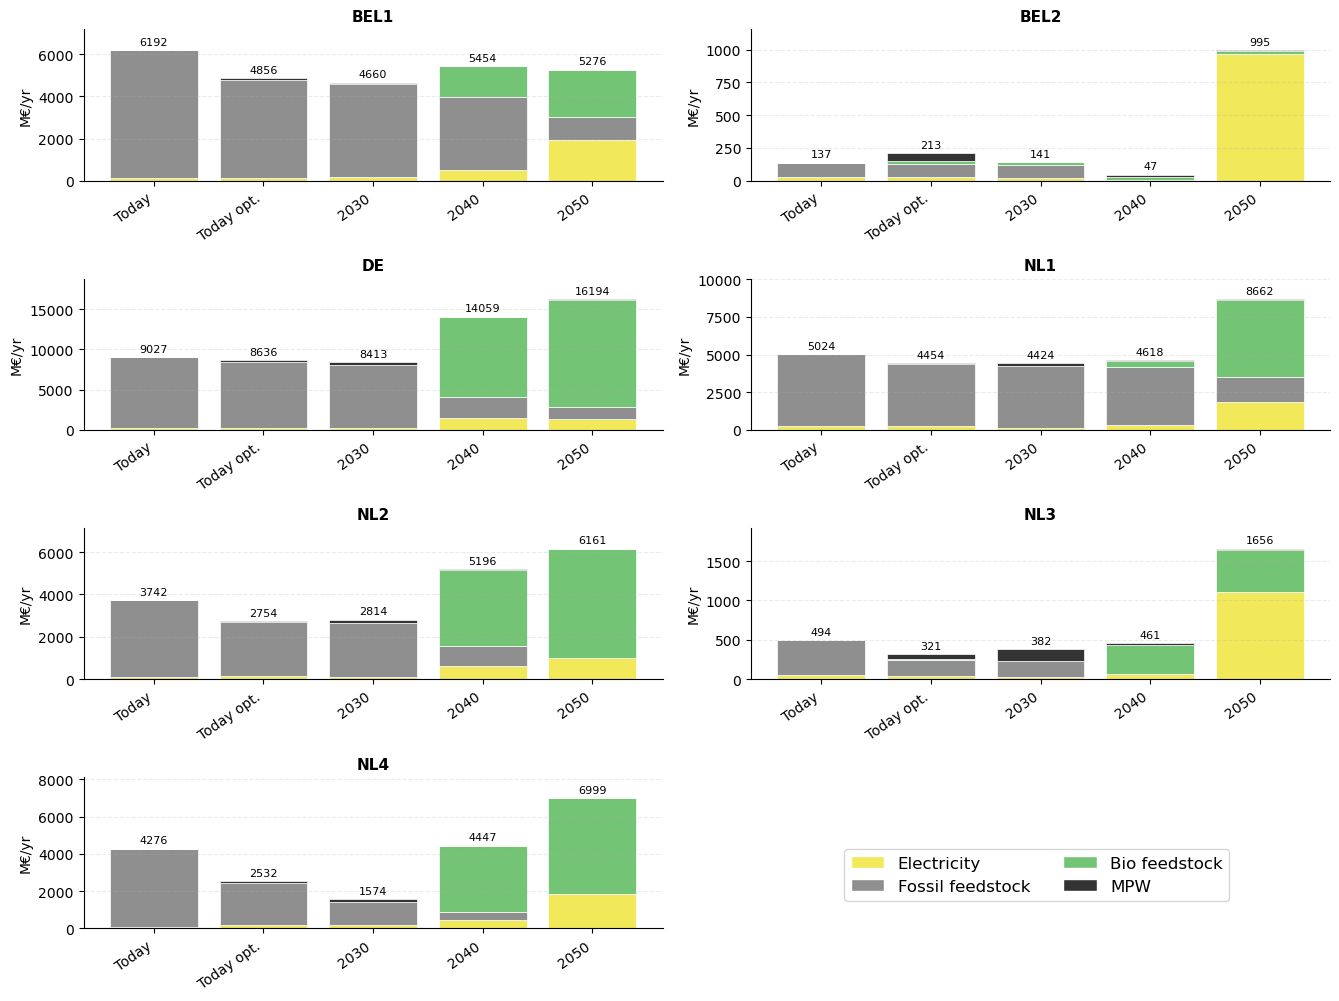

In [6]:
from __future__ import annotations

from pathlib import Path
import re

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# =============================================================================
# User settings
# =============================================================================

H5_FILES = [
    Path(r"output/high_feedstock_availability_5_dd/2020/optimization_results.h5"),
    Path(r"output/high_feedstock_availability_5_dd/2025/optimization_results.h5"),
    Path(r"output/high_feedstock_availability_5_dd/2030/optimization_results.h5"),
    Path(r"output/high_feedstock_availability_5_dd/2040/optimization_results.h5"),
    Path(r"output/high_feedstock_availability_5_dd/2050/optimization_results.h5"),
]

INTERNAL_YEAR = "2022"

NODE_ORDER = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]

SCENARIO_LABELS = {
    2020: "Today",
    2025: "Today opt.",
    2030: "2030",
    2040: "2040",
    2050: "2050",
}

SCENARIO_ORDER = ["Today", "Today opt.", "2030", "2040", "2050"]


# =============================================================================
# Carrier classification
# =============================================================================
# Adjust names if your H5 contains slightly different carrier names.
# Any unmapped carrier is assigned to "Unknown".

CARRIER_CLASSES = {
    # Electricity
    "electricity": "Electricity",
    "electricity_grid": "Electricity",

    # Fossil feedstocks
    "methane": "Fossil feedstock",
    "naphtha": "Fossil feedstock",
    "feedgas": "Fossil feedstock",
    "crackergas": "Fossil feedstock",

    # Bio feedstocks
    "methane_bio": "Bio feedstock",
    "naphtha_bio": "Bio feedstock",
    "biomass": "Bio feedstock",

    # Recycled feedstocks
    "MPW": "MPW",

    # Hydrogen
    "hydrogen": "Hydrogen",
    "hydrogen_transported": "Hydrogen",

    # CO2
    "CO2": "CO2",
    "CO2captured": "CO2",

    # Products
    "ammonia": "Chemical products",
    "methanol": "Chemical products",
    "ethylene": "Chemical products",
    "propylene": "Chemical products",
    "cracking_byproducts": "Chemical products",
    "olefins": "Chemical products",
    "syngas": "Chemical products",

    # Other possible carriers
    "nitrogen": "Other carriers",
    "steam": "Other carriers",
    "HBfeed": "Other carriers",
}

CARRIER_CLASS_ORDER = [
    "Electricity",
    "Fossil feedstock",
    "Bio feedstock",
    "Recycled feedstock",
    "Hydrogen",
    "CO2",
    "Chemical products",
    "Other carriers",
    "Unknown",
]

CARRIER_CLASS_COLORS = {
    "Electricity": "#f1e85a",
    "Fossil feedstock": "#8f8f8f",
    "Bio feedstock": "#74c476",
    "Recycled feedstock": "#d62728",
    "Hydrogen": "#1f77b4",
    "CO2": "#9467bd",
    "Chemical products": "#17becf",
    "Other carriers": "#bdbdbd",
    "Unknown": "#000000",
}

# For the material-feedstock-only plot.
# Electricity, H2 and CO2 are excluded here by construction.
MATERIAL_FEEDSTOCK_CLASSES = [
    "Fossil feedstock",
    "Bio feedstock",
    "Recycled feedstock",
]


# =============================================================================
# Helpers
# =============================================================================

def to_scalar(x):
    """Convert HDF5 scalar-like datasets to Python scalars."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")

    if isinstance(x, np.generic):
        value = x.item()
        if isinstance(value, (bytes, bytearray)):
            return value.decode("utf-8")
        return value

    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        value = x.reshape(-1)[0].item()
        if isinstance(value, (bytes, bytearray)):
            return value.decode("utf-8")
        return value

    return x


def infer_scenario_year_from_path(h5_path: str | Path) -> int:
    """
    Infer scenario year from parent folders.
    Example:
        output/base_case_5_dd/2030/optimization_results.h5 -> 2030
    """
    h5_path = Path(h5_path)

    for parent in h5_path.parents:
        if re.fullmatch(r"(19|20)\d{2}", parent.name):
            return int(parent.name)

    match = re.search(r"(19|20)\d{2}", h5_path.stem)
    if match:
        return int(match.group(0))

    raise ValueError(f"Could not infer scenario year from path: {h5_path}")


def annualise_timeseries(values: np.ndarray, factors: np.ndarray) -> float:
    """
    Annualise an hourly/typical-day time series using k-means weighting factors.

    If shapes match, uses dot product.
    Otherwise falls back to nan-sum.
    """
    values = np.asarray(values, dtype=float)
    factors = np.asarray(factors, dtype=float)

    if values.shape == factors.shape:
        return float(np.dot(values, factors))

    if values.ndim == 1 and len(values) == len(factors):
        return float(np.dot(values, factors))

    return float(np.nansum(values))


def classify_carrier(carrier: str) -> str:
    """Map carrier name to a carrier/feedstock class."""
    return CARRIER_CLASSES.get(carrier, "Unknown")


# =============================================================================
# HDF5 extraction
# =============================================================================

def load_import_export_costs_one_file(
    h5_path: str | Path,
    internal_year: str = INTERNAL_YEAR,
) -> pd.DataFrame:
    """
    Load annual import/export costs for all node/carrier pairs in one H5 file.

    Annual import cost:
        sum_t(import[t] * import_price[t] * factor[t])

    Annual export revenue:
        sum_t(export[t] * export_price[t] * factor[t])

    Net cost:
        import_cost - export_revenue

    Positive net_cost = net spending.
    Negative net_cost = net revenue.
    """
    h5_path = Path(h5_path)

    scenario_year = infer_scenario_year_from_path(h5_path)
    scenario_label = SCENARIO_LABELS.get(scenario_year, str(scenario_year))

    rows = []

    with h5py.File(h5_path, "r") as h5:
        factors_path = f"k_means_specs/{internal_year}/factors"
        eb_base = f"operation/energy_balance/{internal_year}"

        if factors_path not in h5:
            raise KeyError(f"Path '{factors_path}' not found in {h5_path}")

        if eb_base not in h5:
            raise KeyError(f"Path '{eb_base}' not found in {h5_path}")

        factors = np.asarray(h5[factors_path][()], dtype=float)

        for node in h5[eb_base].keys():
            node_group = h5[eb_base][node]

            for carrier in node_group.keys():
                carrier_group = node_group[carrier]

                # Some carriers may not have all datasets.
                import_arr = (
                    np.asarray(carrier_group["import"][()], dtype=float)
                    if "import" in carrier_group
                    else np.zeros_like(factors, dtype=float)
                )
                export_arr = (
                    np.asarray(carrier_group["export"][()], dtype=float)
                    if "export" in carrier_group
                    else np.zeros_like(factors, dtype=float)
                )
                import_price = (
                    np.asarray(carrier_group["import_price"][()], dtype=float)
                    if "import_price" in carrier_group
                    else np.zeros_like(factors, dtype=float)
                )
                export_price = (
                    np.asarray(carrier_group["export_price"][()], dtype=float)
                    if "export_price" in carrier_group
                    else np.zeros_like(factors, dtype=float)
                )

                annual_import = annualise_timeseries(import_arr, factors)
                annual_export = annualise_timeseries(export_arr, factors)

                import_cost = annualise_timeseries(import_arr * import_price, factors)
                export_revenue = annualise_timeseries(export_arr * export_price, factors)

                rows.append({
                    "h5_file": str(h5_path),
                    "scenario_year": scenario_year,
                    "scenario_label": scenario_label,
                    "node": str(node),
                    "carrier": str(carrier),
                    "carrier_class": classify_carrier(str(carrier)),
                    "annual_import": annual_import,
                    "annual_export": annual_export,
                    "import_cost": import_cost,
                    "export_revenue": export_revenue,
                    "net_cost": import_cost - export_revenue,
                })

    return pd.DataFrame(rows)


def collect_import_export_costs(
    h5_files: list[str | Path],
    internal_year: str = INTERNAL_YEAR,
) -> pd.DataFrame:
    """Collect import/export costs from all scenario files."""
    frames = []

    for h5_file in h5_files:
        h5_file = Path(h5_file)

        if not h5_file.exists():
            print(f"[Warning] File not found, skipped: {h5_file}")
            continue

        frames.append(
            load_import_export_costs_one_file(
                h5_path=h5_file,
                internal_year=internal_year,
            )
        )

    if not frames:
        raise FileNotFoundError("No valid H5 files were found.")

    return pd.concat(frames, ignore_index=True)


def aggregate_costs_by_carrier_class(
    raw_df: pd.DataFrame,
    value_col: str,
    allowed_classes: list[str] | None = None,
    drop_zeros: bool = True,
) -> pd.DataFrame:
    """
    Aggregate import/export/net costs by node, scenario, and carrier class.

    Parameters
    ----------
    value_col:
        One of:
        - "import_cost"
        - "export_revenue"
        - "net_cost"
    allowed_classes:
        If provided, only these carrier classes are kept.
    """
    df = raw_df.copy()

    if allowed_classes is not None:
        df = df[df["carrier_class"].isin(allowed_classes)]

    df[value_col] = pd.to_numeric(df[value_col], errors="coerce").fillna(0.0)

    if drop_zeros:
        df = df[df[value_col].abs() > 1e-9]

    grouped = (
        df.groupby(
            ["node", "scenario_year", "scenario_label", "carrier_class"],
            as_index=False,
        )[value_col]
        .sum()
    )

    return grouped


def export_unknown_carriers(raw_df: pd.DataFrame, output_path: str | Path) -> pd.DataFrame:
    """Export diagnostic CSV with carriers mapped to Unknown."""
    unknown = (
        raw_df[raw_df["carrier_class"] == "Unknown"]
        .groupby("carrier", as_index=False)[
            ["annual_import", "annual_export", "import_cost", "export_revenue", "net_cost"]
        ]
        .sum()
        .sort_values("import_cost", ascending=False)
    )

    output_path = Path(output_path)
    # unknown.to_csv(output_path, index=False)

    return unknown


# =============================================================================
# Plotting
# =============================================================================

def plot_cluster_stacked_cost_by_carrier_class(
    agg_df: pd.DataFrame,
    value_col: str,
    title: str,
    output_png: str | Path,
    output_pdf: str | Path,
    node_order: list[str] = NODE_ORDER,
    scenario_order: list[str] = SCENARIO_ORDER,
    class_order: list[str] = CARRIER_CLASS_ORDER,
    class_colors: dict[str, str] = CARRIER_CLASS_COLORS,
    scale: float = 1e6,
    scale_label: str = "M€/yr",
    min_fraction_label: float | None = None,
    figsize: tuple[float, float] = (13.5, 11.5),
):
    """
    Small-multiple stacked positive bar plot.

    Recommended for:
      - import_cost
      - export_revenue shown as positive revenue

    Not recommended for net_cost if values may be negative.
    """
    df = agg_df.copy()
    df["value_scaled"] = df[value_col] / scale

    available_nodes = [node for node in node_order if node in set(df["node"])]
    extra_nodes = sorted(set(df["node"]) - set(available_nodes))
    nodes = available_nodes + extra_nodes

    n_nodes = len(nodes)
    n_cols = 2
    n_rows = int(np.ceil(n_nodes / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharex=False,
        sharey=False,
    )
    axes = np.array(axes).reshape(-1)

    legend_classes_used = set()

    for ax, node in zip(axes, nodes):
        sub = df[df["node"] == node]

        pivot = (
            sub.pivot_table(
                index="scenario_label",
                columns="carrier_class",
                values="value_scaled",
                aggfunc="sum",
                fill_value=0.0,
            )
            .reindex(scenario_order)
            .fillna(0.0)
        )

        ordered_classes = [c for c in class_order if c in pivot.columns]
        extra_classes = [c for c in pivot.columns if c not in ordered_classes]
        ordered_classes += extra_classes

        pivot = pivot[ordered_classes]

        x = np.arange(len(pivot.index))
        bottom = np.zeros(len(pivot.index))
        totals = pivot.sum(axis=1).values

        for carrier_class in ordered_classes:
            values = pivot[carrier_class].values

            if np.all(np.abs(values) < 1e-12):
                continue

            color = class_colors.get(carrier_class, "#333333")

            ax.bar(
                x,
                values,
                bottom=bottom,
                color=color,
                edgecolor="white",
                linewidth=0.5,
                label=carrier_class,
            )

            legend_classes_used.add(carrier_class)

            if min_fraction_label is not None:
                for i, value in enumerate(values):
                    if totals[i] <= 0:
                        continue
                    if value / totals[i] >= min_fraction_label:
                        ax.text(
                            x[i],
                            bottom[i] + value / 2,
                            f"{value:.0f}",
                            ha="center",
                            va="center",
                            fontsize=7.5,
                            color="white",
                            fontweight="bold",
                        )

            bottom += values

        ymax = max(totals.max(), 1.0)

        for i, total in enumerate(totals):
            if total > 0:
                ax.text(
                    x[i],
                    total + 0.025 * ymax,
                    f"{total:.0f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

        ax.set_title(node, fontsize=11, weight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(pivot.index, rotation=35, ha="right")
        ax.set_ylabel(scale_label)
        ax.set_ylim(0, ymax * 1.16)
        ax.grid(axis="y", linestyle="--", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes[n_nodes:]:
        ax.axis("off")

    handles = [
        mpatches.Patch(
            facecolor=class_colors.get(c, "#333333"),
            edgecolor="white",
            label=c,
        )
        for c in class_order
        if c in legend_classes_used
    ]

    for c in sorted(legend_classes_used):
        if c not in class_order:
            handles.append(
                mpatches.Patch(
                    facecolor=class_colors.get(c, "#333333"),
                    edgecolor="white",
                    label=c,
                )
            )

    fig.legend(
        handles=handles,
        loc=[0.63, 0.1],
        ncol=2,
        frameon=True,
        fontsize=12,
    )

    # fig.suptitle(title, fontsize=14, y=0.985)
    fig.tight_layout(rect=[0, 0.075, 1, 0.955])

    output_png = Path(output_png)
    output_pdf = Path(output_pdf)

    # fig.savefig(output_png, dpi=600, bbox_inches="tight")
    # fig.savefig(output_pdf, bbox_inches="tight")

    plt.show()

    return fig


def plot_cluster_net_carrier_cost_total(
    raw_df: pd.DataFrame,
    output_png: str | Path = "cluster_net_carrier_cost_total.png",
    output_pdf: str | Path = "cluster_net_carrier_cost_total.pdf",
    node_order: list[str] = NODE_ORDER,
    scenario_order: list[str] = SCENARIO_ORDER,
    scale: float = 1e6,
    scale_label: str = "M€/yr",
    figsize: tuple[float, float] = (13.5, 10.0),
):
    """
    Small-multiple non-stacked plot of total net carrier cost:
        net_cost = import_cost - export_revenue

    Positive = net cost.
    Negative = net revenue.
    """
    df = raw_df.copy()

    grouped = (
        df.groupby(["node", "scenario_label"], as_index=False)["net_cost"]
        .sum()
    )
    grouped["value_scaled"] = grouped["net_cost"] / scale

    available_nodes = [node for node in node_order if node in set(grouped["node"])]
    extra_nodes = sorted(set(grouped["node"]) - set(available_nodes))
    nodes = available_nodes + extra_nodes

    n_nodes = len(nodes)
    n_cols = 2
    n_rows = int(np.ceil(n_nodes / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharex=False,
        sharey=False,
    )
    axes = np.array(axes).reshape(-1)

    for ax, node in zip(axes, nodes):
        sub = grouped[grouped["node"] == node]

        series = (
            sub.set_index("scenario_label")["value_scaled"]
            .reindex(scenario_order)
            .fillna(0.0)
        )

        x = np.arange(len(series.index))
        values = series.values

        ax.bar(
            x,
            values,
            color="#8f8f8f",
            edgecolor="white",
            linewidth=0.6,
        )

        ax.axhline(0, color="black", linewidth=0.8)

        ymax = max(np.nanmax(np.abs(values)), 1.0)

        for i, value in enumerate(values):
            if abs(value) > 1e-9:
                va = "bottom" if value >= 0 else "top"
                offset = 0.035 * ymax if value >= 0 else -0.035 * ymax
                ax.text(
                    x[i],
                    value + offset,
                    f"{value:.0f}",
                    ha="center",
                    va=va,
                    fontsize=8,
                )

        ax.set_title(node, fontsize=11, weight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(series.index, rotation=35, ha="right")
        ax.set_ylabel(scale_label)
        ax.set_ylim(-1.20 * ymax if values.min() < 0 else 0, 1.20 * ymax)
        ax.grid(axis="y", linestyle="--", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes[n_nodes:]:
        ax.axis("off")

    fig.suptitle(
        "Total net carrier/feedstock cost by cluster",
        fontsize=14,
        y=0.985,
    )

    fig.tight_layout(rect=[0, 0.03, 1, 0.955])

    output_png = Path(output_png)
    output_pdf = Path(output_pdf)

    # fig.savefig(output_png, dpi=600, bbox_inches="tight")
    fig.savefig(output_pdf, bbox_inches="tight")

    plt.show()

    return fig


# =============================================================================
# Main
# =============================================================================

if __name__ == "__main__":
    raw_carrier_costs = collect_import_export_costs(
        h5_files=H5_FILES,
        internal_year=INTERNAL_YEAR,
    )

    # raw_carrier_costs.to_csv("carrier_costs_raw.csv", index=False)

    unknown_carriers = export_unknown_carriers(
        raw_df=raw_carrier_costs,
        output_path="unknown_carriers.csv",
    )

    if not unknown_carriers.empty:
        print("\n[Warning] Some carriers were mapped to 'Unknown':")
        print(unknown_carriers)

    # -------------------------------------------------------------------------
    # Plot 1: import cost, all carriers
    # -------------------------------------------------------------------------
    import_all = aggregate_costs_by_carrier_class(
        raw_df=raw_carrier_costs,
        value_col="import_cost",
        allowed_classes=None,
        drop_zeros=True,
    )

    # import_all.to_csv("carrier_import_costs_by_class_all.csv", index=False)

    plot_cluster_stacked_cost_by_carrier_class(
        agg_df=import_all,
        value_col="import_cost",
        title="Annual carrier/feedstock import cost by cluster and carrier class",
        output_png="cluster_import_cost_all_carriers.png",
        output_pdf="cluster_import_cost_all_carriers.pdf",
        scale=1e6,
        scale_label="M€/yr",
        min_fraction_label=None,
    )

    # -------------------------------------------------------------------------
    # Plot 2: import cost, material feedstocks only
    # -------------------------------------------------------------------------
    import_feedstocks = aggregate_costs_by_carrier_class(
        raw_df=raw_carrier_costs,
        value_col="import_cost",
        allowed_classes=MATERIAL_FEEDSTOCK_CLASSES,
        drop_zeros=True,
    )

    # import_feedstocks.to_csv("carrier_import_costs_by_class_feedstocks_only.csv", index=False)

    # plot_cluster_stacked_cost_by_carrier_class(
    #     agg_df=import_feedstocks,
    #     value_col="import_cost",
    #     title="Annual material feedstock import cost by cluster and feedstock class",
    #     output_png="cluster_import_cost_feedstocks_only.png",
    #     output_pdf="cluster_import_cost_feedstocks_only.pdf",
    #     class_order=MATERIAL_FEEDSTOCK_CLASSES + ["Unknown"],
    #     scale=1e6,
    #     scale_label="M€/yr",
    #     min_fraction_label=None,
    # )

    # -------------------------------------------------------------------------
    # Plot 3: total net carrier cost, non-stacked
    # -------------------------------------------------------------------------
    net_by_class = aggregate_costs_by_carrier_class(
        raw_df=raw_carrier_costs,
        value_col="net_cost",
        allowed_classes=None,
        drop_zeros=True,
    )

    # net_by_class.to_csv("carrier_net_costs_by_class_all.csv", index=False)

    # plot_cluster_net_carrier_cost_total(
    #     raw_df=raw_carrier_costs,
    #     output_png="cluster_net_carrier_cost_total.png",
    #     output_pdf="cluster_net_carrier_cost_total.pdf",
    #     scale=1e6,
    #     scale_label="M€/yr",
    # )

    # print("\nSaved:")
    # print(" - carrier_costs_raw.csv")
    # print(" - unknown_carriers.csv")
    # print(" - carrier_import_costs_by_class_all.csv")
    # print(" - carrier_import_costs_by_class_feedstocks_only.csv")
    # print(" - carrier_net_costs_by_class_all.csv")
    # print(" - cluster_import_cost_all_carriers.png")
    # print(" - cluster_import_cost_all_carriers.pdf")
    # print(" - cluster_import_cost_feedstocks_only.png")
    # print(" - cluster_import_cost_feedstocks_only.pdf")
    # print(" - cluster_net_carrier_cost_total.png")
    # print(" - cluster_net_carrier_cost_total.pdf")

Map for network operation

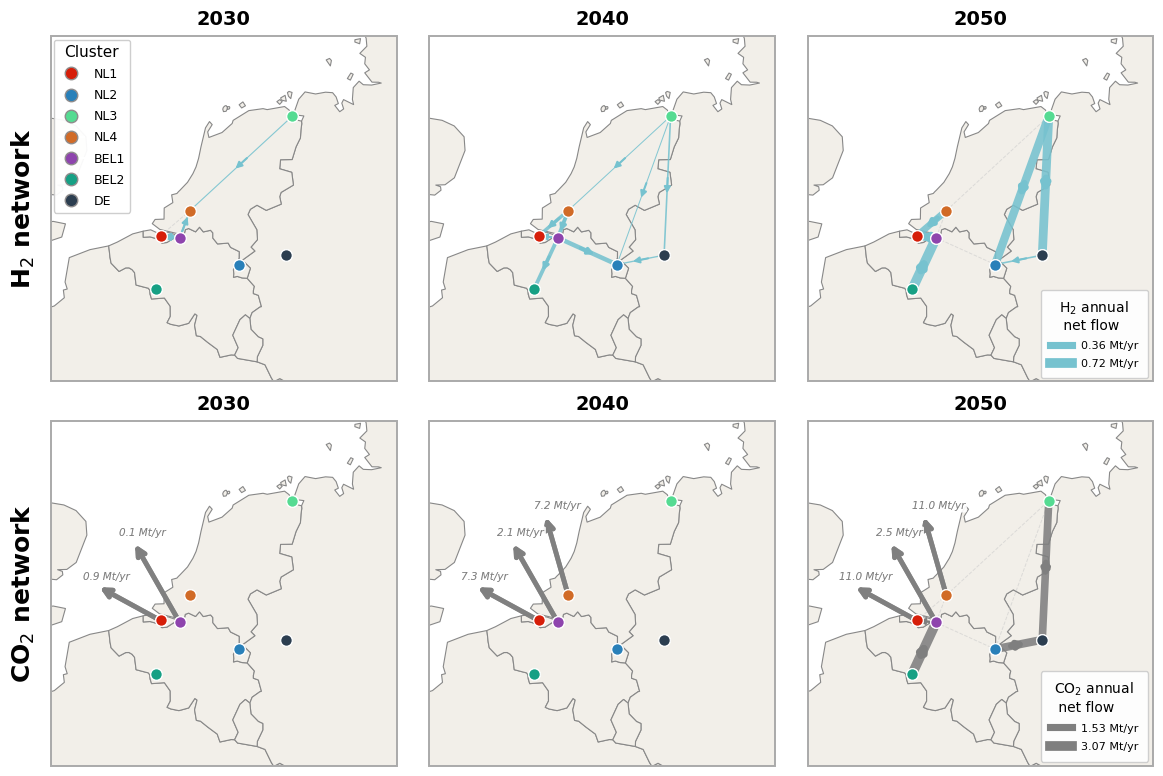

In [107]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from shapely.geometry import LineString
import matplotlib.cm as mcm
import matplotlib.colors as mcolors


# =============================================================================
# User settings
# =============================================================================

INTERNAL_YEAR = "2022"

YEARS = [2030, 2040, 2050]

H5_FILES = {
    2030: Path(r"output\base_case_5_dd\2030\optimization_results.h5"),
    2040: Path(r"output\base_case_5_dd\2040\optimization_results.h5"),
    2050: Path(r"output\base_case_5_dd\2050\optimization_results.h5"),
}

NODES_CSV = {
    2030: Path(r"case_studies\base_case_5_dd\2030\plants_clusters_summary.csv"),
    2040: Path(r"case_studies\base_case_5_dd\2040\plants_clusters_summary.csv"),
    2050: Path(r"case_studies\base_case_5_dd\2050\plants_clusters_summary.csv"),
}

NETWORKS = {
    "H2": "hydrogenPipelineOnshore_existing",
    "CO2": "CO2_pipeline_existing",
}

NETWORK_TITLES = {
    "H2": r"H$_2$ network",
    "CO2": r"CO$_2$ network",
}

NETWORK_COLORS = {
    "H2": "#76C2CF",
    "CO2": "#7f7f7f",
}

NETWORK_CMAPS = {
    "H2": "PuBuGn",
    "CO2": "Greys",
}

# EPSG:3035 plot extent, same style as your reference script
XMIN, YMIN, XMAX, YMAX = 3_700_000, 2_900_000, 4_300_000, 3_500_000

NUTS_PATH = Path(r"data\NUTS_RG_20M_2016_3035.shp.zip")

CLUSTER_COLORS = {
    "NL1": "#d61e09",
    "NL2": "#2980b9",
    "NL3": "#55db92",
    "NL4": "#d16b27",
    "BEL1": "#8e44ad",
    "BEL2": "#16a084",
    "DE": "#2c3e50",
}

CLUSTERS_ORDER = ["NL1", "NL2", "NL3", "NL4", "BEL1", "BEL2", "DE"]

LINE_WIDTH_MIN = 0.6
LINE_WIDTH_MAX = 7.0
LINE_ALPHA = 0.88
NODE_SIZE = 70

DRAW_ARROWS = True
ARROW_SCALE = 0.045

OUTPUT_PNG = Path("network_flows_H2_CO2_2030_2050.png")
OUTPUT_PDF = Path("network_flows_H2_CO2_2030_2050.pdf")
OUTPUT_CSV = Path("network_flows_H2_CO2_2030_2050.csv")


# =============================================================================
# CO2 offshore storage arrows
# =============================================================================

DRAW_CO2_STORAGE_ARROWS = True

CO2_STORAGE_NODES = ["NL1", "NL4", "BEL1"]

# Fixed arrow geometry in EPSG:3035 map units.
# You can tune dx/dy visually.
CO2_STORAGE_ARROW_OFFSETS = {
    "NL1":  {"dx": -110_000, "dy":  60_000, "label_dx": -25_000, "label_dy":  10_000},
    "NL4":  {"dx":  -40_000, "dy": 140_000, "label_dx": -20_000, "label_dy":  10_000},
    "BEL1": {"dx":  -80_000, "dy": 140_000, "label_dx": -25_000, "label_dy":  10_000},
}

CO2_STORAGE_ARROW_COLOR = "#7f7f7f"
CO2_STORAGE_ARROW_LW = 3.5
CO2_STORAGE_ARROW_ALPHA = 0.90

# Carriers whose export represents CO2 leaving the node.
# Depending on your model, you may want only CO2captured, only CO2, or both.
CO2_EXPORT_CARRIERS_FOR_STORAGE_LABEL = ["CO2"]


# =============================================================================
# HDF5 helpers
# =============================================================================

def _to_scalar(x):
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")

    if isinstance(x, np.generic):
        value = x.item()
        return value.decode("utf-8") if isinstance(value, (bytes, bytearray)) else value

    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        value = x.reshape(-1)[0].item()
        return value.decode("utf-8") if isinstance(value, (bytes, bytearray)) else value

    return x


def read_network_flows(
    h5_path: str | Path,
    year: str = INTERNAL_YEAR,
    network: str = "hydrogenPipelineOnshore_existing",
) -> pd.DataFrame:
    """
    Read all directed edges of one network and compute annual weighted flow.

    Annual directed flow:
        annual_flow(edge) = sum_t(flow[t] * factor[t])

    Then, for each undirected pair, compute the net flow:
        net_flow = annual_flow(A->B) - annual_flow(B->A)

    The returned net_flow is absolute, while net_from/net_to store the dominant
    direction.
    """
    h5_path = Path(h5_path)

    base_design = f"design/networks/{year}/{network}"
    base_op = f"operation/networks/{year}/{network}"

    rows = []

    with h5py.File(h5_path, "r") as h5:
        if base_design not in h5:
            return pd.DataFrame(
                columns=[
                    "edge_id", "fromNode", "toNode", "annual_flow",
                    "pair", "net_from", "net_to", "net_flow",
                ]
            )

        factors_path = f"k_means_specs/{year}/factors"
        if factors_path not in h5:
            raise KeyError(f"'{factors_path}' not found in {h5_path}")

        factors = np.asarray(h5[factors_path][()], dtype=float)

        for edge_id in h5[base_design].keys():
            from_node = _to_scalar(h5[f"{base_design}/{edge_id}/fromNode"][()])
            to_node = _to_scalar(h5[f"{base_design}/{edge_id}/toNode"][()])

            flow_path = f"{base_op}/{edge_id}/flow"

            if flow_path in h5:
                flow = np.asarray(h5[flow_path][()], dtype=float)
                annual_flow = float(np.sum(flow * factors))
            else:
                annual_flow = 0.0

            rows.append({
                "edge_id": str(edge_id),
                "fromNode": str(from_node),
                "toNode": str(to_node),
                "annual_flow": annual_flow,
            })

    df = pd.DataFrame(rows)

    if df.empty:
        return df

    df["pair"] = df.apply(
        lambda r: tuple(sorted([r["fromNode"], r["toNode"]])),
        axis=1,
    )

    net_rows = []

    for pair, grp in df.groupby("pair"):
        a, b = pair

        flow_ab = grp.loc[
            (grp["fromNode"] == a) & (grp["toNode"] == b),
            "annual_flow",
        ].sum()

        flow_ba = grp.loc[
            (grp["fromNode"] == b) & (grp["toNode"] == a),
            "annual_flow",
        ].sum()

        net = flow_ab - flow_ba

        net_rows.append({
            "pair": pair,
            "net_from": a if net >= 0 else b,
            "net_to": b if net >= 0 else a,
            "net_flow": abs(net),
            "signed_net_flow": net,
        })

    net_df = pd.DataFrame(net_rows)
    df = df.merge(net_df, on="pair", how="left")

    return df

def read_node_co2_exports_for_storage(
    h5_path: str | Path,
    nodes: list[str],
    year: str = INTERNAL_YEAR,
    carriers: list[str] = CO2_EXPORT_CARRIERS_FOR_STORAGE_LABEL,
) -> pd.DataFrame:
    """
    Reads annual CO2 export from selected nodes.

    For each node and carrier:
        annual_export = sum_t(export[t] * factor[t])

    Returns one row per node with the total annual export across the selected carriers.

    Units are the same as the H5 flow units multiplied by the k-means factors.
    If the H5 values are t/h and factors are h/year, the result is t/year.
    """
    h5_path = Path(h5_path)
    rows = []

    with h5py.File(h5_path, "r") as h5:
        factors_path = f"k_means_specs/{year}/factors"
        eb_base = f"operation/energy_balance/{year}"

        if factors_path not in h5:
            raise KeyError(f"'{factors_path}' not found in {h5_path}")

        if eb_base not in h5:
            raise KeyError(f"'{eb_base}' not found in {h5_path}")

        factors = np.asarray(h5[factors_path][()], dtype=float)

        for node in nodes:
            total_export = 0.0
            carrier_details = {}

            for carrier in carriers:
                export_path = f"{eb_base}/{node}/{carrier}/export"

                if export_path in h5:
                    export = np.asarray(h5[export_path][()], dtype=float)
                    annual_export = float(np.sum(export * factors))
                else:
                    annual_export = 0.0

                carrier_details[carrier] = annual_export
                total_export += annual_export

            row = {
                "node": node,
                "co2_storage_export": total_export,
            }
            for carrier, value in carrier_details.items():
                row[f"{carrier}_export"] = value

            rows.append(row)

    return pd.DataFrame(rows)


# =============================================================================
# Geometry helpers
# =============================================================================

def load_cluster_points_3035(nodes_csv: str | Path) -> gpd.GeoDataFrame:
    """
    Load cluster coordinates from plants_clusters_summary.csv and convert to EPSG:3035.

    Expected columns:
        cluster, latitude, longitude
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    gdf = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326",
    ).to_crs("EPSG:3035")

    gdf["x"] = gdf.geometry.x
    gdf["y"] = gdf.geometry.y

    return gdf


def attach_geometry_3035(
    edges_df: pd.DataFrame,
    nodes_csv: str | Path,
) -> gpd.GeoDataFrame:
    """
    Attach EPSG:3035 geometry to network net flows.
    Geometry follows net_from -> net_to.
    """
    if edges_df.empty:
        return gpd.GeoDataFrame(edges_df.copy(), geometry=[], crs="EPSG:3035")

    nodes = load_cluster_points_3035(nodes_csv)
    coords = nodes.set_index("cluster")[["x", "y"]]

    ed = edges_df.drop_duplicates(subset="pair").copy()

    ed["from_x"] = ed["net_from"].map(coords["x"])
    ed["from_y"] = ed["net_from"].map(coords["y"])
    ed["to_x"] = ed["net_to"].map(coords["x"])
    ed["to_y"] = ed["net_to"].map(coords["y"])

    valid = ed[["from_x", "from_y", "to_x", "to_y"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()

    ed["geometry"] = ed.apply(
        lambda r: LineString([(r["from_x"], r["from_y"]), (r["to_x"], r["to_y"])]),
        axis=1,
    )

    return gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:3035")


def collect_all_network_flows() -> tuple[
    dict[tuple[str, int], gpd.GeoDataFrame],
    dict[int, pd.DataFrame],
]:
    """
    Returns:
        data[(network_label, year)] = GeoDataFrame with net network flows
        co2_storage_exports[year]  = DataFrame with CO2 export from selected nodes
    """
    data = {}
    co2_storage_exports = {}

    for network_label, network_name in NETWORKS.items():
        for scenario_year in YEARS:
            h5_path = H5_FILES[scenario_year]
            nodes_csv = NODES_CSV[scenario_year]

            edges = read_network_flows(
                h5_path=h5_path,
                year=INTERNAL_YEAR,
                network=network_name,
            )

            g_edges = attach_geometry_3035(edges, nodes_csv)

            g_edges["network_label"] = network_label
            g_edges["network_name"] = network_name
            g_edges["scenario_year"] = scenario_year

            data[(network_label, scenario_year)] = g_edges

    # CO2 export labels for offshore storage arrows
    for scenario_year in YEARS:
        h5_path = H5_FILES[scenario_year]
        co2_storage_exports[scenario_year] = read_node_co2_exports_for_storage(
            h5_path=h5_path,
            nodes=CO2_STORAGE_NODES,
            year=INTERNAL_YEAR,
            carriers=CO2_EXPORT_CARRIERS_FOR_STORAGE_LABEL,
        )

    return data, co2_storage_exports


def get_row_max_flow(
    data: dict[tuple[str, int], gpd.GeoDataFrame],
    network_label: str,
) -> float:
    """
    Common max flow for one network across 2030, 2040, 2050.
    Used to keep linewidth comparable within the row.
    """
    values = []

    for scenario_year in YEARS:
        gdf = data[(network_label, scenario_year)]
        if not gdf.empty and "net_flow" in gdf:
            arr = pd.to_numeric(gdf["net_flow"], errors="coerce").fillna(0.0).to_numpy()
            if arr.size:
                values.extend(arr.tolist())

    vmax = max(values) if values else 1.0
    return float(vmax) if vmax > 0 else 1.0


def line_width(value: float, max_value: float) -> float:
    """
    Sqrt scaling, as in the reference style.
    """
    if value <= 0 or max_value <= 0:
        return 0.0

    return LINE_WIDTH_MIN + (LINE_WIDTH_MAX - LINE_WIDTH_MIN) * np.sqrt(value / max_value)


# =============================================================================
# Plotting
# =============================================================================

def load_countries_3035() -> gpd.GeoDataFrame:
    nuts = gpd.read_file(NUTS_PATH)
    countries = nuts[nuts["LEVL_CODE"] == 0].cx[XMIN:XMAX, YMIN:YMAX].copy()
    return countries


def draw_direction_arrow(
    ax: plt.Axes,
    line: LineString,
    color: str,
    linewidth: float,
):
    """
    Draw a small arrow at the midpoint of a line, following net flow direction.
    """
    coords = list(line.coords)
    if len(coords) < 2:
        return

    x0, y0 = coords[0]
    x1, y1 = coords[-1]

    vx = x1 - x0
    vy = y1 - y0

    length = (vx**2 + vy**2) ** 0.5
    if length == 0:
        return

    mx = (x0 + x1) / 2
    my = (y0 + y1) / 2

    # Arrow length in map units, proportional to map extent
    arrow_length = ARROW_SCALE * min(XMAX - XMIN, YMAX - YMIN)

    dx = arrow_length * vx / length
    dy = arrow_length * vy / length

    ax.annotate(
        "",
        xy=(mx + dx / 2, my + dy / 2),
        xytext=(mx - dx / 2, my - dy / 2),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=max(1.5, linewidth * 0.75),
            mutation_scale=9,
            shrinkA=0,
            shrinkB=0,
        ),
        zorder=5,
    )

def draw_co2_storage_arrows(
    ax: plt.Axes,
    nodes_gdf: gpd.GeoDataFrame,
    storage_exports_df: pd.DataFrame,
):
    """
    Draw fixed-position offshore CO2 storage arrows from selected nodes.

    Labels are computed from H5 node CO2 exports.
    """
    if not DRAW_CO2_STORAGE_ARROWS:
        return

    if storage_exports_df is None or storage_exports_df.empty:
        return

    export_map = (
        storage_exports_df
        .set_index("node")["co2_storage_export"]
        .to_dict()
    )

    coords = nodes_gdf.set_index("cluster")[["x", "y"]]

    for node in CO2_STORAGE_NODES:
        if node not in coords.index:
            continue

        export_value = float(export_map.get(node, 0.0))

        # Do not draw arrow if no export.
        if export_value <= 1e-9:
            continue

        cfg = CO2_STORAGE_ARROW_OFFSETS.get(node)
        if cfg is None:
            continue

        x0 = float(coords.loc[node, "x"])
        y0 = float(coords.loc[node, "y"])

        x1 = x0 + cfg["dx"]
        y1 = y0 + cfg["dy"]

        ax.annotate(
            "",
            xy=(x1, y1),
            xytext=(x0, y0),
            arrowprops=dict(
                arrowstyle="->",
                color=CO2_STORAGE_ARROW_COLOR,
                lw=CO2_STORAGE_ARROW_LW,
                alpha=CO2_STORAGE_ARROW_ALPHA,
                mutation_scale=14,
            ),
            zorder=6,
        )

        # Assuming export_value is t/year. Change if your unit is different.
        label = f"{export_value / 1e6:.1f} Mt/yr"

        ax.text(
            x1 + cfg.get("label_dx", 0),
            y1 + cfg.get("label_dy", 0),
            label,
            fontsize=7.5,
            color=CO2_STORAGE_ARROW_COLOR,
            fontstyle="italic",
            bbox=dict(
                facecolor="white",
                alpha=0.72,
                edgecolor="none",
                boxstyle="round,pad=0.15",
            ),
            zorder=7,
        )


def plot_network_panel(
    ax: plt.Axes,
    g_edges: gpd.GeoDataFrame,
    nodes_gdf: gpd.GeoDataFrame,
    countries: gpd.GeoDataFrame,
    network_label: str,
    scenario_year: int,
    max_flow_row: float,
    co2_storage_exports_df: pd.DataFrame | None = None,
):
    """
    Plot one map panel.
    """
    # Background map
    countries.plot(
        ax=ax,
        color="#f2efe9",
        edgecolor="#888888",
        linewidth=0.8,
        zorder=1,
    )

    edge_color = NETWORK_COLORS[network_label]

    if not g_edges.empty:
        ed = g_edges.copy()
        ed["net_flow"] = pd.to_numeric(ed["net_flow"], errors="coerce").fillna(0.0)

        # Draw zero-flow existing edges, if present
        zero_edges = ed[ed["net_flow"] <= 0]
        if not zero_edges.empty:
            zero_edges.plot(
                ax=ax,
                color="#cccccc",
                linewidth=0.7,
                linestyle="--",
                alpha=0.60,
                zorder=2,
            )

        active_edges = ed[ed["net_flow"] > 0].copy()
        active_edges["lw"] = active_edges["net_flow"].apply(lambda v: line_width(v, max_flow_row))

        # Draw smaller lines first, larger on top
        active_edges = active_edges.sort_values("lw")

        for _, row in active_edges.iterrows():
            gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:3035").plot(
                ax=ax,
                color=edge_color,
                linewidth=row["lw"],
                alpha=LINE_ALPHA,
                zorder=3,
            )

            if DRAW_ARROWS:
                draw_direction_arrow(
                    ax=ax,
                    line=row.geometry,
                    color=edge_color,
                    linewidth=row["lw"],
                )

    # Offshore CO2 storage arrows, only on CO2 panels
    if network_label == "CO2" and co2_storage_exports_df is not None:
        draw_co2_storage_arrows(
            ax=ax,
            nodes_gdf=nodes_gdf,
            storage_exports_df=co2_storage_exports_df,
        )

    # Cluster nodes
    for _, row in nodes_gdf.iterrows():
        cluster = str(row["cluster"])
        color = CLUSTER_COLORS.get(cluster, "#555555")

        ax.scatter(
            row["x"],
            row["y"],
            marker="o",
            s=NODE_SIZE,
            color=color,
            edgecolors="white",
            linewidths=0.9,
            zorder=7,
        )

    ax.set_title(f"{scenario_year}", fontsize=14, fontweight="bold", pad=8)

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_axis_off()

    # Grey frame, same style as your reference
    ax.add_patch(
        mpatches.Rectangle(
            (0, 0),
            1,
            1,
            transform=ax.transAxes,
            fill=False,
            edgecolor="#aaaaaa",
            linewidth=1.4,
            zorder=20,
            clip_on=False,
        )
    )

    # Offshore CO2 storage arrows, only on CO2 panels
    if network_label == "CO2" and co2_storage_exports_df is not None:
        draw_co2_storage_arrows(
            ax=ax,
            nodes_gdf=nodes_gdf,
            storage_exports_df=co2_storage_exports_df,
        )

    # Cluster nodes
    for _, row in nodes_gdf.iterrows():
        cluster = str(row["cluster"])
        color = CLUSTER_COLORS.get(cluster, "#555555")

        ax.scatter(
            row["x"],
            row["y"],
            marker="o",
            s=NODE_SIZE,
            color=color,
            edgecolors="white",
            linewidths=0.9,
            zorder=7,
        )


def plot_combined_network_figure():
    data, co2_storage_exports = collect_all_network_flows()
    countries = load_countries_3035()

    # Use the 2050 node file just for node plotting.
    # Coordinates should be the same across years; if not, change this logic.
    nodes_gdf = load_cluster_points_3035(NODES_CSV[2050])

    row_max = {
        network_label: get_row_max_flow(data, network_label)
        for network_label in NETWORKS.keys()
    }

    plt.rcParams["font.size"] = 9
    plt.rcParams["font.weight"] = "normal"

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(13.8, 9.0),
        sharex=True,
        sharey=True,
    )

    network_labels = ["H2", "CO2"]

    for i, network_label in enumerate(network_labels):
        for j, scenario_year in enumerate(YEARS):
            ax = axes[i, j]

            plot_network_panel(
                ax=ax,
                g_edges=data[(network_label, scenario_year)],
                nodes_gdf=nodes_gdf,
                countries=countries,
                network_label=network_label,
                scenario_year=scenario_year,
                max_flow_row=row_max[network_label],
                co2_storage_exports_df=co2_storage_exports.get(scenario_year),
            )

            if j == 0:
                ax.text(
                    -0.08,
                    0.5,
                    NETWORK_TITLES[network_label],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=18,
                    fontweight="bold",
                )

    # -------------------------------------------------------------------------
    # Legends
    # -------------------------------------------------------------------------

    # Cluster legend (left)
    clust_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=CLUSTER_COLORS[c],
            markeredgecolor="#8F8C8C",
            markersize=9,
            label=c,
        )
        for c in CLUSTERS_ORDER
        if c in CLUSTER_COLORS
    ]

    fig.legend(
        handles=clust_handles,
        title="Cluster",
        title_fontsize=11,
        loc="center left",
        bbox_to_anchor=(0.112, 0.806),
        fontsize=9,
        framealpha=0.95,
        edgecolor="#cccccc",
        labelspacing=0.65,
        ncol=1,
    )

    # ---------------------------------------------------------------------
    # Separate H2 legend
    # ---------------------------------------------------------------------
    h2_max = row_max["H2"]
    h2_color = NETWORK_COLORS["H2"]

    h2_handles = []
    for frac in [0.5, 1.0]:
        value = h2_max * frac
        lw = line_width(value, h2_max)

        h2_handles.append(
            Line2D(
                [0],
                [0],
                color=h2_color,
                linewidth=lw,
                label=f"{value/1e6:.2f} Mt/yr",
            )
        )

    fig.legend(
        handles=h2_handles,
        title=f"H$_2$ annual \n net flow",
        title_fontsize=10,
        loc="center right",
        bbox_to_anchor=(0.9136, 0.575),
        fontsize=8,
        framealpha=0.92,
        edgecolor="#cccccc",
        labelspacing=0.7,
        borderpad=0.85,
        ncol=1,
    )

    # ---------------------------------------------------------------------
    # Separate CO2 legend
    # ---------------------------------------------------------------------
    co2_max = row_max["CO2"]
    co2_color = NETWORK_COLORS["CO2"]

    co2_handles = []
    for frac in [0.5, 1.0]:
        value = co2_max * frac
        lw = line_width(value, co2_max)

        co2_handles.append(
            Line2D(
                [0],
                [0],
                color=co2_color,
                linewidth=lw,
                label=f"{value/1e6:.2f} Mt/yr",
            )
        )

    fig.legend(
        handles=co2_handles,
        title=f"CO$_2$ annual \n net flow",
        title_fontsize=10,
        loc="center right",
        bbox_to_anchor=(0.9136, 0.15),
        fontsize=8,
        framealpha=0.92,
        edgecolor="#cccccc",
        labelspacing=0.8,
        borderpad=0.85,
        ncol=1,
    )

    plt.tight_layout(rect=[0.07, 0.08, 0.93, 0.95])

    fig.savefig(OUTPUT_PNG, dpi=600, bbox_inches="tight")
    # fig.savefig(OUTPUT_PDF, bbox_inches="tight")

    plt.show()

    return fig, axes, data


# =============================================================================
# Diagnostic CSV export
# =============================================================================

def export_flow_table(
    data: dict[tuple[str, int], gpd.GeoDataFrame],
    output_csv: str | Path = OUTPUT_CSV,
) -> pd.DataFrame:
    rows = []

    for (network_label, scenario_year), gdf in data.items():
        if gdf.empty:
            continue

        tmp = gdf.copy()
        tmp["pair_str"] = tmp["pair"].astype(str)

        keep = [
            "network_label",
            "network_name",
            "scenario_year",
            "pair_str",
            "net_from",
            "net_to",
            "net_flow",
            "signed_net_flow",
        ]

        keep = [c for c in keep if c in tmp.columns]
        rows.append(tmp[keep])

    if rows:
        out = pd.concat(rows, ignore_index=True)
    else:
        out = pd.DataFrame()

    # out.to_csv(output_csv, index=False)

    return out


if __name__ == "__main__":
    fig, axes, data = plot_combined_network_figure()

    flow_table = export_flow_table(
        data=data,
        output_csv=OUTPUT_CSV,
    )

    # print("Saved:")
    # print(f" - {OUTPUT_PNG}")
    # print(f" - {OUTPUT_PDF}")
    # print(f" - {OUTPUT_CSV}")

Stacked areas of production routes

Saved:
  final_chemical_pathway_amounts.csv
  final_chemical_pathway_shares.csv
  final_chemical_pathway_shares.png


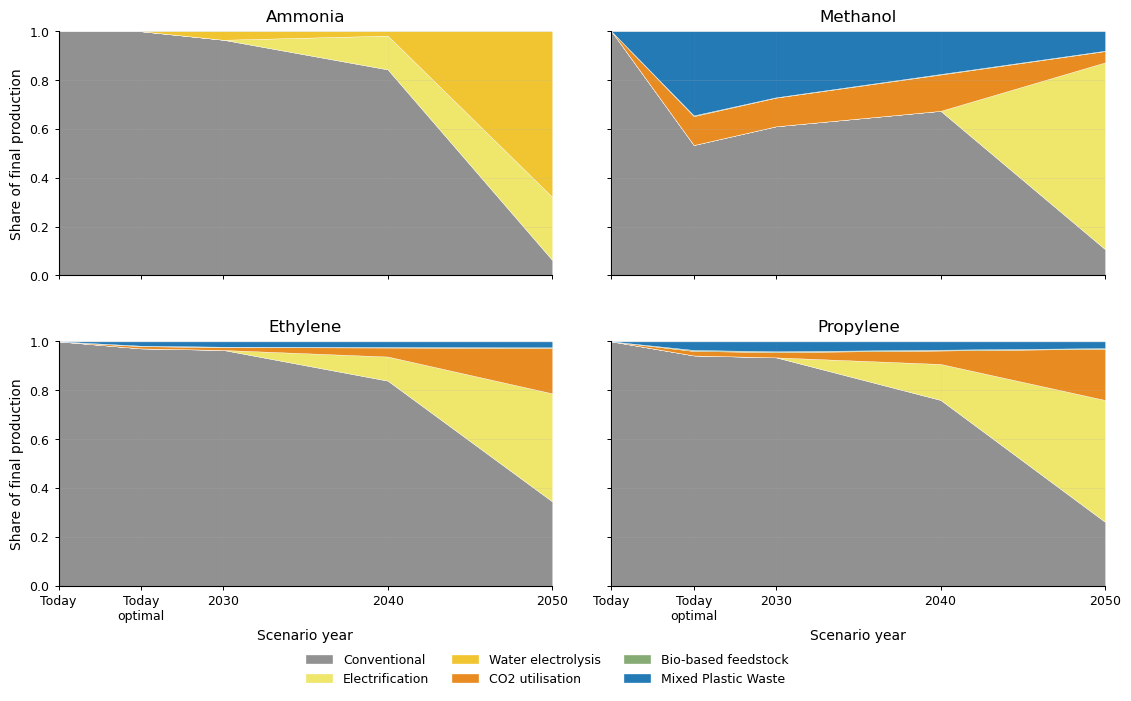

In [6]:

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


EPS = 1e-9

CLASS_ORDER = [
    "Conventional",
    "Electrification",
    "Water electrolysis",
    "CO2 utilisation",
    "Plastic waste recycling",
    "Bio-based feedstock",
    "Unknown",
]

CLASS_COLORS = {
    "Conventional": "#8f8f8f",
    "Electrification": "#efe669",
    "Water electrolysis": "#f0c42d",
    "CO2 utilisation": "#e8891c",
    "Bio-based feedstock": "#85aa72",
    "Plastic waste recycling": "#b576b5",
    "Unknown": "#d9d9d9",
}

# Mapping on base technology names, i.e. without "_existing".
TECH_CLASS = {
    # fossil/conventional
    "CrackerFurnace": "Conventional",
    "SteamReformer": "Conventional",

    # electrified routes
    "eCrackerFurnace": "Electrification",
    "eSMR_syngas": "Electrification",

    # hydrogen routes
    "PEMEC": "Water electrolysis",
    "SOEC": "Water electrolysis",
    # circular / bio / CO2 routes
    "rWGS": "CO2 utilisation",
    "Plastic2methanol": "Mixed Plastic Waste",
    "Biomass2methanol": "Bio-based feedstock",
}

TRANSPARENT_TECHS = {
    "HaberBosch",
    "MeOHsynthesis",
    "MethanolToOlefins",
    "OlefinSeparation",
    "WGS_syngas",
    "HBfeed_mixer",
    "feedgas_mixer",
    "naphtha_mixer",
    "CO2_mixer",
    "Storage_H2",
    "Storage_Battery",
    "H2_network_connection_in",
    "H2_network_connection_out",
}


def base_technology_name(technology: str) -> str:
    """
    Merge existing/new versions in a single technology name.
    """
    return re.sub(r"_existing$", "", technology)


def annualize_dataset(dataset: h5py.Dataset, factors: np.ndarray | None) -> float:
    """
    Convert a representative-time-series dataset into an annual quantity.
    """
    arr = np.asarray(dataset[()])

    if arr.ndim == 0:
        return float(arr)

    arr = arr.astype(float, copy=False)

    if factors is not None and arr.shape == factors.shape:
        return float(np.dot(arr, factors))

    if factors is not None and arr.ndim == 1 and len(arr) == len(factors):
        return float(np.dot(arr, factors))

    # Fallback for datasets that are not representative time series.
    return float(np.nansum(arr))


def infer_year_from_path_or_period(path: Path, period: str) -> int | str:
    """
    Infer the scenario/reference year associated with an H5 result file.

    Priority:
    1. a 4-digit year in the parent folders, starting from the closest parent;
       e.g. output/base_case_old/2030/optimization_results.h5 -> 2030
    2. a 4-digit year in the file stem;
    3. the internal H5 period as fallback.

    The internal H5 period is intentionally not used first, because in this
    workflow it can be a fixed dummy value such as "2022" for all files.
    """
    path = Path(path)

    for parent in path.parents:
        folder_name = parent.name
        if re.fullmatch(r"(19|20)\d{2}", folder_name):
            return int(folder_name)

    match = re.search(r"(19|20)\d{2}", path.stem)
    if match:
        return int(match.group(0))

    period_str = str(period)
    if re.fullmatch(r"\d{4}", period_str):
        return int(period_str)

    return period_str


def read_period_totals(h5_path: str | Path) -> dict[int | str, dict[str, dict[str, dict[str, float]]]]:
    """
    Read one H5 file and return:
        {year: {node: {base_technology: {carrier: annual_value}}}}
    """
    h5_path = Path(h5_path)
    out = {}

    with h5py.File(h5_path, "r") as h5:
        tech_root = h5["operation"]["technology_operation"]

        for period in tech_root.keys():
            year = infer_year_from_path_or_period(h5_path, period)

            factors = None
            if "k_means_specs" in h5 and period in h5["k_means_specs"]:
                if "factors" in h5["k_means_specs"][period]:
                    factors = np.asarray(h5["k_means_specs"][period]["factors"][()], dtype=float)

            period_totals = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))

            for node in tech_root[period].keys():
                node_group = tech_root[period][node]

                for technology in node_group.keys():
                    base_tech = base_technology_name(technology)
                    tech_group = node_group[technology]

                    for carrier in tech_group.keys():
                        value = annualize_dataset(tech_group[carrier], factors)
                        if abs(value) > EPS:
                            period_totals[node][base_tech][carrier] += value

            out[year] = period_totals

    return out


def read_period_data(h5_path: str | Path) -> dict[int | str, dict]:
    """
    Read one H5 file and return period totals plus H2 network flows:
        {
            year: {
                "period_totals": {node: {base_technology: {carrier: annual_value}}},
                "h2_network_edges": [ ... ],
            }
        }
    """
    h5_path = Path(h5_path)
    out = {}

    with h5py.File(h5_path, "r") as h5:
        tech_root = h5["operation"]["technology_operation"]

        for period in tech_root.keys():
            year = infer_year_from_path_or_period(h5_path, period)

            factors = None
            if "k_means_specs" in h5 and period in h5["k_means_specs"]:
                if "factors" in h5["k_means_specs"][period]:
                    factors = np.asarray(h5["k_means_specs"][period]["factors"][()], dtype=float)

            period_totals = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
            nodes = list(tech_root[period].keys())

            for node in nodes:
                node_group = tech_root[period][node]

                for technology in node_group.keys():
                    base_tech = base_technology_name(technology)
                    tech_group = node_group[technology]

                    for carrier in tech_group.keys():
                        value = annualize_dataset(tech_group[carrier], factors)
                        if abs(value) > EPS:
                            period_totals[node][base_tech][carrier] += value

            h2_network_edges = read_h2_network_edges(h5, period, factors, nodes)

            out[year] = {
                "period_totals": period_totals,
                "h2_network_edges": h2_network_edges,
            }

    return out


def carrier_amount(node_totals: dict, technology: str, carrier: str) -> float:
    return float(node_totals.get(technology, {}).get(carrier, 0.0))


def sum_carrier(node_totals: dict, carrier: str, technologies: set[str] | None = None) -> float:
    value = 0.0
    for technology, carriers in node_totals.items():
        if technologies is not None and technology not in technologies:
            continue
        value += float(carriers.get(carrier, 0.0))
    return value


def normalize_distribution(distribution: dict[str, float]) -> dict[str, float]:
    clean = {k: max(0.0, float(v)) for k, v in distribution.items() if abs(v) > EPS}
    total = sum(clean.values())
    if total <= EPS:
        return {}
    return {k: v / total for k, v in clean.items()}


def add_amount(distribution: dict[str, float], amount: float, klass: str | None = None,
               shares: dict[str, float] | None = None) -> None:
    """
    Add amount to distribution, either directly to klass or proportionally to shares.
    """
    if amount <= EPS:
        return

    if shares:
        for k, s in shares.items():
            distribution[k] += amount * s
    elif klass is not None:
        distribution[klass] += amount
    else:
        distribution["Unknown"] += amount


def technology_class(technology: str) -> str | None:
    return TECH_CLASS.get(base_technology_name(technology))


def merge_distributions(*distributions: dict[str, float]) -> dict[str, float]:
    """
    Sum multiple class-amount distributions.
    """
    out = defaultdict(float)
    for distribution in distributions:
        for klass, value in distribution.items():
            out[klass] += float(value)
    return dict(out)


def parse_network_edge(edge_name: str, nodes: list[str]) -> tuple[str, str] | None:
    """
    Parse compact directed edge names such as BEL1NL4 into (BEL1, NL4).

    The function does not assume fixed node-name length. It searches all known
    node pairs and accepts the unique pair whose concatenation matches the edge
    name.
    """
    matches = []
    for source in nodes:
        for target in nodes:
            if source == target:
                continue
            if f"{source}{target}" == edge_name:
                matches.append((source, target))

    if len(matches) == 1:
        return matches[0]

    return None


def read_h2_network_edges(
    h5: h5py.File,
    period: str,
    factors: np.ndarray | None,
    nodes: list[str],
) -> list[dict[str, float | str]]:
    """
    Read annual directed H2 network flows.

    The code uses operation/networks/{period}/hydrogen*/{edge}/flow.
    Positive flow follows the edge name direction, e.g. BEL1NL4 = BEL1 -> NL4.
    Negative flow, if present, is interpreted as flow in the opposite direction.

    The amount received by the sink is flow - losses. The source-side flow is
    still kept because it is useful for diagnostics, but for attributing imported
    H2 to the receiving node we use the received amount.
    """
    edges = []

    if "operation" not in h5 or "networks" not in h5["operation"]:
        return edges
    if period not in h5["operation"]["networks"]:
        return edges

    networks_root = h5["operation"]["networks"][period]

    for network_name in networks_root.keys():
        if "hydrogen" not in network_name.lower():
            continue

        network_group = networks_root[network_name]
        for edge_name in network_group.keys():
            parsed = parse_network_edge(edge_name, nodes)
            if parsed is None:
                print(f"WARNING: could not parse H2 network edge '{edge_name}'. Skipping it.")
                continue

            source, target = parsed
            edge_group = network_group[edge_name]
            if "flow" not in edge_group:
                continue

            flow = annualize_dataset(edge_group["flow"], factors)
            losses = annualize_dataset(edge_group["losses"], factors) if "losses" in edge_group else 0.0

            if abs(flow) <= EPS:
                continue

            if flow >= 0:
                src, dst = source, target
                source_flow = flow
            else:
                src, dst = target, source
                source_flow = -flow

            losses = max(0.0, abs(losses))
            received_flow = max(0.0, source_flow - losses)

            edges.append({
                "network": network_name,
                "edge": edge_name,
                "source": src,
                "target": dst,
                "source_flow": float(source_flow),
                "losses": float(losses),
                "received_flow": float(received_flow),
            })

    return edges


def build_syngas_distribution(node_totals: dict) -> dict[str, float]:
    """
    Syngas class mix at node level.
    Used by MeOH synthesis and WGS.
    """
    dist = defaultdict(float)

    for technology, carriers in node_totals.items():
        amount = carriers.get("syngas_output", 0.0)
        if amount <= EPS:
            continue

        klass = technology_class(technology)

        if klass is not None:
            add_amount(dist, amount, klass=klass)
        elif technology not in TRANSPARENT_TECHS:
            add_amount(dist, amount, klass="Unknown")

    return dict(dist)


def build_local_hydrogen_distribution(node_totals: dict, syngas_shares: dict[str, float]) -> dict[str, float]:
    """
    Local hydrogen production mix at node level.

    This excludes H2 network connection technologies, because they do not produce
    hydrogen; they only convert local hydrogen into transported hydrogen, or
    transported hydrogen back into local hydrogen.
    """
    dist = defaultdict(float)

    for technology, carriers in node_totals.items():
        amount = carriers.get("hydrogen_output", 0.0)
        if amount <= EPS:
            continue

        if technology in {"Storage_H2", "H2_network_connection_in", "H2_network_connection_out"}:
            continue

        if technology == "WGS_syngas":
            add_amount(dist, amount, shares=syngas_shares)
            continue

        klass = technology_class(technology)

        if klass is not None:
            add_amount(dist, amount, klass=klass)
        elif technology not in TRANSPARENT_TECHS:
            add_amount(dist, amount, klass="Unknown")

    return dict(dist)


def calculate_local_hydrogen_distributions(period_totals: dict) -> dict[str, dict[str, float]]:
    """Calculate local H2 production class distributions for all nodes."""
    out = {}
    for node, node_totals in period_totals.items():
        syngas_dist = build_syngas_distribution(node_totals)
        syngas_shares = normalize_distribution(syngas_dist)
        out[node] = build_local_hydrogen_distribution(node_totals, syngas_shares)
    return out


def topological_node_order(nodes: list[str], edges: list[dict]) -> list[str] | None:
    """Return a topological order for the positive-flow H2 network, if acyclic."""
    outgoing = {node: [] for node in nodes}
    indegree = {node: 0 for node in nodes}

    for edge in edges:
        source = str(edge["source"])
        target = str(edge["target"])
        if source not in outgoing:
            outgoing[source] = []
            indegree.setdefault(source, 0)
        if target not in outgoing:
            outgoing[target] = []
            indegree.setdefault(target, 0)
        outgoing[source].append(target)
        indegree[target] += 1

    queue = [node for node in nodes if indegree.get(node, 0) == 0]
    order = []

    while queue:
        node = queue.pop(0)
        order.append(node)
        for target in outgoing.get(node, []):
            indegree[target] -= 1
            if indegree[target] == 0:
                queue.append(target)

    if len(order) != len(set(list(nodes) + list(indegree.keys()))):
        return None

    return order


def calculate_imported_hydrogen_distributions(
    period_totals: dict,
    h2_network_edges: list[dict] | None,
) -> dict[str, dict[str, float]]:
    """
    Attribute H2 imported from the network to the production class of the H2
    before entering the network.

    The method traces the transported-hydrogen carrier through the directed H2
    network. At each node, transported H2 is assumed to be perfectly mixed:
    local injections into the network and upstream inflows form a common pool;
    withdrawals via H2_network_connection_in and downstream outflows inherit the
    pool composition.
    """
    if not h2_network_edges:
        return {node: {} for node in period_totals.keys()}

    nodes = list(period_totals.keys())
    local_h2 = calculate_local_hydrogen_distributions(period_totals)

    # Local injections into the transported-H2 network.
    injected_by_node = {}
    for node, node_totals in period_totals.items():
        injected = sum_carrier(
            node_totals,
            "hydrogen_transported_output",
            technologies={"H2_network_connection_out"},
        )
        injected_by_node[node] = max(0.0, injected)

    # Withdrawals from the transported-H2 network back to local hydrogen.
    withdrawn_by_node = {}
    for node, node_totals in period_totals.items():
        withdrawn = sum_carrier(
            node_totals,
            "hydrogen_output",
            technologies={"H2_network_connection_in"},
        )
        withdrawn_by_node[node] = max(0.0, withdrawn)

    # Organize outgoing network edges.
    outgoing_edges = {node: [] for node in nodes}
    for edge in h2_network_edges:
        outgoing_edges.setdefault(str(edge["source"]), []).append(edge)

    order = topological_node_order(nodes, h2_network_edges)
    if order is None:
        # Cycles should not occur in an optimal unidirectional annual H2 flow
        # solution, but if they do, this fallback avoids crashing. It is less
        # rigorous than the acyclic tracing and should be investigated.
        print("WARNING: H2 network contains a directed cycle. Using file node order for tracing.")
        order = nodes

    transported_pool = {node: defaultdict(float) for node in nodes}
    imported_h2 = {node: defaultdict(float) for node in nodes}

    for node in order:
        # Add local injection to the transported-H2 pool.
        injected = injected_by_node.get(node, 0.0)
        if injected > EPS:
            local_shares = normalize_distribution(local_h2.get(node, {}))
            if local_shares:
                for klass, share in local_shares.items():
                    transported_pool[node][klass] += injected * share
            else:
                transported_pool[node]["Unknown"] += injected

        pool_shares = normalize_distribution(transported_pool[node])

        # Withdraw imported transported H2 into the local hydrogen carrier.
        withdrawn = withdrawn_by_node.get(node, 0.0)
        if withdrawn > EPS:
            if pool_shares:
                for klass, share in pool_shares.items():
                    imported_h2[node][klass] += withdrawn * share
            else:
                imported_h2[node]["Unknown"] += withdrawn

        # Send transported H2 further downstream. Losses reduce the received
        # amount, but do not change the class mix.
        for edge in outgoing_edges.get(node, []):
            target = str(edge["target"])
            received_flow = float(edge.get("received_flow", 0.0))
            if received_flow <= EPS:
                continue

            if pool_shares:
                for klass, share in pool_shares.items():
                    transported_pool[target][klass] += received_flow * share
            else:
                transported_pool[target]["Unknown"] += received_flow

    return {node: dict(dist) for node, dist in imported_h2.items()}


def build_methanol_production_distribution(node_totals: dict, syngas_shares: dict[str, float]) -> dict[str, float]:
    """
    Gross methanol production class mix at node level.
    Methanol synthesis inherits syngas classes; direct bio/plastic routes keep their own class.
    """
    dist = defaultdict(float)

    for technology, carriers in node_totals.items():
        amount = carriers.get("methanol_output", 0.0)
        if amount <= EPS:
            continue

        if technology == "MeOHsynthesis":
            add_amount(dist, amount, shares=syngas_shares)
            continue

        klass = technology_class(technology)

        if klass is not None:
            add_amount(dist, amount, klass=klass)
        elif technology not in TRANSPARENT_TECHS:
            add_amount(dist, amount, klass="Unknown")

    return dict(dist)


def build_olefins_distribution(node_totals: dict, methanol_shares: dict[str, float]) -> dict[str, float]:
    """
    Olefins class mix before olefin separation.
    MTO olefins inherit the methanol class mix if the model uses olefins_output there.
    """
    dist = defaultdict(float)

    for technology, carriers in node_totals.items():
        amount = carriers.get("olefins_output", 0.0)
        if amount <= EPS:
            continue

        if technology == "MethanolToOlefins":
            add_amount(dist, amount, shares=methanol_shares)
            continue

        klass = technology_class(technology)

        if klass is not None:
            add_amount(dist, amount, klass=klass)
        elif technology not in TRANSPARENT_TECHS:
            add_amount(dist, amount, klass="Unknown")

    return dict(dist)


def calculate_node_final_chemicals(
    node_totals: dict,
    imported_hydrogen_distribution: dict[str, float] | None = None,
) -> dict[str, dict[str, float]]:
    """
    Return annual final-chemical production by class for a single node:
        {
            "ammonia": {"Conventional": ..., ...},
            "methanol": {...},
            "ethylene": {...},
            "propylene": {...},
        }
    """
    result = {
        "ammonia": defaultdict(float),
        "methanol": defaultdict(float),
        "ethylene": defaultdict(float),
        "propylene": defaultdict(float),
    }

    syngas_dist = build_syngas_distribution(node_totals)
    syngas_shares = normalize_distribution(syngas_dist)

    local_hydrogen_dist = build_local_hydrogen_distribution(node_totals, syngas_shares)
    hydrogen_dist = merge_distributions(
        local_hydrogen_dist,
        imported_hydrogen_distribution or {},
    )
    hydrogen_shares = normalize_distribution(hydrogen_dist)

    methanol_prod_dist = build_methanol_production_distribution(node_totals, syngas_shares)
    methanol_prod_shares = normalize_distribution(methanol_prod_dist)
    gross_methanol = sum(methanol_prod_dist.values())

    # Methanol consumed by MTO is not counted as final methanol.
    mto_methanol_input = sum_carrier(node_totals, "methanol_input", technologies={"MethanolToOlefins"})
    final_methanol = gross_methanol - mto_methanol_input

    if final_methanol < -1e-6:
        print(
            f"WARNING: node has methanol_input to MTO larger than gross methanol production "
            f"({mto_methanol_input:.3f} > {gross_methanol:.3f}). "
            "Final methanol is clipped to zero."
        )

    final_methanol = max(0.0, final_methanol)
    add_amount(result["methanol"], final_methanol, shares=methanol_prod_shares)

    # Ammonia: Haber-Bosch is transparent; route is assigned from hydrogen origin.
    ammonia = sum_carrier(node_totals, "ammonia_output", technologies={"HaberBosch"})
    add_amount(result["ammonia"], ammonia, shares=hydrogen_shares)

    # Olefin separation inherits the class mix of the olefins pool.
    olefins_dist = build_olefins_distribution(node_totals, methanol_prod_shares)
    olefins_shares = normalize_distribution(olefins_dist)

    # Ethylene and propylene may come either directly from MTO or from OlefinSeparation.
    for final_carrier, chemical in [
        ("ethylene_output", "ethylene"),
        ("propylene_output", "propylene"),
    ]:
        for technology, carriers in node_totals.items():
            amount = carriers.get(final_carrier, 0.0)
            if amount <= EPS:
                continue

            if technology == "MethanolToOlefins":
                add_amount(result[chemical], amount, shares=methanol_prod_shares)
            elif technology == "OlefinSeparation":
                add_amount(result[chemical], amount, shares=olefins_shares)
            else:
                klass = technology_class(technology)
                add_amount(result[chemical], amount, klass=klass)

    return {chem: dict(dist) for chem, dist in result.items()}


def calculate_period_final_chemicals(
    period_totals: dict,
    h2_network_edges: list[dict] | None = None,
) -> dict[str, dict[str, float]]:
    """
    Aggregate class-resolved final-chemical production over all nodes.
    Node-level propagation is done before aggregation to avoid artificial cross-node mixing.
    """
    out = {
        "ammonia": defaultdict(float),
        "methanol": defaultdict(float),
        "ethylene": defaultdict(float),
        "propylene": defaultdict(float),
    }

    imported_h2_by_node = calculate_imported_hydrogen_distributions(period_totals, h2_network_edges)

    for node, node_totals in period_totals.items():
        node_result = calculate_node_final_chemicals(
            node_totals,
            imported_hydrogen_distribution=imported_h2_by_node.get(node, {}),
        )
        for chemical, dist in node_result.items():
            for klass, value in dist.items():
                out[chemical][klass] += value

    return {chem: dict(dist) for chem, dist in out.items()}


def analyze_h5_files(h5_files: list[str | Path]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Analyze one or more H5 files.

    Returns
    -------
    amounts_df:
        columns = year, chemical, class, amount
    shares_df:
        columns = year, chemical, class, amount, total, share
    """
    amount_rows = []

    for h5_file in h5_files:
        file_periods = read_period_data(h5_file)

        for year, data in file_periods.items():
            period_totals = data["period_totals"]
            h2_network_edges = data["h2_network_edges"]
            final_by_class = calculate_period_final_chemicals(period_totals, h2_network_edges)

            for chemical, dist in final_by_class.items():
                for klass in CLASS_ORDER:
                    amount_rows.append({
                        "year": year,
                        "chemical": chemical,
                        "class": klass,
                        "amount": float(dist.get(klass, 0.0)),
                    })

                # Preserve unexpected classes, if any.
                for klass, value in dist.items():
                    if klass not in CLASS_ORDER:
                        amount_rows.append({
                            "year": year,
                            "chemical": chemical,
                            "class": klass,
                            "amount": float(value),
                        })

    amounts_df = pd.DataFrame(amount_rows)

    totals = (
        amounts_df
        .groupby(["year", "chemical"], as_index=False)["amount"]
        .sum()
        .rename(columns={"amount": "total"})
    )

    shares_df = amounts_df.merge(totals, on=["year", "chemical"], how="left")
    shares_df["share"] = np.where(
        shares_df["total"] > EPS,
        shares_df["amount"] / shares_df["total"],
        np.nan,
    )

    return amounts_df, shares_df


def _sort_years(years):
    def key(y):
        try:
            return int(y)
        except Exception:
            return str(y)
    return sorted(years, key=key)


def plot_final_chemical_shares(
    shares_df: pd.DataFrame,
    output_path: str | Path = "final_chemical_pathway_shares.png",
    chemicals: tuple[str, ...] = ("ammonia", "methanol", "ethylene", "propylene"),
    class_order: list[str] = CLASS_ORDER,
    class_colors: dict[str, str] = CLASS_COLORS,
):
    """
    Create a 2x2 stacked-area plot of final-chemical production shares by class.
    Paper-oriented version: cleaner layout, no lateral white bands, consistent styling.
    """
    output_path = Path(output_path)

    years = _sort_years(shares_df["year"].dropna().unique())
    x_numeric = np.array([int(y) if str(y).isdigit() else i for i, y in enumerate(years)])

    year_labels = [
        "Today" if str(y) == "2020"
        else "Today\noptimal" if str(y) == "2025"
        else str(y)
        for y in years
    ]

    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.linewidth": 0.8,
    })

    fig, axes = plt.subplots(
        2, 2,
        figsize=(11.5, 7.2),
        sharex=True,
        sharey=True,
        constrained_layout=False,
    )

    axes = axes.ravel()

    title_map = {
        "ammonia": "Ammonia",
        "methanol": "Methanol",
        "ethylene": "Ethylene",
        "propylene": "Propylene",
    }

    for ax, chemical in zip(axes, chemicals):
        sub = shares_df[shares_df["chemical"] == chemical].copy()

        pivot = (
            sub
            .pivot_table(index="year", columns="class", values="share", aggfunc="sum")
            .reindex(index=years)
            .fillna(0.0)
        )

        ordered_classes = [c for c in class_order if c in pivot.columns]
        ordered_classes += [c for c in pivot.columns if c not in ordered_classes]

        # Optional: remove classes that are always zero, except if you want them in legend.
        ordered_classes = [
            c for c in ordered_classes
            if pivot[c].abs().sum() > EPS and c != "Unknown"
        ]

        y_values = [pivot[c].values for c in ordered_classes]
        colors = [class_colors.get(c, None) for c in ordered_classes]

        if len(years) == 1:
            bottom = 0.0
            for c, y, color in zip(ordered_classes, y_values, colors):
                value = float(y[0])
                if value <= EPS:
                    continue
                ax.bar(
                    [0],
                    [value],
                    bottom=[bottom],
                    label=c,
                    color=color,
                    width=0.65,
                    edgecolor="white",
                    linewidth=0.4,
                )
                bottom += value

            ax.set_xticks([0])
            ax.set_xticklabels([str(years[0])])
            ax.set_xlim(-0.5, 0.5)

        else:
            ax.stackplot(
                x_numeric,
                y_values,
                labels=ordered_classes,
                colors=colors,
                linewidth=0.25,
                edgecolor="white",
                alpha=0.98,
            )

            # This removes the white bands at the left and right edges.
            ax.set_xlim(x_numeric[0], x_numeric[-1])
            ax.margins(x=0)

            ax.set_xticks(x_numeric)
            ax.set_xticklabels(year_labels)

        ax.set_title(title_map.get(chemical, chemical.capitalize()), pad=7)
        ax.set_ylim(0, 1)

        ax.grid(axis="y", alpha=0.22, linewidth=0.6)
        ax.grid(axis="x", alpha=0.08, linewidth=0.5)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(axis="both", length=3, width=0.7)

        # Cleaner y-axis formatting.
        ax.set_yticks(np.linspace(0, 1, 6))
        ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(0, 1, 6)])

    # Axis labels only where useful.
    axes[0].set_ylabel("Share of final production")
    axes[2].set_ylabel("Share of final production")
    axes[2].set_xlabel("Scenario year")
    axes[3].set_xlabel("Scenario year")

    # Shared legend, without duplicate labels.
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for hi, li in zip(h, l):
            if li not in labels and li != "Unknown":
                handles.append(hi)
                labels.append(li)

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.015),
        columnspacing=1.8,
        handlelength=2.2,
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        top=0.94,
        bottom=0.17,
        wspace=0.12,
        hspace=0.27,
    )

    fig.savefig(output_path, dpi=600, bbox_inches="tight")
    return fig


if __name__ == "__main__":
    # Example 1: explicit list
    # h5_files = [
    #     r"output/base_case_10_dd/2020/optimization_results.h5",
    #     r"output/base_case_10_dd/2025/optimization_results.h5",
    #     r"output/base_case_10_dd/2030/optimization_results.h5",
    #     r"output/base_case_10_dd/2040/optimization_results.h5",
    #     r"output/base_case_10_dd/2050/optimization_results.h5",
    # ]

    # Example 2: alternatively, find all optimization_results.h5 files recursively.
    h5_files = sorted(Path("output/base_case_5_dd").glob("*/optimization_results.h5"))

    amounts, shares = analyze_h5_files(h5_files)

    # amounts.to_csv("final_chemical_pathway_amounts.csv", index=False)
    # shares.to_csv("final_chemical_pathway_shares.csv", index=False)

    plot_final_chemical_shares(
        shares,
        output_path="final_chemical_pathway_shares.png",
    )

    print("Saved:")
    print("  final_chemical_pathway_amounts.csv")
    print("  final_chemical_pathway_shares.csv")
    print("  final_chemical_pathway_shares.png")


Data: from output\base_case_5_dd\2050\optimization_results.h5 or similar h5 files and from case_studies\base_case_5_dd\2050\carriers
Countries and clusters:
BE: BEL1, BEL2
DE: DE
NL: NL1, NL2, NL3, NL4
Limiting factors:
- power delivery: check maximum power flow, limited per cluster.
    - Limit: from case_studies\base_case_5_dd\2050\carriers\electricity_grid.xlsx sheet: {cluster_name} read column "import_limit" (data are the same for all the hours)
    - Actual use: check in h5 file /operation/technology_operation/2022/{cluster}/electricity_grid_connection_{BE/NL/DE}/electricity_grid_input the maximum value in the series
- biomass: check total biomass "flown", limited per country
    - Limit: check case_studies\base_case_5_dd\2050\carriers\biomass.xlsx sheet: {cluster_name} read column "import_limit", sum all the values (they are hourly values, so "easy" to handle) and then sum for the clusters in the same country
    - Actual use: check in h5 file /operation/energy_balance/2022/{cluster}/biomass/import, but pay attention to consider design days (so weighting factors etc), the sum on the year, then sum per the clusters in the same country
- MPW: check total MPW "flown", limited per country
    - Limit: check case_studies\base_case_5_dd\2050\carriers\MPW.xlsx sheet: {cluster_name} read column "import_limit", sum all the values (they are hourly values, so "easy" to handle) and then sum for the clusters in the same country
    - Actual use: check in h5 file /operation/energy_balance/2022/{cluster}/MPW/import, but pay attention to consider design days (so weighting factors etc), the sum on the year, then sum per the clusters in the same country
- bionaphtha: check total, limited per country
    - Limit: check case_studies\base_case_5_dd\2050\carriers\naphtha_bio.xlsx sheet: {cluster_name} read column "import_limit", sum all the values (they are hourly values, so "easy" to handle) and then sum for the clusters in the same country
    - Actual use: check in h5 file /operation/energy_balance/2022/{cluster}/naphtha_bio/import, but pay attention to consider design days (so weighting factors etc), the sum on the year, then sum per the clusters in the same country
- biomethane: check total, limited per country
    - Limit: check case_studies\base_case_5_dd\2050\carriers\methane_bio.xlsx sheet: {cluster_name} read column "import_limit", sum all the values (they are hourly values, so "easy" to handle) and then sum for the clusters in the same country
    - Actual use: check in h5 file /operation/energy_balance/2022/{cluster}/methane_bio/import, but pay attention to consider design days (so weighting factors etc), the sum on the year, then sum per the clusters in the same country
- CO2 export: check total export from the exporting nodes, limited per cluster but valid only for BEL1, NL1, NL4
    - Limit: check case_studies\base_case_5_dd\2050\carriers\CO2.xlsx sheet: {cluster_name} read column "export_limit", sum all the values (they are hourly values, so "easy" to handle)
    - Actual use: check in h5 file /operation/energy_balance/2022/{cluster}/CO2/export, but pay attention to consider design days (so weighting factors etc), the sum on the year

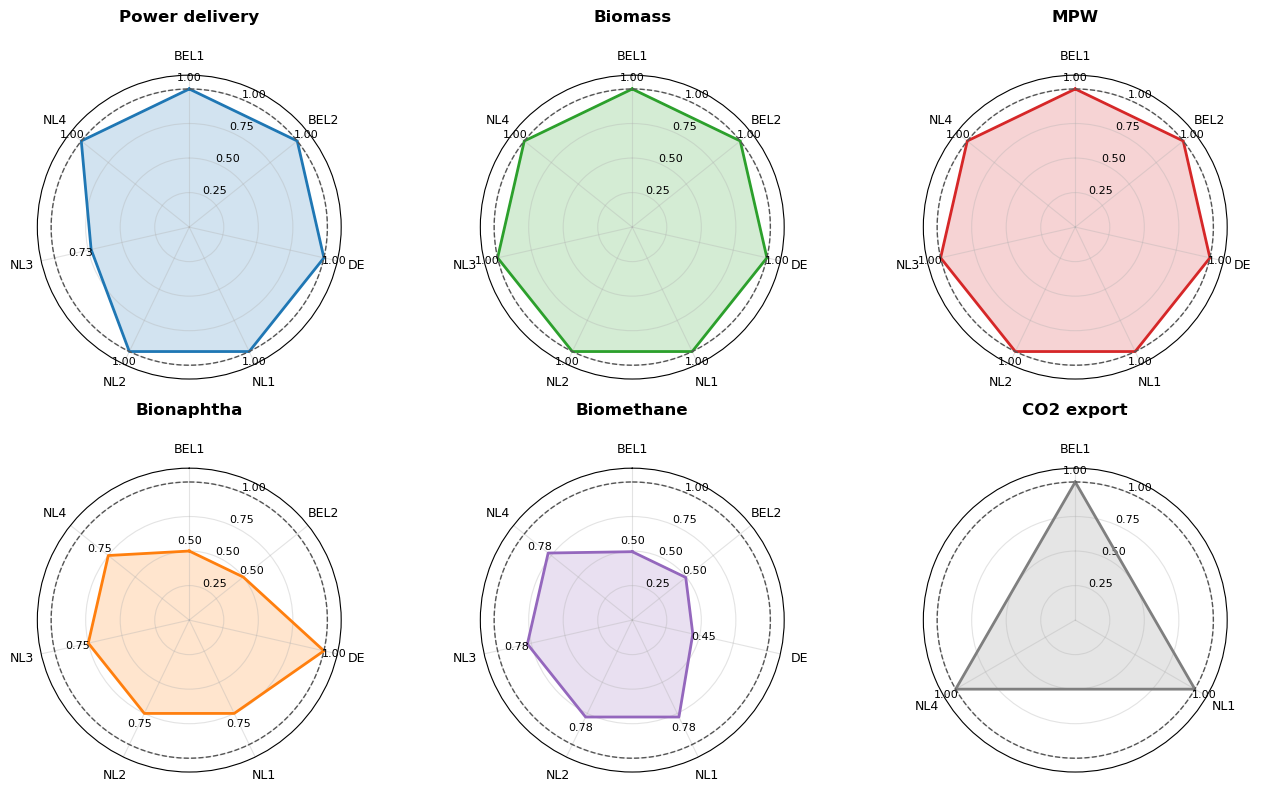


Raw limiting factors:

Spider input:


In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt


# =============================================================================
# User settings
# =============================================================================

H5_PATH = Path(r"output\high_feedstock_availability_5_dd\2050\optimization_results.h5")
CARRIERS_DIR = Path(r"case_studies\high_feedstock_availability_5_dd\2050\carriers")

INTERNAL_YEAR = "2022"

CLUSTERS_7 = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]
CO2_EXPORT_CLUSTERS = ["BEL1", "NL1", "NL4"]

COUNTRY_CLUSTERS = {
    "BE": ["BEL1", "BEL2"],
    "DE": ["DE"],
    "NL": ["NL1", "NL2", "NL3", "NL4"],
}

CLUSTER_COUNTRY = {
    cluster: country
    for country, clusters in COUNTRY_CLUSTERS.items()
    for cluster in clusters
}

POWER_CONNECTION_TECH = {
    "BE": "electricity_grid_connection_BE",
    "DE": "electricity_grid_connection_DE",
    "NL": "electricity_grid_connection_NL",
}

COUNTRY_LEVEL_FEEDSTOCKS = {
    "Biomass": {
        "excel_file": "biomass.xlsx",
        "h5_carrier": "biomass",
        "limit_col": "import_limit",
        "h5_dataset": "import",
    },
    "MPW": {
        "excel_file": "MPW.xlsx",
        "h5_carrier": "MPW",
        "limit_col": "import_limit",
        "h5_dataset": "import",
    },
    "Bionaphtha": {
        "excel_file": "naphtha_bio.xlsx",
        "h5_carrier": "naphtha_bio",
        "limit_col": "import_limit",
        "h5_dataset": "import",
    },
    "Biomethane": {
        "excel_file": "methane_bio.xlsx",
        "h5_carrier": "methane_bio",
        "limit_col": "import_limit",
        "h5_dataset": "import",
    },
}

CO2_EXPORT_FACTOR = {
    "excel_file": "CO2.xlsx",
    "h5_carrier": "CO2",
    "limit_col": "export_limit",
    "h5_dataset": "export",
}

OUTPUT_RAW_CSV = Path("limiting_factors_2050_raw.csv")
OUTPUT_SPIDER_INPUT_CSV = Path("limiting_factors_2050_spider_input.csv")
OUTPUT_PNG = Path("limiting_factors_2050_spider_dashboard.png")
OUTPUT_PDF = Path("limiting_factors_2050_spider_dashboard.pdf")


# =============================================================================
# Plot settings
# =============================================================================

FACTOR_COLORS = {
    "Power delivery": "#1f77b4",
    "Biomass": "#2ca02c",
    "MPW": "#d62728",
    "Bionaphtha": "#ff7f0e",
    "Biomethane": "#9467bd",
    "CO2 export": "#7f7f7f",
}

RMAX = 1.10
ANNOTATE_VALUES = True


# =============================================================================
# HDF5 helpers
# =============================================================================

def to_scalar(x):
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")

    if isinstance(x, np.generic):
        value = x.item()
        if isinstance(value, (bytes, bytearray)):
            return value.decode("utf-8")
        return value

    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        value = x.reshape(-1)[0].item()
        if isinstance(value, (bytes, bytearray)):
            return value.decode("utf-8")
        return value

    return x


def load_factors(h5_path: str | Path, year: str = INTERNAL_YEAR) -> np.ndarray:
    h5_path = Path(h5_path)

    with h5py.File(h5_path, "r") as h5:
        path = f"k_means_specs/{year}/factors"
        if path not in h5:
            raise KeyError(f"Missing HDF5 path: {path}")

        return np.asarray(h5[path][()], dtype=float)


def weighted_annual_sum(values: np.ndarray, factors: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    factors = np.asarray(factors, dtype=float)

    if values.shape == factors.shape:
        return float(np.sum(values * factors))

    if values.ndim == 1 and len(values) == len(factors):
        return float(np.sum(values * factors))

    raise ValueError(
        f"Cannot apply weighting factors: values shape={values.shape}, "
        f"factors shape={factors.shape}"
    )


def read_h5_series(
    h5_path: str | Path,
    dataset_path: str,
    default_zero_like: np.ndarray | None = None,
) -> np.ndarray:
    h5_path = Path(h5_path)

    with h5py.File(h5_path, "r") as h5:
        if dataset_path not in h5:
            if default_zero_like is None:
                raise KeyError(f"Missing HDF5 path: {dataset_path}")
            return np.zeros_like(default_zero_like, dtype=float)

        return np.asarray(h5[dataset_path][()], dtype=float)


# =============================================================================
# Excel helpers
# =============================================================================

def read_excel_column_sum(
    excel_path: str | Path,
    sheet_name: str,
    column: str,
    missing_ok: bool = False,
) -> float:
    excel_path = Path(excel_path)

    if not excel_path.exists():
        if missing_ok:
            return 0.0
        raise FileNotFoundError(f"Missing Excel file: {excel_path}")

    try:
        df = pd.read_excel(excel_path, sheet_name=sheet_name)
    except ValueError:
        if missing_ok:
            return 0.0
        raise ValueError(f"Missing sheet '{sheet_name}' in file {excel_path}")

    if column not in df.columns:
        if missing_ok:
            return 0.0
        raise KeyError(f"Missing column '{column}' in {excel_path}, sheet '{sheet_name}'")

    return float(pd.to_numeric(df[column], errors="coerce").fillna(0.0).sum())


def read_excel_column_max_or_first(
    excel_path: str | Path,
    sheet_name: str,
    column: str,
    missing_ok: bool = False,
) -> float:
    """
    Used for power delivery import_limit, which should be constant over time.
    To be robust, this returns max(import_limit), not first value.
    """
    excel_path = Path(excel_path)

    if not excel_path.exists():
        if missing_ok:
            return 0.0
        raise FileNotFoundError(f"Missing Excel file: {excel_path}")

    try:
        df = pd.read_excel(excel_path, sheet_name=sheet_name)
    except ValueError:
        if missing_ok:
            return 0.0
        raise ValueError(f"Missing sheet '{sheet_name}' in file {excel_path}")

    if column not in df.columns:
        if missing_ok:
            return 0.0
        raise KeyError(f"Missing column '{column}' in {excel_path}, sheet '{sheet_name}'")

    values = pd.to_numeric(df[column], errors="coerce").dropna()

    if values.empty:
        return 0.0

    return float(values.max())


# =============================================================================
# Constraint extraction
# =============================================================================

def utilisation(actual: float, limit: float) -> float:
    if limit <= 0:
        if actual <= 1e-12:
            return np.nan
        return np.inf
    return actual / limit


def compute_power_delivery_utilisation(
    h5_path: str | Path = H5_PATH,
    carriers_dir: str | Path = CARRIERS_DIR,
    year: str = INTERNAL_YEAR,
) -> pd.DataFrame:
    """
    Cluster-level power delivery:
      limit  = electricity_grid.xlsx, sheet cluster, column import_limit, max value
      actual = max H5 technology_operation electricity_grid_input
    """
    h5_path = Path(h5_path)
    carriers_dir = Path(carriers_dir)
    excel_path = carriers_dir / "electricity_grid.xlsx"

    rows = []

    for cluster in CLUSTERS_7:
        country = CLUSTER_COUNTRY[cluster]
        tech = POWER_CONNECTION_TECH[country]

        limit = read_excel_column_max_or_first(
            excel_path=excel_path,
            sheet_name=cluster,
            column="import_limit",
            missing_ok=False,
        )

        dataset_path = (
            f"operation/technology_operation/{year}/"
            f"{cluster}/{tech}/electricity_grid_input"
        )

        series = read_h5_series(
            h5_path=h5_path,
            dataset_path=dataset_path,
            default_zero_like=None,
        )

        actual = float(np.nanmax(series))

        rows.append({
            "factor": "Power delivery",
            "level": "cluster",
            "region": cluster,
            "country": country,
            "actual": actual,
            "limit": limit,
            "utilisation": utilisation(actual, limit),
            "source_limit": str(excel_path),
            "source_actual": dataset_path,
        })

    return pd.DataFrame(rows)


def compute_country_feedstock_utilisation(
    factor_name: str,
    config: dict,
    h5_path: str | Path = H5_PATH,
    carriers_dir: str | Path = CARRIERS_DIR,
    year: str = INTERNAL_YEAR,
) -> pd.DataFrame:
    """
    Country-level feedstock availability:
      limit  = sum over clusters in country of Excel import_limit
      actual = weighted annual sum of H5 import, summed over clusters in country
    """
    h5_path = Path(h5_path)
    carriers_dir = Path(carriers_dir)
    factors = load_factors(h5_path, year=year)

    excel_path = carriers_dir / config["excel_file"]
    h5_carrier = config["h5_carrier"]
    h5_dataset = config["h5_dataset"]
    limit_col = config["limit_col"]

    rows = []

    for country, clusters in COUNTRY_CLUSTERS.items():
        country_limit = 0.0
        country_actual = 0.0

        limit_details = {}
        actual_details = {}

        for cluster in clusters:
            cluster_limit = read_excel_column_sum(
                excel_path=excel_path,
                sheet_name=cluster,
                column=limit_col,
                missing_ok=True,
            )
            country_limit += cluster_limit
            limit_details[f"{cluster}_limit"] = cluster_limit

            dataset_path = (
                f"operation/energy_balance/{year}/"
                f"{cluster}/{h5_carrier}/{h5_dataset}"
            )

            series = read_h5_series(
                h5_path=h5_path,
                dataset_path=dataset_path,
                default_zero_like=factors,
            )

            cluster_actual = weighted_annual_sum(series, factors)
            country_actual += cluster_actual
            actual_details[f"{cluster}_actual"] = cluster_actual

        row = {
            "factor": factor_name,
            "level": "country",
            "region": country,
            "country": country,
            "actual": country_actual,
            "limit": country_limit,
            "utilisation": utilisation(country_actual, country_limit),
            "source_limit": str(excel_path),
            "source_actual": f"operation/energy_balance/{year}/{{cluster}}/{h5_carrier}/{h5_dataset}",
        }
        row.update(limit_details)
        row.update(actual_details)
        rows.append(row)

    return pd.DataFrame(rows)


def compute_co2_export_utilisation(
    h5_path: str | Path = H5_PATH,
    carriers_dir: str | Path = CARRIERS_DIR,
    year: str = INTERNAL_YEAR,
) -> pd.DataFrame:
    """
    Cluster-level CO2 export:
      limit  = CO2.xlsx, sheet cluster, column export_limit, sum over time
      actual = weighted annual sum of H5 CO2 export
    valid only for BEL1, NL1, NL4
    """
    h5_path = Path(h5_path)
    carriers_dir = Path(carriers_dir)
    factors = load_factors(h5_path, year=year)

    excel_path = carriers_dir / CO2_EXPORT_FACTOR["excel_file"]
    h5_carrier = CO2_EXPORT_FACTOR["h5_carrier"]
    h5_dataset = CO2_EXPORT_FACTOR["h5_dataset"]
    limit_col = CO2_EXPORT_FACTOR["limit_col"]

    rows = []

    for cluster in CO2_EXPORT_CLUSTERS:
        country = CLUSTER_COUNTRY[cluster]

        limit = read_excel_column_sum(
            excel_path=excel_path,
            sheet_name=cluster,
            column=limit_col,
            missing_ok=False,
        )

        dataset_path = (
            f"operation/energy_balance/{year}/"
            f"{cluster}/{h5_carrier}/{h5_dataset}"
        )

        series = read_h5_series(
            h5_path=h5_path,
            dataset_path=dataset_path,
            default_zero_like=factors,
        )

        actual = weighted_annual_sum(series, factors)

        rows.append({
            "factor": "CO2 export",
            "level": "cluster",
            "region": cluster,
            "country": country,
            "actual": actual,
            "limit": limit,
            "utilisation": utilisation(actual, limit),
            "source_limit": str(excel_path),
            "source_actual": dataset_path,
        })

    return pd.DataFrame(rows)


def compute_all_limiting_factors() -> pd.DataFrame:
    frames = []

    frames.append(
        compute_power_delivery_utilisation(
            h5_path=H5_PATH,
            carriers_dir=CARRIERS_DIR,
            year=INTERNAL_YEAR,
        )
    )

    for factor_name, config in COUNTRY_LEVEL_FEEDSTOCKS.items():
        frames.append(
            compute_country_feedstock_utilisation(
                factor_name=factor_name,
                config=config,
                h5_path=H5_PATH,
                carriers_dir=CARRIERS_DIR,
                year=INTERNAL_YEAR,
            )
        )

    frames.append(
        compute_co2_export_utilisation(
            h5_path=H5_PATH,
            carriers_dir=CARRIERS_DIR,
            year=INTERNAL_YEAR,
        )
    )

    out = pd.concat(frames, ignore_index=True)
    return out


# =============================================================================
# Spider input construction
# =============================================================================

def expand_country_values_to_clusters(country_values: dict[str, float]) -> dict[str, float]:
    """
    Repeat country-level values on all cluster spokes of that country.
    """
    return {
        "BEL1": country_values.get("BE", np.nan),
        "BEL2": country_values.get("BE", np.nan),
        "DE": country_values.get("DE", np.nan),
        "NL1": country_values.get("NL", np.nan),
        "NL2": country_values.get("NL", np.nan),
        "NL3": country_values.get("NL", np.nan),
        "NL4": country_values.get("NL", np.nan),
    }


def build_spider_input(raw_df: pd.DataFrame) -> dict[str, pd.Series]:
    """
    Returns one Series per factor.

    For country-level factors, values are repeated across clusters in the same country.
    """
    spider = {}

    # Power delivery: cluster-level, 7 spokes
    power = (
        raw_df[raw_df["factor"] == "Power delivery"]
        .set_index("region")["utilisation"]
        .reindex(CLUSTERS_7)
    )
    spider["Power delivery"] = power

    # Country-level factors: repeated on cluster spokes
    for factor_name in COUNTRY_LEVEL_FEEDSTOCKS.keys():
        country_values = (
            raw_df[raw_df["factor"] == factor_name]
            .set_index("region")["utilisation"]
            .to_dict()
        )
        expanded = expand_country_values_to_clusters(country_values)
        spider[factor_name] = pd.Series(expanded).reindex(CLUSTERS_7)

    # CO2 export: only 3 spokes
    co2 = (
        raw_df[raw_df["factor"] == "CO2 export"]
        .set_index("region")["utilisation"]
        .reindex(CO2_EXPORT_CLUSTERS)
    )
    spider["CO2 export"] = co2

    return spider


def export_spider_input(spider: dict[str, pd.Series], output_path: str | Path):
    """
    Export spider input in a rectangular CSV.
    Missing values are kept as NaN.
    """
    all_indices = sorted(set().union(*[set(s.index) for s in spider.values()]))

    df = pd.DataFrame(index=all_indices)

    for factor_name, series in spider.items():
        df[factor_name] = series

    # df.to_csv(output_path, index=True)
    return df


# =============================================================================
# Plotting
# =============================================================================

def make_radar(
    ax,
    labels: list[str],
    values: np.ndarray,
    title: str,
    color: str,
    rmax: float = RMAX,
    annotate: bool = ANNOTATE_VALUES,
):
    values = np.asarray(values, dtype=float)

    # Replace NaN with zero for plotting, but avoid writing labels for NaN.
    is_nan = np.isnan(values)
    plot_values = np.where(is_nan, 0.0, values)

    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

    angles_closed = np.concatenate([angles, [angles[0]]])
    values_closed = np.concatenate([plot_values, [plot_values[0]]])

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.plot(angles_closed, values_closed, color=color, linewidth=2)
    ax.fill(angles_closed, values_closed, color=color, alpha=0.20)

    # Limit circle at 1.0
    theta_dense = np.linspace(0, 2 * np.pi, 360)
    ax.plot(theta_dense, np.ones_like(theta_dense), linestyle="--", linewidth=1, color="#555555")

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9)

    ax.set_ylim(0, rmax)
    ax.set_yticks([0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=8)

    ax.set_title(title, fontsize=12, pad=20, fontweight="bold")

    if annotate:
        for angle, val, missing in zip(angles, values, is_nan):
            if missing:
                continue
            r_text = min(float(val) + 0.08, rmax - 0.02)
            ax.text(
                angle,
                r_text,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    ax.grid(alpha=0.35)


def plot_spider_dashboard(
    spider: dict[str, pd.Series],
    output_png: str | Path = OUTPUT_PNG,
    output_pdf: str | Path = OUTPUT_PDF,
):
    plot_order = [
        "Power delivery",
        "Biomass",
        "MPW",
        "Bionaphtha",
        "Biomethane",
        "CO2 export",
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(14, 9),
        subplot_kw={"projection": "polar"},
    )
    axes = axes.flatten()

    for ax, factor_name in zip(axes, plot_order):
        series = spider[factor_name]

        labels = list(series.index)
        values = series.values.astype(float)

        make_radar(
            ax=ax,
            labels=labels,
            values=values,
            title=factor_name,
            color=FACTOR_COLORS.get(factor_name, "#1f77b4"),
            rmax=RMAX,
            annotate=ANNOTATE_VALUES,
        )

    # fig.text(
    #     0.5,
    #     0.035,
    #     (
    #         "For country-level constraints (Biomass, MPW, Bionaphtha, Biomethane), "
    #         "the utilisation ratio is repeated on all cluster spokes belonging to the same country."
    #     ),
    #     ha="center",
    #     va="center",
    #     fontsize=10,
    # )

    # fig.suptitle(
    #     "Limiting factor utilisation in 2050",
    #     fontsize=16,
    #     fontweight="bold",
    #     y=0.98,
    # )

    plt.tight_layout(rect=[0.02, 0.06, 0.98, 0.95])

    # fig.savefig(output_png, dpi=600, bbox_inches="tight")
    # fig.savefig(output_pdf, bbox_inches="tight")

    plt.show()

    return fig


# =============================================================================
# Main
# =============================================================================

if __name__ == "__main__":
    raw = compute_all_limiting_factors()
    # raw.to_csv(OUTPUT_RAW_CSV, index=False)

    spider = build_spider_input(raw)
    spider_input_df = export_spider_input(spider, OUTPUT_SPIDER_INPUT_CSV)

    fig = plot_spider_dashboard(
        spider=spider,
        output_png=OUTPUT_PNG,
        output_pdf=OUTPUT_PDF,
    )

    # print("Saved:")
    # print(f" - {OUTPUT_RAW_CSV}")
    # print(f" - {OUTPUT_SPIDER_INPUT_CSV}")
    # print(f" - {OUTPUT_PNG}")
    # print(f" - {OUTPUT_PDF}")

    print("\nRaw limiting factors:")
    # print(raw[["factor", "level", "region", "actual", "limit", "utilisation"]])

    print("\nSpider input:")
    # print(spider_input_df)

Costs for feedstocks

In [ ]:
from __future__ import annotations

from pathlib import Path
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EPS = 1e-9

# Optional preferred order / colors for common feedstocks.
CARRIER_ORDER = [
    "naphtha",
    "methane",
    "biomass",
    "MPW",
    "electricity_grid",
    "CO2",
    "hydrogen",
    "feedgas",
    "crackergas",
]

CARRIER_COLORS = {
    "naphtha": "#4e79a7",
    "methane": "#195494",
    "biomass": "#59a14f",
    "MPW": "#df1ca7",
    "electricity_grid": "#e9d947",
    "CO2": "#76b7b2",
    "hydrogen": "#edc948",
    "feedgas": "#9c755f",
    "crackergas": "#bab0ab",
    "naphtha_bio": "#2c9b1d",
    "methane_bio": "#027402",
}

LABELS = {
    "naphtha": "Naphtha",
    "methane": "Methane",
    "biomass": "Biomass",
    "MPW": "Plastic waste",
    "electricity_grid": "Grid electricity",
    "CO2": "CO2",
    "hydrogen": "Hydrogen",
    "feedgas": "Feedgas",
    "crackergas": "Crackergas",
    "naphtha_bio": "Bio-naphtha",
    "methane_bio": "Bio-methane",
}

# Carriers that are usually not meaningful as imported feedstocks for this plot.
DEFAULT_EXCLUDE = {
    "ammonia",
    "methanol",
    "ethylene",
    "propylene",
    "olefins",
    "cracking_byproducts",
    "hydrogen_transported",
    "electricity",
    "heat",
    "HBfeed",
}


def infer_year_from_path_or_period(path: str | Path, period: str) -> int | str:
    """
    Infer the scenario/reference year associated with an H5 result file.

    Priority:
    1. a 4-digit year in the parent folders, starting from the closest parent;
    2. a 4-digit year in the file stem;
    3. the internal H5 period as fallback.
    """
    path = Path(path)

    for parent in path.parents:
        folder_name = parent.name
        if re.fullmatch(r"(19|20)\d{2}", folder_name):
            return int(folder_name)

    match = re.search(r"(19|20)\d{2}", path.stem)
    if match:
        return int(match.group(0))

    period_str = str(period)
    if re.fullmatch(r"\d{4}", period_str):
        return int(period_str)

    return period_str


def weighted_sum(values: np.ndarray, factors: np.ndarray | None) -> float:
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 0:
        return float(arr)
    if factors is not None and arr.shape == factors.shape:
        return float(np.dot(arr, factors))
    if factors is not None and arr.ndim == 1 and len(arr) == len(factors):
        return float(np.dot(arr, factors))
    return float(np.nansum(arr))


def annual_import_cost(import_values: np.ndarray, import_prices: np.ndarray, factors: np.ndarray | None) -> float:
    values = np.asarray(import_values, dtype=float)
    prices = np.asarray(import_prices, dtype=float)

    if values.ndim == 0 and prices.ndim == 0:
        return float(values * prices)

    prod = values * prices
    if factors is not None and prod.shape == factors.shape:
        return float(np.dot(prod, factors))
    if factors is not None and prod.ndim == 1 and len(prod) == len(factors):
        return float(np.dot(prod, factors))
    return float(np.nansum(prod))


def read_feedstock_spending(
    h5_path: str | Path,
    include_carriers: list[str] | tuple[str, ...] | None = None,
    exclude_carriers: set[str] | None = None,
) -> pd.DataFrame:
    """
    Return one row per (year, carrier) with annual imported amount and annual spending,
    summed over all nodes.
    """
    h5_path = Path(h5_path)
    rows: list[dict] = []
    exclude_carriers = set() if exclude_carriers is None else set(exclude_carriers)

    with h5py.File(h5_path, "r") as h5:
        eb_root = h5["operation"]["energy_balance"]

        for period in eb_root.keys():
            year = infer_year_from_path_or_period(h5_path, period)

            factors = None
            if "k_means_specs" in h5 and period in h5["k_means_specs"]:
                if "factors" in h5["k_means_specs"][period]:
                    factors = np.asarray(h5["k_means_specs"][period]["factors"][()], dtype=float)

            carrier_totals: dict[str, dict[str, float]] = {}

            for node in eb_root[period].keys():
                for carrier in eb_root[period][node].keys():
                    if include_carriers is not None and carrier not in include_carriers:
                        continue
                    if carrier in exclude_carriers:
                        continue

                    group = eb_root[period][node][carrier]
                    if "import" not in group or "import_price" not in group:
                        continue

                    imported_amount = weighted_sum(group["import"][()], factors)
                    spending = annual_import_cost(group["import"][()], group["import_price"][()], factors)

                    if abs(imported_amount) <= EPS and abs(spending) <= EPS:
                        continue

                    if carrier not in carrier_totals:
                        carrier_totals[carrier] = {"import_amount": 0.0, "spending": 0.0}
                    carrier_totals[carrier]["import_amount"] += imported_amount
                    carrier_totals[carrier]["spending"] += spending

            for carrier, totals in carrier_totals.items():
                rows.append(
                    {
                        "year": year,
                        "carrier": carrier,
                        "import_amount": float(totals["import_amount"]),
                        "spending": float(totals["spending"]),
                    }
                )

    return pd.DataFrame(rows)


def analyze_h5_files(
    h5_files: list[str | Path],
    include_carriers: list[str] | tuple[str, ...] | None = None,
    exclude_carriers: set[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns
    -------
    amounts_df:
        columns = year, carrier, import_amount, spending
    shares_df:
        columns = year, carrier, import_amount, spending, total_spending, share
    """
    frames = []
    for h5_file in h5_files:
        df = read_feedstock_spending(
            h5_file,
            include_carriers=include_carriers,
            exclude_carriers=exclude_carriers,
        )
        if not df.empty:
            frames.append(df)

    if frames:
        amounts_df = pd.concat(frames, ignore_index=True)
    else:
        amounts_df = pd.DataFrame(columns=["year", "carrier", "import_amount", "spending"])

    if amounts_df.empty:
        shares_df = amounts_df.copy()
        shares_df["total_spending"] = []
        shares_df["share"] = []
        return amounts_df, shares_df

    amounts_df = (
        amounts_df.groupby(["year", "carrier"], as_index=False)[["import_amount", "spending"]]
        .sum()
    )

    totals = (
        amounts_df.groupby("year", as_index=False)["spending"]
        .sum()
        .rename(columns={"spending": "total_spending"})
    )

    shares_df = amounts_df.merge(totals, on="year", how="left")
    shares_df["share"] = np.where(
        shares_df["total_spending"].abs() > EPS,
        shares_df["spending"] / shares_df["total_spending"],
        np.nan,
    )

    return amounts_df, shares_df


def _sort_years(years):
    def key(y):
        try:
            return int(y)
        except Exception:
            return str(y)
    return sorted(years, key=key)


def plot_feedstock_spending_shares(
    shares_df: pd.DataFrame,
    output_path: str | Path = "feedstock_spending_shares.png",
    carrier_order: list[str] = CARRIER_ORDER,
    carrier_colors: dict[str, str] = CARRIER_COLORS,
    label_map: dict[str, str] = LABELS,
):
    """
    Plot annual spending shares by feedstock.
    Falls back to stacked bars when only one year is available.
    """
    output_path = Path(output_path)

    if shares_df.empty:
        raise ValueError("shares_df is empty: no spending data found to plot.")

    years = _sort_years(shares_df["year"].dropna().unique())
    x_numeric = np.array([int(y) if str(y).isdigit() else i for i, y in enumerate(years)])

    pivot = (
        shares_df.pivot_table(index="year", columns="carrier", values="share", aggfunc="sum")
        .reindex(index=years)
        .fillna(0.0)
    )

    ordered_carriers = [c for c in carrier_order if c in pivot.columns]
    ordered_carriers += [c for c in pivot.columns if c not in ordered_carriers]

    y_values = [pivot[c].values for c in ordered_carriers]
    colors = [carrier_colors.get(c, None) for c in ordered_carriers]
    labels = [label_map.get(c, c) for c in ordered_carriers]

    fig, ax = plt.subplots(figsize=(10, 6))

    if len(years) == 1:
        bottom = 0.0
        for lab, y, color in zip(labels, y_values, colors):
            value = float(y[0])
            if value <= EPS:
                continue
            ax.bar([0], [value], bottom=[bottom], label=lab, color=color)
            bottom += value
        ax.set_xticks([0])
        ax.set_xticklabels([str(years[0])])
    else:
        ax.stackplot(x_numeric, y_values, labels=labels, colors=colors)
        ax.set_xticks(x_numeric)
        ax.set_xticklabels([str(y) for y in years])

    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of total feedstock spending")
    ax.set_xlabel("Year")
    ax.set_title("Feedstock spending shares")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    fig.tight_layout()
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


if __name__ == "__main__":
    # Example 1: explicit list. Year is inferred from the parent folder name when available.
    h5_files = [
        r"output/base_case_5_dd/2020/optimization_results.h5",
        r"output/base_case_5_dd/2025/optimization_results.h5",
        r"output/base_case_5_dd/2030/optimization_results.h5",
        r"output/base_case_5_dd/2040/optimization_results.h5",
        r"output/base_case_5_dd/2050/optimization_results.h5"
    ]

    # Example 2: recursive discovery.
    # h5_files = sorted(Path("output\base_case_5_dd").glob("**/optimization_results.h5"))

    # If you want explicit control, set include_carriers to the feedstocks you care about.
    include_carriers = ["naphtha", "methane", "biomass", "MPW", "electricity_grid", "CO2", "hydrogen", "naphtha_bio", "methane_bio"]

    amounts, shares = analyze_h5_files(
        h5_files,
        include_carriers=include_carriers,
        exclude_carriers=DEFAULT_EXCLUDE,
    )

    # amounts.to_csv("feedstock_spending_amounts.csv", index=False)
    # shares.to_csv("feedstock_spending_shares.csv", index=False)

    plot_feedstock_spending_shares(
        shares,
        output_path="feedstock_spending_shares.png",
    )

    print("Saved:")
    print("  feedstock_spending_amounts.csv")
    print("  feedstock_spending_shares.csv")
    print("  feedstock_spending_shares.png")


Saved:
 - co2_transition_metrics.csv
 - co2_balance_area.png
 - feedstock_co2_potential_area.png
 - co2_transition_dashboard.png


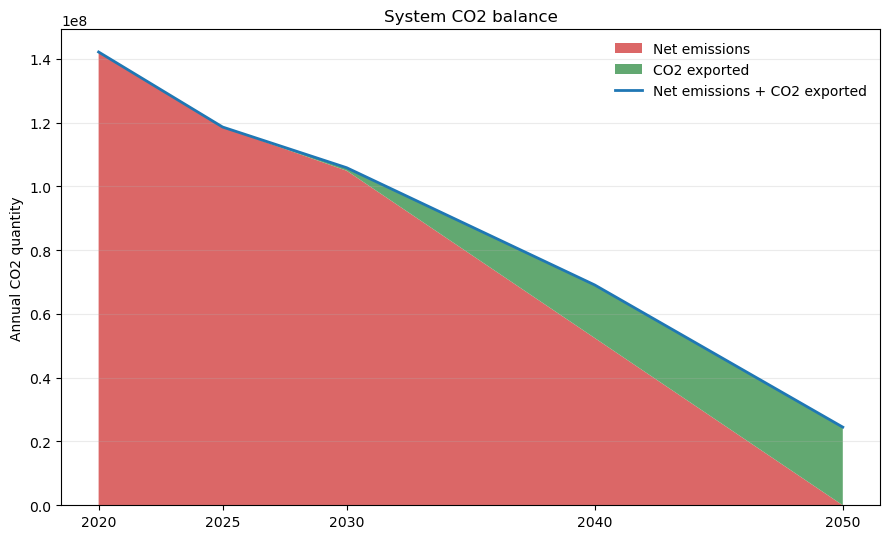

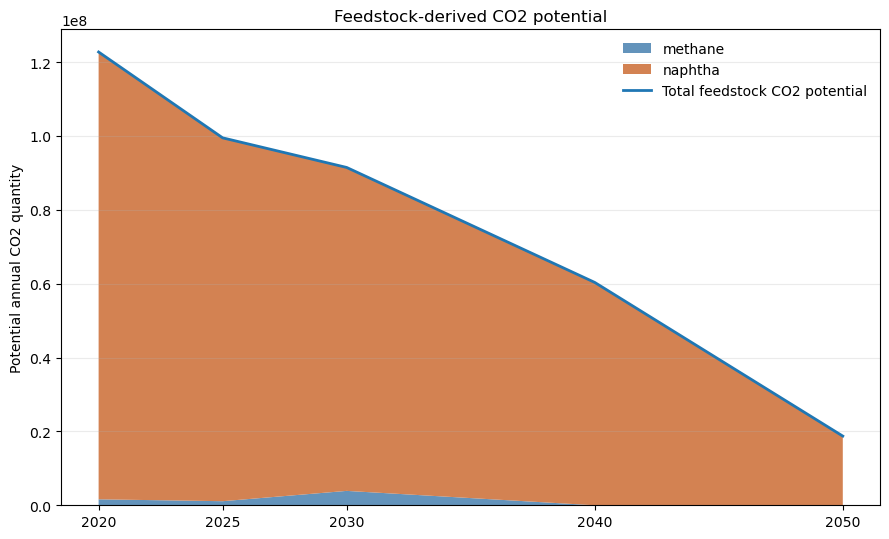

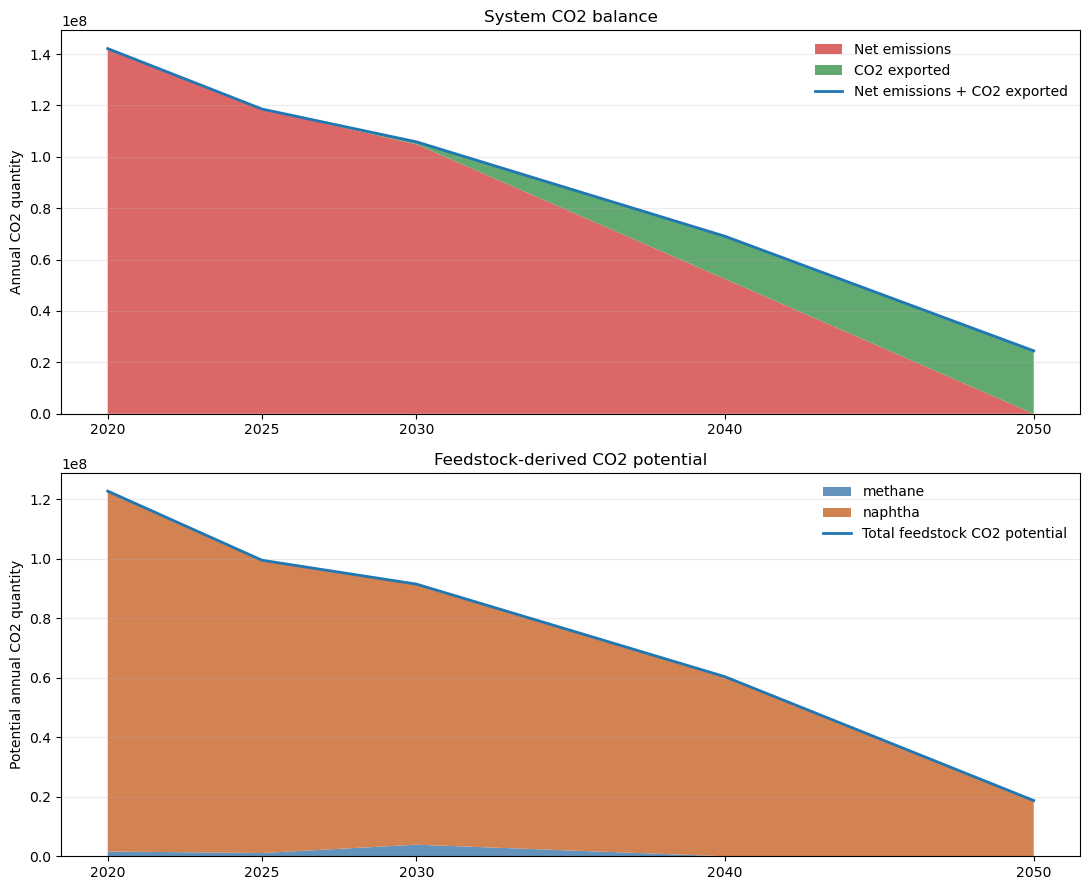

In [7]:
from __future__ import annotations

from pathlib import Path
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EPS = 1e-9

# -----------------------------------------------------------------------------
# User-editable settings
# -----------------------------------------------------------------------------
# Emission factors to convert imported feedstocks into a potential CO2 quantity.
# Units must be consistent with the units used in the H5 energy_balance import.
# Example: if imports are in t_feedstock/y, factors can be tCO2/t_feedstock.
FEEDSTOCK_EMISSION_FACTORS = {
    "methane": 2.78,
    "naphtha": 3.23,
    "feedgas": 2.78,
    "crackergas": 2.78,
    "methane_bio": 0.0,
    "naphtha_bio": 0.0,
    "biomass": 0.0,
    "MPW": 0.0,
}

FEEDSTOCK_ORDER = list(FEEDSTOCK_EMISSION_FACTORS.keys())
FEEDSTOCK_COLORS = {
    "methane": "#5b8db8",
    "naphtha": "#d17b49",
    "feedgas": "#8f8f8f",
    "crackergas": "#b59b57",
    "methane_bio": "#7fad6c",
    "naphtha_bio": "#95c17d",
    "biomass": "#6ba36d",
    "MPW": "#9a7bb0",
}

CO2_STACK_COLORS = {
    "net_emissions": "#d95f5f",
    "co2_exported": "#5aa469",
}


# -----------------------------------------------------------------------------
# Utility functions
# -----------------------------------------------------------------------------

def annualize_dataset(dataset: h5py.Dataset, factors: np.ndarray | None) -> float:
    arr = np.asarray(dataset[()])

    if arr.ndim == 0:
        return float(arr)

    arr = arr.astype(float, copy=False)

    if factors is not None and arr.shape == factors.shape:
        return float(np.dot(arr, factors))

    if factors is not None and arr.ndim == 1 and len(arr) == len(factors):
        return float(np.dot(arr, factors))

    return float(np.nansum(arr))


def infer_year_from_path_or_period(path: Path, period: str) -> int | str:
    """
    Infer the scenario/reference year associated with an H5 result file.

    Priority:
    1. a 4-digit year in the parent folders, starting from the closest parent;
       e.g. output/2030/optimization_results.h5 -> 2030
    2. a 4-digit year in the file stem
    3. the internal H5 period as fallback
    """
    path = Path(path)

    for parent in path.parents:
        folder_name = parent.name
        if re.fullmatch(r"(19|20)\d{2}", folder_name):
            return int(folder_name)

    match = re.search(r"(19|20)\d{2}", path.stem)
    if match:
        return int(match.group(0))

    period_str = str(period)
    if re.fullmatch(r"\d{4}", period_str):
        return int(period_str)

    return period_str


def sort_years(values):
    def key(v):
        try:
            return int(v)
        except Exception:
            return str(v)
    return sorted(values, key=key)

def _to_scalar(x):
    """HDF5 dataset -> python scalar, decodes bytes."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


# -----------------------------------------------------------------------------
# Core extraction
# -----------------------------------------------------------------------------

def extract_period_metrics(h5_path: str | Path) -> list[dict]:
    h5_path = Path(h5_path)
    rows = []

    with h5py.File(h5_path, "r") as h5:
        tech_root = h5["operation"]["technology_operation"]
        eb_root = h5["operation"]["energy_balance"]

        for period in tech_root.keys():
            year = infer_year_from_path_or_period(h5_path, period)

            factors = None
            if "k_means_specs" in h5 and period in h5["k_means_specs"]:
                if "factors" in h5["k_means_specs"][period]:
                    factors = np.asarray(h5["k_means_specs"][period]["factors"][()], dtype=float)

            # 1) Net emissions from technology_operation
            # emissions_pos = 0.0
            # emissions_neg = 0.0
            # for node in tech_root[period].keys():
            #     for technology in tech_root[period][node].keys():
            #         tech_group = tech_root[period][node][technology]
            #         if "emissions_pos" in tech_group:
            #             emissions_pos += annualize_dataset(tech_group["emissions_pos"], factors)
            #         if "emissions_neg" in tech_group:
            #             emissions_neg += annualize_dataset(tech_group["emissions_neg"], factors)

            emissions_pos = float(_to_scalar(h5["summary"]["emissions_pos"]))
            emissions_neg = float(_to_scalar(h5["summary"]["emissions_neg"]))
            net_emissions = float(_to_scalar(h5['summary']['emissions_net']))

            # 2) CO2 exported outside the system boundary from energy_balance
            co2_export = 0.0
            co2captured_export = 0.0
            for node in eb_root[period].keys():
                node_group = eb_root[period][node]

                if "CO2" in node_group and "export" in node_group["CO2"]:
                    co2_export += annualize_dataset(node_group["CO2"]["export"], factors)
                if "CO2captured" in node_group and "export" in node_group["CO2captured"]:
                    co2captured_export += annualize_dataset(node_group["CO2captured"]["export"], factors)

            total_exported = co2_export + co2captured_export

            # 3) Fossil-feedstock carbon potential from energy_balance imports
            feedstock_imports = {}
            feedstock_co2_potential = {}
            for carrier, ef in FEEDSTOCK_EMISSION_FACTORS.items():
                imported = 0.0
                for node in eb_root[period].keys():
                    node_group = eb_root[period][node]
                    if carrier in node_group and "import" in node_group[carrier]:
                        imported += annualize_dataset(node_group[carrier]["import"], factors)
                feedstock_imports[carrier] = imported
                feedstock_co2_potential[carrier] = imported * float(ef)

            row = {
                "file": str(h5_path),
                "year": year,
                "emissions_pos": emissions_pos,
                "emissions_neg": emissions_neg,
                "net_emissions": net_emissions,
                "co2_export": co2_export,
                "co2captured_export": co2captured_export,
                "co2_exported": total_exported,
                "gross_co2_accounted": net_emissions + total_exported,
            }
            for carrier, value in feedstock_imports.items():
                row[f"{carrier}_import"] = value
            for carrier, value in feedstock_co2_potential.items():
                row[f"{carrier}_co2_potential"] = value
            row["feedstock_co2_potential_total"] = sum(feedstock_co2_potential.values())
            rows.append(row)

    return rows


def analyze_h5_files(h5_files: list[str | Path]) -> pd.DataFrame:
    rows = []
    for h5_file in h5_files:
        rows.extend(extract_period_metrics(h5_file))
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("year").reset_index(drop=True)
    return df


# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------

def _x_positions(years):
    if all(str(y).isdigit() for y in years):
        return np.array([int(y) for y in years], dtype=float)
    return np.arange(len(years), dtype=float)


def plot_co2_balance(df: pd.DataFrame, output_path: str | Path = "co2_balance_area.png"):
    output_path = Path(output_path)
    years = sort_years(df["year"].tolist())
    sub = df.set_index("year").reindex(years)
    x = _x_positions(years)

    series_names = ["net_emissions", "co2_exported"]
    labels = ["Net emissions", "CO2 exported"]
    colors = [CO2_STACK_COLORS["net_emissions"], CO2_STACK_COLORS["co2_exported"]]
    y_values = [sub[name].fillna(0.0).values for name in series_names]
    total = sub["gross_co2_accounted"].fillna(0.0).values

    fig = plt.figure(figsize=(9, 5.5))
    ax = fig.add_subplot(111)

    if len(years) == 1:
        bottom = 0.0
        for label, y, color in zip(labels, y_values, colors):
            value = float(y[0])
            if abs(value) <= EPS:
                continue
            ax.bar([0], [value], bottom=[bottom], label=label, color=color)
            bottom += value
        ax.plot([0], total, marker="o", linewidth=2, label="Net emissions + CO2 exported")
        ax.set_xticks([0])
        ax.set_xticklabels([str(years[0])])
    else:
        ax.stackplot(x, y_values, labels=labels, colors=colors, alpha=0.95)
        ax.plot(x, total, linewidth=2, label="Net emissions + CO2 exported")
        ax.set_xticks(x)
        ax.set_xticklabels([str(y) for y in years])

    ax.set_title("System CO2 balance")
    ax.set_ylabel("Annual CO2 quantity")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


def plot_feedstock_potential(df: pd.DataFrame, output_path: str | Path = "feedstock_co2_potential_area.png"):
    output_path = Path(output_path)
    years = sort_years(df["year"].tolist())
    sub = df.set_index("year").reindex(years)
    x = _x_positions(years)

    carriers = []
    y_values = []
    colors = []
    for carrier in FEEDSTOCK_ORDER:
        col = f"{carrier}_co2_potential"
        if col in sub.columns:
            values = sub[col].fillna(0.0).values
            if np.any(np.abs(values) > EPS):
                carriers.append(carrier)
                y_values.append(values)
                colors.append(FEEDSTOCK_COLORS.get(carrier, None))

    total = sub["feedstock_co2_potential_total"].fillna(0.0).values

    fig = plt.figure(figsize=(9, 5.5))
    ax = fig.add_subplot(111)

    if len(years) == 1:
        bottom = 0.0
        for carrier, y, color in zip(carriers, y_values, colors):
            value = float(y[0])
            if abs(value) <= EPS:
                continue
            ax.bar([0], [value], bottom=[bottom], label=carrier, color=color)
            bottom += value
        ax.plot([0], total, marker="o", linewidth=2, label="Total feedstock CO2 potential")
        ax.set_xticks([0])
        ax.set_xticklabels([str(years[0])])
    else:
        ax.stackplot(x, y_values, labels=carriers, colors=colors, alpha=0.95)
        ax.plot(x, total, linewidth=2, label="Total feedstock CO2 potential")
        ax.set_xticks(x)
        ax.set_xticklabels([str(y) for y in years])

    ax.set_title("Feedstock-derived CO2 potential")
    ax.set_ylabel("Potential annual CO2 quantity")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


def plot_combined_dashboard(
    df: pd.DataFrame,
    output_path: str | Path = "co2_transition_dashboard.png",
):
    output_path = Path(output_path)
    years = sort_years(df["year"].tolist())
    sub = df.set_index("year").reindex(years)
    x = _x_positions(years)

    fig = plt.figure(figsize=(11, 9))

    # Top subplot: CO2 balance
    ax1 = fig.add_subplot(211)
    co2_series = [sub["net_emissions"].fillna(0.0).values, sub["co2_exported"].fillna(0.0).values]
    co2_labels = ["Net emissions", "CO2 exported"]
    co2_colors = [CO2_STACK_COLORS["net_emissions"], CO2_STACK_COLORS["co2_exported"]]
    co2_total = sub["gross_co2_accounted"].fillna(0.0).values

    if len(years) == 1:
        bottom = 0.0
        for label, y, color in zip(co2_labels, co2_series, co2_colors):
            value = float(y[0])
            if abs(value) <= EPS:
                continue
            ax1.bar([0], [value], bottom=[bottom], label=label, color=color)
            bottom += value
        ax1.plot([0], co2_total, marker="o", linewidth=2, label="Net emissions + CO2 exported")
        ax1.set_xticks([0])
        ax1.set_xticklabels([str(years[0])])
    else:
        ax1.stackplot(x, co2_series, labels=co2_labels, colors=co2_colors, alpha=0.95)
        ax1.plot(x, co2_total, linewidth=2, label="Net emissions + CO2 exported")
        ax1.set_xticks(x)
        ax1.set_xticklabels([str(y) for y in years])
    ax1.set_title("System CO2 balance")
    ax1.set_ylabel("Annual CO2 quantity")
    ax1.grid(axis="y", alpha=0.25)
    ax1.legend(frameon=False)

    # Bottom subplot: feedstock carbon potential
    ax2 = fig.add_subplot(212)
    fs_labels = []
    fs_series = []
    fs_colors = []
    for carrier in FEEDSTOCK_ORDER:
        col = f"{carrier}_co2_potential"
        if col in sub.columns:
            values = sub[col].fillna(0.0).values
            if np.any(np.abs(values) > EPS):
                fs_labels.append(carrier)
                fs_series.append(values)
                fs_colors.append(FEEDSTOCK_COLORS.get(carrier, None))
    fs_total = sub["feedstock_co2_potential_total"].fillna(0.0).values

    if len(years) == 1:
        bottom = 0.0
        for label, y, color in zip(fs_labels, fs_series, fs_colors):
            value = float(y[0])
            if abs(value) <= EPS:
                continue
            ax2.bar([0], [value], bottom=[bottom], label=label, color=color)
            bottom += value
        ax2.plot([0], fs_total, marker="o", linewidth=2, label="Total feedstock CO2 potential")
        ax2.set_xticks([0])
        ax2.set_xticklabels([str(years[0])])
    else:
        ax2.stackplot(x, fs_series, labels=fs_labels, colors=fs_colors, alpha=0.95)
        ax2.plot(x, fs_total, linewidth=2, label="Total feedstock CO2 potential")
        ax2.set_xticks(x)
        ax2.set_xticklabels([str(y) for y in years])
    ax2.set_title("Feedstock-derived CO2 potential")
    ax2.set_ylabel("Potential annual CO2 quantity")
    ax2.grid(axis="y", alpha=0.25)
    ax2.legend(frameon=False)

    fig.tight_layout()
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return fig


if __name__ == "__main__":
    # Example input list. The year is inferred from the parent folder.
    h5_files = [
        r"output/base_case_5_dd/2020/optimization_results.h5",
        r"output/base_case_5_dd/2025/optimization_results.h5",
        r"output/base_case_5_dd/2030/optimization_results.h5",
        r"output/base_case_5_dd/2040/optimization_results.h5",
        r"output/base_case_5_dd/2050/optimization_results.h5",
    ]

    # Keep only files that actually exist so the example block does not fail.
    h5_files = [Path(p) for p in h5_files if Path(p).exists()]

    if not h5_files:
        print("No H5 files found. Update 'h5_files' in the __main__ block.")
        raise SystemExit(0)

    metrics_df = analyze_h5_files(h5_files)
    # metrics_df.to_csv("co2_transition_metrics.csv", index=False)

    plot_co2_balance(metrics_df, "co2_balance_area.png")
    plot_feedstock_potential(metrics_df, "feedstock_co2_potential_area.png")
    plot_combined_dashboard(metrics_df, "co2_transition_dashboard.png")

    print("Saved:")
    print(" - co2_transition_metrics.csv")
    print(" - co2_balance_area.png")
    print(" - feedstock_co2_potential_area.png")
    print(" - co2_transition_dashboard.png")



=== Scenario summary ===
         scenario  reduction_target  total_cost_raw  existing_capex_addition  \
0   50% reduction              50.0    4.387682e+12             3.788410e+09   
1   60% reduction              60.0    4.391933e+12             3.903118e+09   
2   70% reduction              70.0    4.396211e+12             4.405045e+09   
3   80% reduction              80.0    4.400203e+12             5.525072e+09   
4   90% reduction              90.0    4.405368e+12             5.811104e+09   
5  100% reduction             100.0    4.505808e+12             6.511612e+09   

   total_cost_with_existing     emissions  
0              4.391470e+12  5.248505e+07  
1              4.395836e+12  4.198804e+07  
2              4.400616e+12  3.146787e+07  
3              4.405728e+12  2.097858e+07  
4              4.411179e+12  1.048929e+07  
5              4.512320e+12 -1.080334e-07  

=== MACC steps ===
   from_scenario     to_scenario  avoided_emissions    delta_cost  \
0  50% reduction

C:\Users\alessandro.magnino\AppData\Local\Temp\ipykernel_7932\1034574252.py:503: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\alessandro.magnino\anaconda3\envs\adopt-net0\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


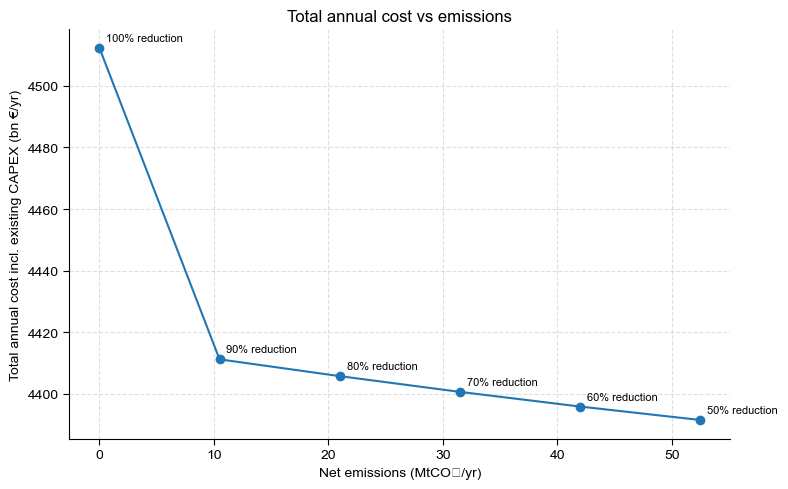

C:\Users\alessandro.magnino\AppData\Local\Temp\ipykernel_7932\1034574252.py:462: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


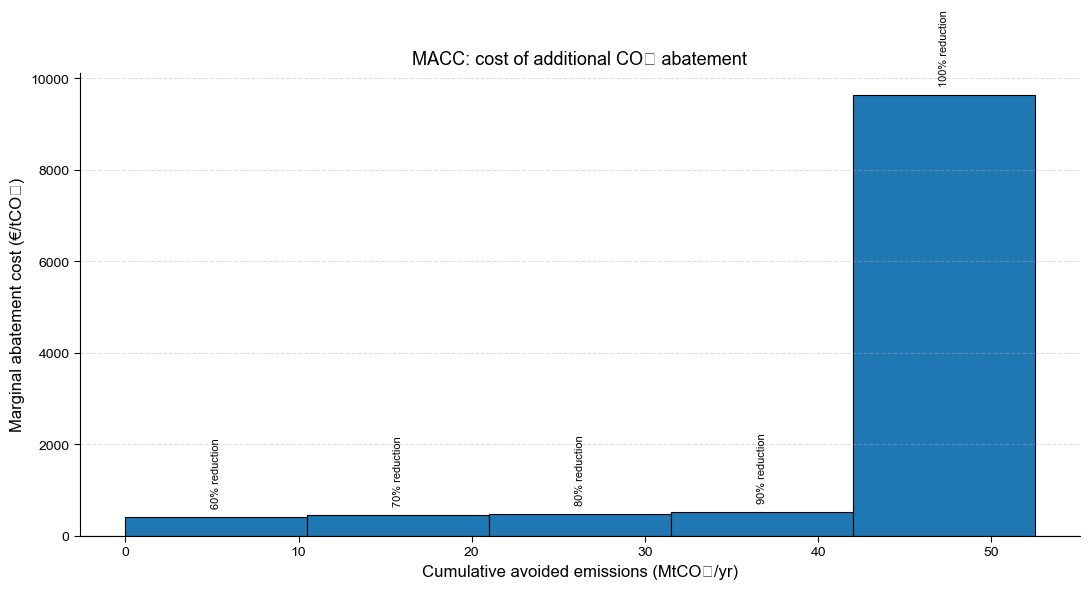


=== Reference case ===
Reference H5: output\base_case_00_5_dd\2050\optimization_results.h5
Raw total cost: 4.375e+12 €/yr
Existing CAPEX addition: 3.864e+09 €/yr
Corrected total cost: 4.379e+12 €/yr
Reference emissions: 9.302e+07 tCO2/yr

=== Abatement cost compared to 2030 ===
         scenario  reduction_target     emissions  total_cost_with_existing  \
0   50% reduction              50.0  5.248505e+07              4.391470e+12   
1   60% reduction              60.0  4.198804e+07              4.395836e+12   
2   70% reduction              70.0  3.146787e+07              4.400616e+12   
3   80% reduction              80.0  2.097858e+07              4.405728e+12   
4   90% reduction              90.0  1.048929e+07              4.411179e+12   
5  100% reduction             100.0 -1.080334e-07              4.512320e+12   

   avoided_emissions_vs_reference  delta_cost_vs_reference  \
0                    4.053829e+07             1.222069e+10   
1                    5.103530e+07         

C:\Users\alessandro.magnino\AppData\Local\Temp\ipykernel_7932\1034574252.py:580: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\alessandro.magnino\anaconda3\envs\adopt-net0\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


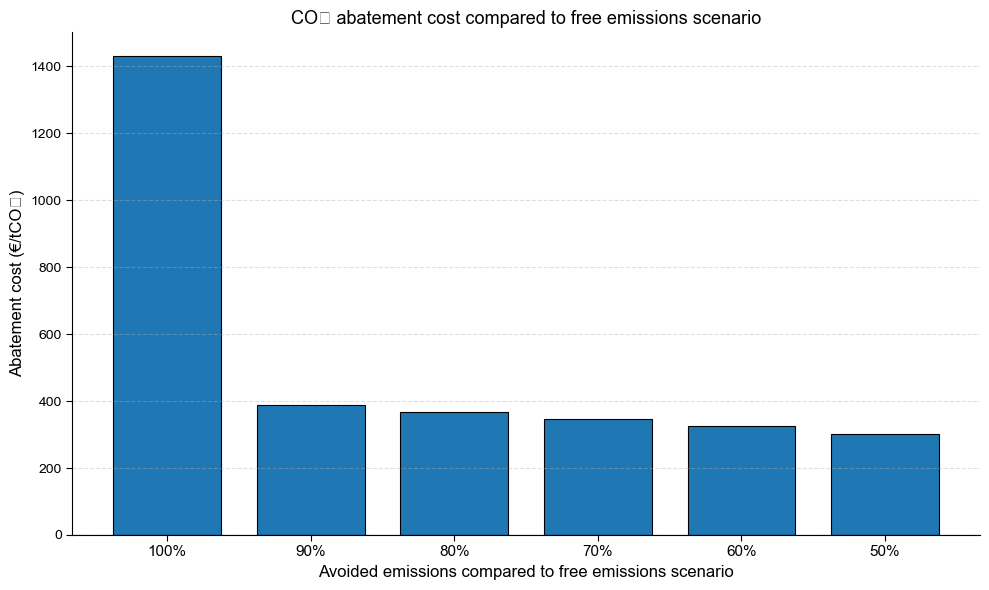

C:\Users\alessandro.magnino\AppData\Local\Temp\ipykernel_7932\1034574252.py:727: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to: figure\\CO2_abatement_cost_double.png


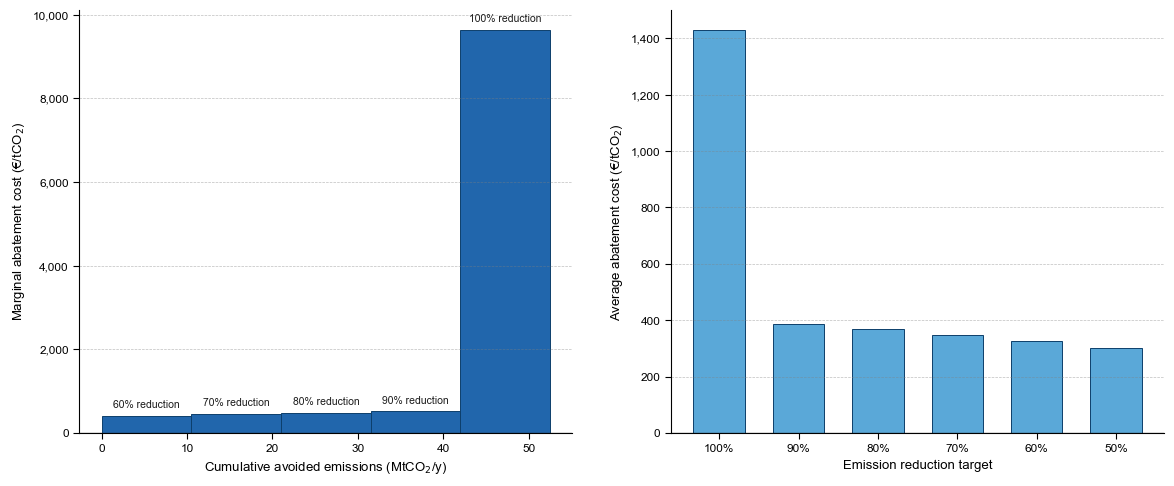

In [5]:
from __future__ import annotations

from pathlib import Path
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec


# ─────────────────────────────────────────────
#  Basic HDF5 helpers
# ─────────────────────────────────────────────

def _to_scalar(x):
    """HDF5 dataset -> Python scalar, decodes bytes."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    return x


def read_summary_scalar(h5_path: str | Path, name: str) -> float:
    """Reads a scalar from summary/{name}."""
    h5_path = Path(h5_path)
    ds_path = f"summary/{name}"

    with h5py.File(h5_path, "r") as f:
        if ds_path not in f:
            raise KeyError(f"Dataset '{ds_path}' not found in {h5_path}")
        return float(_to_scalar(f[ds_path][()]))


# ─────────────────────────────────────────────
#  Existing CAPEX correction
# ─────────────────────────────────────────────

def _annualise(unit_capex: float, size: float, discount_rate: float, lifetime: int) -> float:
    r, n = discount_rate, lifetime
    crf = r * (1 + r) ** n / ((1 + r) ** n - 1)
    return unit_capex * size * crf


def _find_json_recursive(technology_data_root: str | Path, tec_name: str) -> Path | None:
    root = Path(technology_data_root)
    matches = list(root.rglob(f"{tec_name}.json"))

    if not matches:
        return None

    if len(matches) > 1:
        print(f"[Warning] Found {len(matches)} JSON files for '{tec_name}', using: {matches[0]}")

    return matches[0]


def load_existing_annualized_capex(
    h5_path: str | Path,
    technology_data_root: str | Path,
    h5_year: str = "2022",
) -> pd.DataFrame:
    """
    Computes annualized CAPEX for components ending with '_existing'.

    Returns:
        node, component, size, unit_capex, discount_rate, lifetime,
        annualized_capex_existing
    """
    import json

    h5_path = Path(h5_path)
    base = f"design/nodes/{h5_year}"
    rows = []

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in {h5_path}")

        for node in f[base].keys():
            for comp in f[base][node].keys():
                if not comp.endswith("_existing"):
                    continue

                size_path = f"{base}/{node}/{comp}/size"
                if size_path not in f:
                    print(f"[Warning] size not found for {node}/{comp}, skipped.")
                    continue

                size = float(_to_scalar(f[size_path][()]))

                tec_name = comp[: -len("_existing")]
                json_path = _find_json_recursive(technology_data_root, tec_name)

                if json_path is None:
                    print(f"[Warning] JSON not found for '{tec_name}', skipped.")
                    continue

                with open(json_path, "r") as jf:
                    tec_data = json.load(jf)

                econ = tec_data["Economics"]
                unit_capex = float(econ["unit_capex"])
                discount_rate = float(econ["discount_rate"])
                lifetime = int(econ["lifetime"])

                annualized_capex = _annualise(
                    unit_capex=unit_capex,
                    size=size,
                    discount_rate=discount_rate,
                    lifetime=lifetime,
                )

                rows.append({
                    "node": str(node),
                    "component": str(comp),
                    "size": size,
                    "unit_capex": unit_capex,
                    "discount_rate": discount_rate,
                    "lifetime": lifetime,
                    "annualized_capex_existing": annualized_capex,
                })

    return pd.DataFrame(rows)


# ─────────────────────────────────────────────
#  Scenario helpers
# ─────────────────────────────────────────────

def infer_reduction_from_path(h5_path: str | Path) -> float | None:
    """
    Tries to infer the emission reduction target from the folder name.

    Examples:
        base_case_50_5_dd -> 50
        base_case_90_5_dd -> 90
        base_case_5_dd    -> 100  assumed net-zero / full abatement case
    """
    path_str = str(h5_path).replace("\\", "/")

    match = re.search(r"base_case_(\d+)_5_dd", path_str)
    if match:
        return float(match.group(1))

    # Your naming convention: base_case_5_dd is the full net-zero case.
    if "base_case_5_dd" in path_str:
        return 100.0

    return None


def scenario_label_from_path(h5_path: str | Path) -> str:
    reduction = infer_reduction_from_path(h5_path)

    if reduction is not None:
        return f"{reduction:.0f}% reduction"

    return Path(h5_path).parent.parent.name


def compute_existing_capex_addition(
    h5_path: str | Path,
    technology_data_root: str | Path,
    h5_year: str = "2022",
) -> float:
    """
    Computes the missing annualized CAPEX of existing technologies.
    This is the amount to add to summary/total_cost.
    """
    existing_df = load_existing_annualized_capex(
        h5_path=h5_path,
        technology_data_root=technology_data_root,
        h5_year=h5_year,
    )

    if existing_df.empty:
        return 0.0

    return float(existing_df["annualized_capex_existing"].sum())


def read_reference_case(
    reference_h5_path: str | Path,
    technology_data_root: str | Path,
    h5_year: str = "2022",
    emission_col: str = "emissions_net",
) -> dict[str, float]:
    """
    Reads the reference case from an H5 result file.

    The reference cost is corrected in the same way as the scenario costs:
        total_cost_with_existing = summary/total_cost + annualized CAPEX of existing technologies

    Returns:
        reference_cost
        reference_emissions
        reference_existing_capex_addition
        reference_total_cost_raw
    """
    reference_h5_path = Path(reference_h5_path)

    total_cost_raw = read_summary_scalar(reference_h5_path, "total_cost")
    emissions = read_summary_scalar(reference_h5_path, emission_col)

    existing_capex_addition = compute_existing_capex_addition(
        h5_path=reference_h5_path,
        technology_data_root=technology_data_root,
        h5_year=h5_year,
    )

    total_cost_with_existing = total_cost_raw + existing_capex_addition

    return {
        "reference_total_cost_raw": total_cost_raw,
        "reference_existing_capex_addition": existing_capex_addition,
        "reference_cost": total_cost_with_existing,
        "reference_emissions": emissions,
    }


def build_scenario_summary(
    h5_files: list[str | Path],
    technology_data_root: str | Path,
    h5_year: str = "2022",
    emission_col: str = "emissions_net",
) -> pd.DataFrame:
    """
    Builds a scenario-level dataframe for the MACC calculation.

    Parameters
    ----------
    h5_files:
        List of optimization_results.h5 files.
    technology_data_root:
        Path to adopt_net0/database/templates/technology_data.
    h5_year:
        Internal HDF5 year used in design/nodes/{h5_year}. In your uploaded file this is 2022.
    emission_col:
        Usually 'emissions_net'. You can switch to 'emissions_pos' if you want gross positive emissions.

    Returns
    -------
    DataFrame with:
        h5_path, scenario, reduction_target, total_cost_raw,
        existing_capex_addition, total_cost_with_existing,
        emissions
    """
    rows = []

    for h5_path in h5_files:
        h5_path = Path(h5_path)

        total_cost_raw = read_summary_scalar(h5_path, "total_cost")
        emissions = read_summary_scalar(h5_path, emission_col)

        existing_capex_addition = compute_existing_capex_addition(
            h5_path=h5_path,
            technology_data_root=technology_data_root,
            h5_year=h5_year,
        )

        total_cost_with_existing = total_cost_raw + existing_capex_addition

        rows.append({
            "h5_path": str(h5_path),
            "scenario": scenario_label_from_path(h5_path),
            "reduction_target": infer_reduction_from_path(h5_path),
            "total_cost_raw": total_cost_raw,
            "existing_capex_addition": existing_capex_addition,
            "total_cost_with_existing": total_cost_with_existing,
            "emissions": emissions,
        })

    df = pd.DataFrame(rows)

    # Prefer ordering by inferred reduction target if available.
    if df["reduction_target"].notna().all():
        df = df.sort_values("reduction_target", ascending=True)
    else:
        # fallback: sort from highest emissions to lowest emissions
        df = df.sort_values("emissions", ascending=False)

    return df.reset_index(drop=True)


# ─────────────────────────────────────────────
#  MACC calculation
# ─────────────────────────────────────────────

def compute_macc_steps(
    scenario_df: pd.DataFrame,
    cost_col: str = "total_cost_with_existing",
    emission_col: str = "emissions",
) -> pd.DataFrame:
    """
    Computes marginal abatement costs between consecutive scenarios.

    The dataframe must be ordered from the least stringent case to the most stringent case.

    For each step:
        avoided_emissions = emissions_previous - emissions_current
        delta_cost = cost_current - cost_previous
        macc = delta_cost / avoided_emissions

    Units:
        cost is €/year and emissions are tCO2/year,
        macc is €/tCO2.
    """
    d = scenario_df.copy().reset_index(drop=True)

    rows = []

    for i in range(1, len(d)):
        prev = d.loc[i - 1]
        curr = d.loc[i]

        avoided = prev[emission_col] - curr[emission_col]
        delta_cost = curr[cost_col] - prev[cost_col]

        if avoided <= 0:
            print(
                "[Warning] Non-positive avoided emissions between "
                f"{prev['scenario']} and {curr['scenario']}. "
                "This step is skipped."
            )
            continue

        rows.append({
            "from_scenario": prev["scenario"],
            "to_scenario": curr["scenario"],
            "step_label": f"{prev['scenario']} → {curr['scenario']}",
            "emissions_from": prev[emission_col],
            "emissions_to": curr[emission_col],
            "avoided_emissions": avoided,
            "delta_cost": delta_cost,
            "macc_eur_per_tco2": delta_cost / avoided,
        })

    macc_df = pd.DataFrame(rows)

    if macc_df.empty:
        return macc_df

    macc_df["cumulative_avoided_emissions"] = macc_df["avoided_emissions"].cumsum()
    macc_df["x_left"] = macc_df["cumulative_avoided_emissions"] - macc_df["avoided_emissions"]
    macc_df["x_center"] = macc_df["x_left"] + 0.5 * macc_df["avoided_emissions"]

    return macc_df


def compute_abatement_vs_reference(
    scenario_df: pd.DataFrame,
    reference_cost: float,
    reference_emissions: float,
    cost_col: str = "total_cost_with_existing",
    emission_col: str = "emissions",
) -> pd.DataFrame:
    """
    Computes average abatement cost of each scenario compared to a reference year/case,
    e.g. 2030.

    For each scenario:
        avoided_emissions = reference_emissions - emissions_scenario
        delta_cost = cost_scenario - reference_cost
        abatement_cost = delta_cost / avoided_emissions

    Units:
        if cost is €/yr and emissions are tCO2/yr,
        abatement_cost is €/tCO2.
    """
    d = scenario_df.copy()

    d["avoided_emissions_vs_reference"] = reference_emissions - d[emission_col]
    d["delta_cost_vs_reference"] = d[cost_col] - reference_cost

    d["abatement_cost_eur_per_tco2"] = (
        d["delta_cost_vs_reference"] / d["avoided_emissions_vs_reference"]
    )

    # Avoid invalid values
    d.loc[d["avoided_emissions_vs_reference"] <= 0, "abatement_cost_eur_per_tco2"] = np.nan

    return d


# ─────────────────────────────────────────────
#  Plot
# ─────────────────────────────────────────────

def plot_macc(
    macc_df: pd.DataFrame,
    emission_scale: float = 1e6,
    emission_scale_label: str = "MtCO₂/yr",
    cost_label: str = "Marginal abatement cost (€/tCO₂)",
    title: str = "Marginal abatement cost curve",
    figsize: tuple[int, int] = (11, 6),
    annotate: bool = True,
):
    """
    Plots a MACC chart.

    Bar width  = avoided emissions in each step.
    Bar height = marginal abatement cost.
    """
    if macc_df.empty:
        raise ValueError("macc_df is empty. Nothing to plot.")

    d = macc_df.copy()

    x_left = d["x_left"] / emission_scale
    widths = d["avoided_emissions"] / emission_scale
    heights = d["macc_eur_per_tco2"]

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(
        x=x_left,
        height=heights,
        width=widths,
        align="edge",
        edgecolor="black",
        linewidth=0.8,
    )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_xlabel(f"Cumulative avoided emissions ({emission_scale_label})", fontsize=12)
    ax.set_ylabel(cost_label, fontsize=12)
    ax.set_title(title, fontsize=13)

    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    if annotate:
        for bar, (_, row) in zip(bars, d.iterrows()):
            x = bar.get_x() + bar.get_width() / 2
            y = row["macc_eur_per_tco2"]

            label = row["to_scenario"]

            va = "bottom" if y >= 0 else "top"
            offset = 0.02 * max(abs(heights).max(), 1)

            ax.text(
                x,
                y + offset if y >= 0 else y - offset,
                label,
                ha="center",
                va=va,
                rotation=90,
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()


def plot_total_cost_vs_emissions(
    scenario_df: pd.DataFrame,
    cost_col: str = "total_cost_with_existing",
    emission_col: str = "emissions",
    cost_scale: float = 1e9,
    emission_scale: float = 1e6,
    title: str = "Total annual cost vs emissions",
):
    """
    Optional diagnostic plot.
    Useful to check whether the MACC makes sense before plotting steps.
    """
    d = scenario_df.copy()

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        d[emission_col] / emission_scale,
        d[cost_col] / cost_scale,
        marker="o",
    )

    for _, row in d.iterrows():
        ax.annotate(
            row["scenario"],
            xy=(row[emission_col] / emission_scale, row[cost_col] / cost_scale),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    ax.set_xlabel("Net emissions (MtCO₂/yr)")
    ax.set_ylabel("Total annual cost incl. existing CAPEX (bn €/yr)")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

def plot_abatement_cost_vs_reference(
    abatement_df: pd.DataFrame,
    y_col: str = "abatement_cost_eur_per_tco2",
    x_col: str = "reduction_target",
    avoided_col: str = "avoided_emissions_vs_reference",
    emission_scale: float = 1e6,
    emission_scale_label: str = "MtCO₂/yr",
    title: str = "CO₂ abatement cost compared to free emissions scenario",
    figsize: tuple[int, int] = (10, 6),
    annotate_avoided: bool = True,
):
    """
    Bar plot with equal-width columns.

    X axis:
        reduction target, e.g. 100%, 90%, 80%, ...

    Y axis:
        abatement cost compared to reference, €/tCO2.

    Optional annotation:
        avoided emissions compared to reference.
    """
    d = abatement_df.copy()

    # Keep only valid bars
    d = d.dropna(subset=[y_col, x_col])

    # Order from most ambitious to least ambitious: 100, 90, 80, ...
    d = d.sort_values(x_col, ascending=False).reset_index(drop=True)

    x = np.arange(len(d))
    heights = d[y_col].values

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(
        x,
        heights,
        width=0.75,
        edgecolor="black",
        linewidth=0.8,
    )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{v:.0f}%" for v in d[x_col]], fontsize=11)

    ax.set_xlabel("Avoided emissions compared to free emissions scenario", fontsize=12)
    ax.set_ylabel("Abatement cost (€/tCO₂)", fontsize=12)
    ax.set_title(title, fontsize=13)

    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    # if annotate_avoided:
    #     for bar, (_, row) in zip(bars, d.iterrows()):
    #         avoided = row[avoided_col] / emission_scale
    #         y = row[y_col]

    #         va = "bottom" if y >= 0 else "top"
    #         offset = 0.02 * max(abs(heights).max(), 1)

    #         ax.text(
    #             bar.get_x() + bar.get_width() / 2,
    #             y + offset if y >= 0 else y - offset,
    #             f"{avoided:.1f} {emission_scale_label}",
    #             ha="center",
    #             va=va,
    #             fontsize=8,
    #             rotation=90,
    #         )

    plt.tight_layout()
    plt.show()


def plot_macc_combined(
    macc_df,
    abatement_df,
    # --- MACC panel options ---
    emission_scale: float = 1e6,
    emission_scale_label: str = "MtCO$_2$/y",
    macc_annotate: bool = True,
    # --- Abatement panel options ---
    y_col: str = "abatement_cost_eur_per_tco2",
    x_col: str = "reduction_target",
    # --- Figure options ---
    figsize: tuple = (14, 5.5),
    suptitle: str | None = None,
    save_path: str | None = None,
    dpi: int = 600,
):
    """
    Crea una figura con due pannelli affiancati:
      (a) MACC – costo marginale di abbattimento per step consecutivi
      (b) Costo medio di abbattimento rispetto allo scenario di riferimento
 
    Parametri
    ---------
    macc_df       : output di compute_macc_steps()
    abatement_df  : output di compute_abatement_vs_reference()
    save_path     : se fornito, salva la figura (es. "figure3.pdf")
    """

    # ── Palette ────────────────────────────────────────────────────────────────────
    BAR_COLOR_1    = "#2166AC"
    BAR_COLOR_2    = "#5AA8D8"
    EDGE_COLOR   = "#0D3F6B"
    ANNOT_COLOR  = "#1A1A1A"
    ZERO_COLOR   = "#333333"
    
    # ── Font sizes ──────────────────────────────────────────────────────────────────
    FS_TITLE  = 11
    FS_LABEL  = 9.5
    FS_TICK   = 8.5
    FS_ANNOT  = 7.5
    FS_PANEL  = 10  # (a) / (b)
 
    # ── Stile globale ───────────────────────────────────────────────────────────
    plt.rcParams.update({
        "font.family":      "sans-serif",
        "font.sans-serif":  ["Arial", "DejaVu Sans"],
        "axes.spines.top":  False,
        "axes.spines.right": False,
        "axes.linewidth":   0.8,
        "xtick.direction":  "out",
        "ytick.direction":  "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
    })
 
    fig = plt.figure(figsize=figsize)
    gs  = GridSpec(1, 2, figure=fig, wspace=0.2)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
 
    # ══════════════════════════════════════════════════════════════════════════
    #  (a) MACC panel
    # ══════════════════════════════════════════════════════════════════════════
    d1     = macc_df.copy()
    x_left = d1["x_left"]  / emission_scale
    widths = d1["avoided_emissions"] / emission_scale
    heights = d1["macc_eur_per_tco2"]
 
    bars = ax1.bar(
        x=x_left,
        height=heights,
        width=widths,
        align="edge",
        color=BAR_COLOR_1,
        edgecolor=EDGE_COLOR,
        linewidth=0.7,
    )
 
    ax1.axhline(0, color=ZERO_COLOR, linewidth=0.9)
 
    ax1.set_xlabel(f"Cumulative avoided emissions ({emission_scale_label})",
                   fontsize=FS_LABEL)
    ax1.set_ylabel("Marginal abatement cost (€/tCO$_2$)", fontsize=FS_LABEL)
    # ax1.set_title("(a)  Marginal abatement cost curve", fontsize=FS_TITLE, loc="left", pad=8)
 
    ax1.tick_params(labelsize=FS_TICK)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{v:,.0f}"))
    ax1.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5, color="grey")
 
    if macc_annotate:
        h_max = float(np.abs(heights).max())
        offset = 0.015 * h_max if h_max > 0 else 1
 
        for bar, (_, row) in zip(bars, d1.iterrows()):
            xc = bar.get_x() + bar.get_width() / 2
            y  = row["macc_eur_per_tco2"]
            va = "bottom" if y >= 0 else "top"
            ax1.text(
                xc,
                y + offset if y >= 0 else y - offset,
                row["to_scenario"],
                ha="center", va=va,
                rotation=0,
                fontsize=FS_ANNOT,
                color=ANNOT_COLOR,
            )
 
    # ══════════════════════════════════════════════════════════════════════════
    #  (b) Abatement cost vs reference panel
    # ══════════════════════════════════════════════════════════════════════════
    d2 = abatement_df.dropna(subset=[y_col, x_col]).copy()
    d2 = d2.sort_values(x_col, ascending=False).reset_index(drop=True)
 
    x_pos   = np.arange(len(d2))
    heights2 = d2[y_col].values
 
    ax2.bar(
        x_pos,
        heights2,
        width=0.65,
        color=BAR_COLOR_2,
        edgecolor=EDGE_COLOR,
        linewidth=0.7,
    )
 
    ax2.axhline(0, color=ZERO_COLOR, linewidth=0.9)
 
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f"{v:.0f}%" for v in d2[x_col]], fontsize=FS_TICK)
    ax2.set_xlabel("Emission reduction target", fontsize=FS_LABEL)
    ax2.set_ylabel("Average abatement cost (€/tCO$_2$)", fontsize=FS_LABEL)
    # ax2.set_title("(b)  Average abatement cost vs. reference", fontsize=FS_TITLE, loc="left", pad=8)
 
    ax2.tick_params(labelsize=FS_TICK)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{v:,.0f}"))
    ax2.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5, color="grey")
 
    # ── Titolo generale (opzionale) ─────────────────────────────────────────
    if suptitle:
        fig.suptitle(suptitle, fontsize=FS_TITLE + 1, y=1.01)
 
    plt.tight_layout()
 
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")
 
    plt.show()
    return fig


# ─────────────────────────────────────────────
#  Main
# ─────────────────────────────────────────────

if __name__ == "__main__":

    reference_h5_path = Path(r"output/base_case_00_5_dd/2050/optimization_results.h5")

    h5_files = [
        r"output/base_case_50_5_dd/2050/optimization_results.h5",
        r"output/base_case_60_5_dd/2050/optimization_results.h5",
        r"output/base_case_70_5_dd/2050/optimization_results.h5",
        r"output/base_case_80_5_dd/2050/optimization_results.h5",
        r"output/base_case_90_5_dd/2050/optimization_results.h5",
        r"output/base_case_5_dd/2050/optimization_results.h5",
    ]

    h5_files = [Path(p) for p in h5_files if Path(p).exists()]

    if not h5_files:
        print("No H5 files found. Update 'h5_files' in the __main__ block.")
        raise SystemExit(0)

    technology_data_root = Path(r"adopt_net0/database/templates/technology_data")

    # Important:
    # This is the internal HDF5 design year, not necessarily the scenario folder year.
    h5_year = "2022"

    # Usually use net emissions for the MACC.
    emission_col = "emissions_net"

    scenario_df = build_scenario_summary(
        h5_files=h5_files,
        technology_data_root=technology_data_root,
        h5_year=h5_year,
        emission_col=emission_col,
    )

    print("\n=== Scenario summary ===")
    print(
        scenario_df[
            [
                "scenario",
                "reduction_target",
                "total_cost_raw",
                "existing_capex_addition",
                "total_cost_with_existing",
                "emissions",
            ]
        ]
    )

    macc_df = compute_macc_steps(
        scenario_df,
        cost_col="total_cost_with_existing",
        emission_col="emissions",
    )

    print("\n=== MACC steps ===")
    print(
        macc_df[
            [
                "from_scenario",
                "to_scenario",
                "avoided_emissions",
                "delta_cost",
                "macc_eur_per_tco2",
            ]
        ]
    )

    # Diagnostic plot: useful before trusting the MACC.
    plot_total_cost_vs_emissions(
        scenario_df,
        cost_col="total_cost_with_existing",
        emission_col="emissions",
    )

    # Actual MACC plot.
    plot_macc(
        macc_df,
        emission_scale=1e6,
        emission_scale_label="MtCO₂/yr",
        title="MACC: cost of additional CO₂ abatement",
    )

    # Values of the 2030 reference case

    reference = read_reference_case(
    reference_h5_path=reference_h5_path,
    technology_data_root=technology_data_root,
    h5_year=h5_year,
    emission_col=emission_col,
    )

    reference_cost_2030 = reference["reference_cost"]
    reference_emissions_2030 = reference["reference_emissions"]

    print("\n=== Reference case ===")
    print(f"Reference H5: {reference_h5_path}")
    print(f"Raw total cost: {reference['reference_total_cost_raw']:.3e} €/yr")
    print(f"Existing CAPEX addition: {reference['reference_existing_capex_addition']:.3e} €/yr")
    print(f"Corrected total cost: {reference_cost_2030:.3e} €/yr")
    print(f"Reference emissions: {reference_emissions_2030:.3e} tCO2/yr")

    abatement_df = compute_abatement_vs_reference(
        scenario_df=scenario_df,
        reference_cost=reference_cost_2030,
        reference_emissions=reference_emissions_2030,
        cost_col="total_cost_with_existing",
        emission_col="emissions",
    )

    print("\n=== Abatement cost compared to 2030 ===")
    print(
        abatement_df[
            [
                "scenario",
                "reduction_target",
                "emissions",
                "total_cost_with_existing",
                "avoided_emissions_vs_reference",
                "delta_cost_vs_reference",
                "abatement_cost_eur_per_tco2",
            ]
        ]
    )

    plot_abatement_cost_vs_reference(
        abatement_df,
        title="CO₂ abatement cost compared to free emissions scenario",
    )

    plot_macc_combined(
        macc_df      = macc_df,
        abatement_df = abatement_df,
        save_path    = r"figure\\CO2_abatement_cost_double.png",
    )


=== Scenario cost breakdown ===
         scenario  reduction_target     emissions  total_cost_with_existing  \
0   50% reduction              50.0  5.248505e+07              4.391470e+12   
1   60% reduction              60.0  4.198804e+07              4.395836e+12   
2   70% reduction              70.0  3.146787e+07              4.400616e+12   
3   80% reduction              80.0  2.097858e+07              4.405728e+12   
4   90% reduction              90.0  1.048929e+07              4.411179e+12   
5  100% reduction             100.0 -1.080334e-07              4.512320e+12   

   Technology costs  Carrier/feedstock costs  Other / residual  
0      1.053291e+10             3.516617e+10      4.345771e+12  
1      1.154435e+10             3.992898e+10      4.344363e+12  
2      1.452273e+10             4.174596e+10      4.344347e+12  
3      1.739328e+10             4.434686e+10      4.343988e+12  
4      2.172169e+10             4.705501e+10      4.342403e+12  
5      2.838982e+10    

C:\Users\alessandro.magnino\AppData\Local\Temp\ipykernel_24436\2223930720.py:817: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


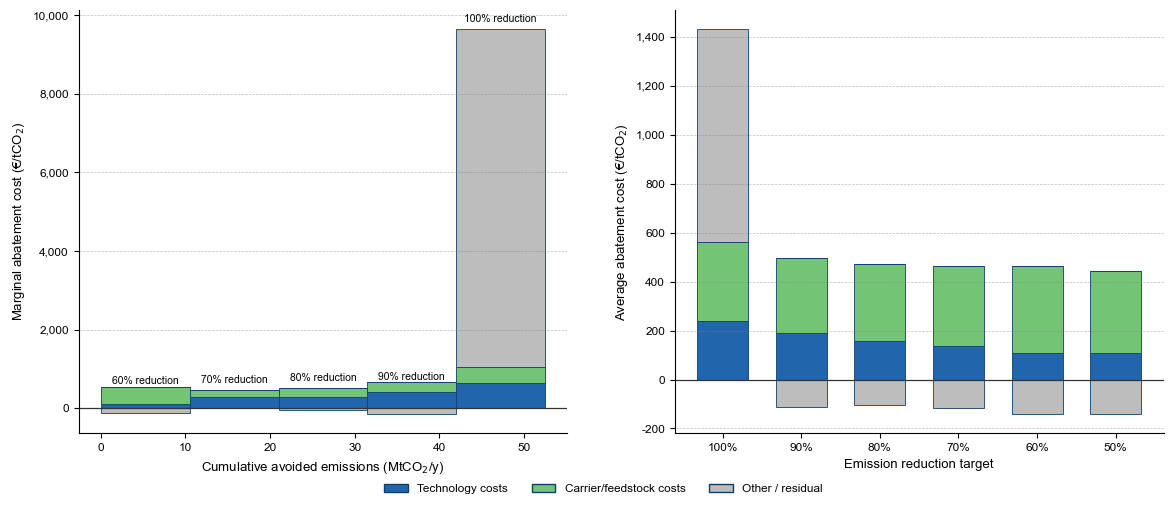

In [4]:
from __future__ import annotations

from pathlib import Path
import json
import re

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec


# =============================================================================
# User settings
# =============================================================================

INTERNAL_YEAR = "2022"

TECHNOLOGY_DATA_ROOT = Path(r"adopt_net0/database/templates/technology_data")

REFERENCE_H5_PATH = Path(r"output/base_case_00_5_dd/2050/optimization_results.h5")

H5_FILES = [
    Path(r"output/base_case_50_5_dd/2050/optimization_results.h5"),
    Path(r"output/base_case_60_5_dd/2050/optimization_results.h5"),
    Path(r"output/base_case_70_5_dd/2050/optimization_results.h5"),
    Path(r"output/base_case_80_5_dd/2050/optimization_results.h5"),
    Path(r"output/base_case_90_5_dd/2050/optimization_results.h5"),
    Path(r"output/base_case_5_dd/2050/optimization_results.h5"),  # 100%
]

EMISSION_COL = "emissions_net"

# Material feedstocks only.
# Electricity deliberately excluded: it will go into Other / residual.
CARRIER_FEEDSTOCK_CARRIERS = {
    # Electricity
    "electricity",
    "electricity_grid",

    # Fossil feedstocks
    "methane",
    "naphtha",
    "feedgas",
    "crackergas",

    # Bio / circular feedstocks
    "methane_bio",
    "naphtha_bio",
    "biomass",
    "MPW",

    # CO2 carriers
    "CO2",
    "CO2captured",
}

COST_COMPONENTS = [
    "Technology costs",
    "Carrier/feedstock costs",
    "Other / residual",
]

COMPONENT_COLORS = {
    "Technology costs": "#2166AC",
    "Carrier/feedstock costs": "#74C476",
    "Other / residual": "#BDBDBD",
}

OUTPUT_DIR = Path("figure")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# HDF5 helpers
# =============================================================================

def _to_scalar(x):
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")

    if isinstance(x, np.generic):
        value = x.item()
        return value.decode("utf-8") if isinstance(value, (bytes, bytearray)) else value

    x = np.asarray(x)
    if x.shape == () or x.size == 1:
        value = x.reshape(-1)[0].item()
        return value.decode("utf-8") if isinstance(value, (bytes, bytearray)) else value

    return x


def read_summary_scalar(h5_path: str | Path, name: str) -> float:
    h5_path = Path(h5_path)
    ds_path = f"summary/{name}"

    with h5py.File(h5_path, "r") as h5:
        if ds_path not in h5:
            raise KeyError(f"Dataset '{ds_path}' not found in {h5_path}")
        return float(_to_scalar(h5[ds_path][()]))


def infer_reduction_from_path(h5_path: str | Path) -> float | None:
    """
    Examples:
        base_case_50_5_dd -> 50
        base_case_90_5_dd -> 90
        base_case_5_dd    -> 100
        base_case_00_5_dd -> 0
    """
    path_str = str(h5_path).replace("\\", "/")

    match = re.search(r"base_case_(\d+)_5_dd", path_str)
    if match:
        return float(match.group(1))

    if "base_case_5_dd" in path_str:
        return 100.0

    return None


def scenario_label_from_path(h5_path: str | Path) -> str:
    reduction = infer_reduction_from_path(h5_path)
    if reduction is not None:
        return f"{reduction:.0f}% reduction"
    return Path(h5_path).parent.parent.name


def annualise_timeseries(values: np.ndarray, factors: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    factors = np.asarray(factors, dtype=float)

    if values.shape == factors.shape:
        return float(np.sum(values * factors))

    if values.ndim == 1 and len(values) == len(factors):
        return float(np.sum(values * factors))

    return float(np.nansum(values))


# =============================================================================
# Existing CAPEX correction
# =============================================================================

def annualise_capex(unit_capex: float, size: float, discount_rate: float, lifetime: int) -> float:
    r = float(discount_rate)
    n = int(lifetime)

    if n <= 0:
        raise ValueError(f"Invalid lifetime: {n}")

    if abs(r) < 1e-12:
        crf = 1.0 / n
    else:
        crf = r * (1 + r) ** n / ((1 + r) ** n - 1)

    return float(unit_capex) * float(size) * crf


def find_json_recursive(technology_data_root: str | Path, technology_name: str) -> Path | None:
    root = Path(technology_data_root)
    matches = list(root.rglob(f"{technology_name}.json"))

    if not matches:
        return None

    if len(matches) > 1:
        print(f"[Warning] Multiple JSON files found for {technology_name}. Using: {matches[0]}")

    return matches[0]


def load_existing_annualised_capex(
    h5_path: str | Path,
    technology_data_root: str | Path,
    internal_year: str = INTERNAL_YEAR,
) -> pd.DataFrame:
    h5_path = Path(h5_path)
    base_path = f"design/nodes/{internal_year}"
    rows = []

    with h5py.File(h5_path, "r") as h5:
        if base_path not in h5:
            raise KeyError(f"Path '{base_path}' not found in {h5_path}")

        for node in h5[base_path].keys():
            for component in h5[base_path][node].keys():
                if not component.endswith("_existing"):
                    continue

                size_path = f"{base_path}/{node}/{component}/size"
                if size_path not in h5:
                    print(f"[Warning] Missing size for {node}/{component}. Skipping.")
                    continue

                size = float(_to_scalar(h5[size_path][()]))

                base_component = component[: -len("_existing")]
                json_path = find_json_recursive(technology_data_root, base_component)

                if json_path is None:
                    print(f"[Warning] JSON not found for '{base_component}'. Existing CAPEX set to zero.")
                    continue

                with open(json_path, "r") as f:
                    tech_data = json.load(f)

                economics = tech_data["Economics"]
                unit_capex = float(economics["unit_capex"])
                discount_rate = float(economics["discount_rate"])
                lifetime = int(economics["lifetime"])

                annualised = annualise_capex(
                    unit_capex=unit_capex,
                    size=size,
                    discount_rate=discount_rate,
                    lifetime=lifetime,
                )

                rows.append({
                    "node": str(node),
                    "component": str(component),
                    "annualised_capex_existing": annualised,
                })

    return pd.DataFrame(rows)


# =============================================================================
# Technology costs
# =============================================================================

def create_technology_base_df(
    h5_path: str | Path,
    internal_year: str = INTERNAL_YEAR,
) -> pd.DataFrame:
    h5_path = Path(h5_path)
    base_path = f"design/nodes/{internal_year}"
    rows = []

    with h5py.File(h5_path, "r") as h5:
        if base_path not in h5:
            raise KeyError(f"Path '{base_path}' not found in {h5_path}")

        for node in h5[base_path].keys():
            for component in h5[base_path][node].keys():
                rows.append({
                    "node": str(node),
                    "component": str(component),
                })

    return pd.DataFrame(rows)


def load_design_dataset(
    h5_path: str | Path,
    dataset_name: str,
    internal_year: str = INTERNAL_YEAR,
    base_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    h5_path = Path(h5_path)
    base_path = f"design/nodes/{internal_year}"

    df = base_df.copy() if base_df is not None else create_technology_base_df(h5_path, internal_year)
    df[dataset_name] = np.nan

    with h5py.File(h5_path, "r") as h5:
        if base_path not in h5:
            raise KeyError(f"Path '{base_path}' not found in {h5_path}")

        for node in h5[base_path].keys():
            for component in h5[base_path][node].keys():
                ds_path = f"{base_path}/{node}/{component}/{dataset_name}"

                if ds_path not in h5:
                    continue

                value = float(_to_scalar(h5[ds_path][()]))
                mask = (df["node"] == str(node)) & (df["component"] == str(component))
                df.loc[mask, dataset_name] = value

    return df


def compute_technology_cost_total(
    h5_path: str | Path,
    technology_data_root: str | Path,
    internal_year: str = INTERNAL_YEAR,
    include_existing_capex: bool = True,
) -> float:
    """
    Technology costs = capex_tot + opex_fixed + opex_variable,
    with existing CAPEX reconstructed from JSONs.
    """
    df = create_technology_base_df(h5_path, internal_year)

    for col in ["capex_tot", "opex_fixed", "opex_variable"]:
        df = load_design_dataset(
            h5_path=h5_path,
            dataset_name=col,
            internal_year=internal_year,
            base_df=df,
        )

    if include_existing_capex:
        existing = load_existing_annualised_capex(
            h5_path=h5_path,
            technology_data_root=technology_data_root,
            internal_year=internal_year,
        )

        if not existing.empty:
            df = df.merge(
                existing,
                on=["node", "component"],
                how="left",
            )

            mask_existing = df["annualised_capex_existing"].notna()
            df.loc[mask_existing, "capex_tot"] = df.loc[mask_existing, "annualised_capex_existing"]
            df = df.drop(columns=["annualised_capex_existing"])

    df["capex_tot"] = df["capex_tot"].fillna(0.0)
    df["opex_fixed"] = df["opex_fixed"].fillna(0.0)
    df["opex_variable"] = df["opex_variable"].fillna(0.0)

    df["annual_cost"] = df["capex_tot"] + df["opex_fixed"] + df["opex_variable"]

    return float(df["annual_cost"].sum())


def compute_existing_capex_addition(
    h5_path: str | Path,
    technology_data_root: str | Path,
    internal_year: str = INTERNAL_YEAR,
) -> float:
    existing = load_existing_annualised_capex(
        h5_path=h5_path,
        technology_data_root=technology_data_root,
        internal_year=internal_year,
    )

    if existing.empty:
        return 0.0

    return float(existing["annualised_capex_existing"].sum())


# =============================================================================
# Feedstock costs
# =============================================================================

def compute_carrier_feedstock_net_cost_total(
    h5_path: str | Path,
    carriers: set[str] = CARRIER_FEEDSTOCK_CARRIERS,
    internal_year: str = INTERNAL_YEAR,
) -> float:
    """
    Carrier/feedstock costs for selected carriers.

    For each selected carrier:
        import_cost = sum_t(import[t] * import_price[t] * factor[t])
        export_revenue = sum_t(export[t] * export_price[t] * factor[t])

    Net cost:
        carrier_net_cost = import_cost - export_revenue

    This includes:
      - material feedstock imports;
      - electricity imports;
      - CO2 export/storage costs or credits, depending on export_price sign.

    If CO2 export_price is negative, export_revenue is negative and therefore
    subtracting it increases total cost, as expected for storage/export costs.
    """
    h5_path = Path(h5_path)

    with h5py.File(h5_path, "r") as h5:
        factors_path = f"k_means_specs/{internal_year}/factors"
        eb_base = f"operation/energy_balance/{internal_year}"

        if factors_path not in h5:
            raise KeyError(f"Missing path: {factors_path}")

        if eb_base not in h5:
            raise KeyError(f"Missing path: {eb_base}")

        factors = np.asarray(h5[factors_path][()], dtype=float)

        total_net_cost = 0.0

        for node in h5[eb_base].keys():
            node_group = h5[eb_base][node]

            for carrier in carriers:
                if carrier not in node_group:
                    continue

                carrier_group = node_group[carrier]

                # Import side
                if "import" in carrier_group and "import_price" in carrier_group:
                    imp = np.asarray(carrier_group["import"][()], dtype=float)
                    imp_price = np.asarray(carrier_group["import_price"][()], dtype=float)
                    import_cost = annualise_timeseries(imp * imp_price, factors)
                else:
                    import_cost = 0.0

                # Export side
                if "export" in carrier_group and "export_price" in carrier_group:
                    exp = np.asarray(carrier_group["export"][()], dtype=float)
                    exp_price = np.asarray(carrier_group["export_price"][()], dtype=float)
                    export_revenue = annualise_timeseries(exp * exp_price, factors)
                else:
                    export_revenue = 0.0

                total_net_cost += import_cost - export_revenue

    return float(total_net_cost)


# =============================================================================
# Scenario cost breakdown
# =============================================================================

def compute_cost_breakdown_one_file(
    h5_path: str | Path,
    technology_data_root: str | Path,
    internal_year: str = INTERNAL_YEAR,
    emission_col: str = EMISSION_COL,
) -> dict:
    h5_path = Path(h5_path)

    total_cost_raw = read_summary_scalar(h5_path, "total_cost")
    emissions = read_summary_scalar(h5_path, emission_col)

    existing_capex_addition = compute_existing_capex_addition(
        h5_path=h5_path,
        technology_data_root=technology_data_root,
        internal_year=internal_year,
    )

    total_cost_with_existing = total_cost_raw + existing_capex_addition

    technology_cost = compute_technology_cost_total(
        h5_path=h5_path,
        technology_data_root=technology_data_root,
        internal_year=internal_year,
        include_existing_capex=True,
    )

    carrier_feedstock_cost = compute_carrier_feedstock_net_cost_total(
        h5_path=h5_path,
        carriers=CARRIER_FEEDSTOCK_CARRIERS,
        internal_year=internal_year,
    )

    other_residual = total_cost_with_existing - technology_cost - carrier_feedstock_cost

    return {
        "h5_path": str(h5_path),
        "scenario": scenario_label_from_path(h5_path),
        "reduction_target": infer_reduction_from_path(h5_path),
        "emissions": emissions,
        "total_cost_raw": total_cost_raw,
        "existing_capex_addition": existing_capex_addition,
        "total_cost_with_existing": total_cost_with_existing,
        "Technology costs": technology_cost,
        "Carrier/feedstock costs": carrier_feedstock_cost,
        "Other / residual": other_residual,
    }


def build_cost_breakdown(
    h5_files: list[str | Path],
    technology_data_root: str | Path,
    internal_year: str = INTERNAL_YEAR,
    emission_col: str = EMISSION_COL,
) -> pd.DataFrame:
    rows = []

    for h5_path in h5_files:
        h5_path = Path(h5_path)

        if not h5_path.exists():
            print(f"[Warning] File not found, skipped: {h5_path}")
            continue

        rows.append(
            compute_cost_breakdown_one_file(
                h5_path=h5_path,
                technology_data_root=technology_data_root,
                internal_year=internal_year,
                emission_col=emission_col,
            )
        )

    if not rows:
        raise FileNotFoundError("No valid H5 files were found.")

    df = pd.DataFrame(rows)

    if df["reduction_target"].notna().all():
        df = df.sort_values("reduction_target", ascending=True)
    else:
        df = df.sort_values("emissions", ascending=False)

    return df.reset_index(drop=True)


# =============================================================================
# Decomposed MACC and average abatement cost
# =============================================================================

def compute_decomposed_macc(
    scenario_df: pd.DataFrame,
    components: list[str] = COST_COMPONENTS,
) -> pd.DataFrame:
    """
    Computes component-wise MAC contributions:
        contribution_k = (C_k,current - C_k,previous) / avoided_emissions
    """
    d = scenario_df.copy().reset_index(drop=True)

    rows = []

    for i in range(1, len(d)):
        prev = d.loc[i - 1]
        curr = d.loc[i]

        avoided = prev["emissions"] - curr["emissions"]

        if avoided <= 0:
            print(
                "[Warning] Non-positive avoided emissions between "
                f"{prev['scenario']} and {curr['scenario']}. Step skipped."
            )
            continue

        row = {
            "from_scenario": prev["scenario"],
            "to_scenario": curr["scenario"],
            "step_label": f"{prev['scenario']} -> {curr['scenario']}",
            "emissions_from": prev["emissions"],
            "emissions_to": curr["emissions"],
            "avoided_emissions": avoided,
            "delta_total_cost": curr["total_cost_with_existing"] - prev["total_cost_with_existing"],
            "macc_total": (
                curr["total_cost_with_existing"] - prev["total_cost_with_existing"]
            ) / avoided,
        }

        for comp in components:
            delta = curr[comp] - prev[comp]
            row[f"delta_{comp}"] = delta
            row[f"macc_{comp}"] = delta / avoided

        rows.append(row)

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out["cumulative_avoided_emissions"] = out["avoided_emissions"].cumsum()
    out["x_left"] = out["cumulative_avoided_emissions"] - out["avoided_emissions"]
    out["x_center"] = out["x_left"] + 0.5 * out["avoided_emissions"]

    return out


def compute_decomposed_average_abatement(
    scenario_df: pd.DataFrame,
    reference_row: pd.Series,
    components: list[str] = COST_COMPONENTS,
) -> pd.DataFrame:
    """
    Computes component-wise average abatement cost:
        contribution_k = (C_k,scenario - C_k,reference) / avoided_emissions_vs_reference
    """
    d = scenario_df.copy()

    rows = []

    for _, row_in in d.iterrows():
        avoided = reference_row["emissions"] - row_in["emissions"]

        row = row_in.to_dict()
        row["avoided_emissions_vs_reference"] = avoided
        row["delta_total_cost_vs_reference"] = (
            row_in["total_cost_with_existing"] - reference_row["total_cost_with_existing"]
        )

        if avoided <= 0:
            row["aac_total"] = np.nan
            for comp in components:
                row[f"aac_{comp}"] = np.nan
                row[f"delta_{comp}_vs_reference"] = np.nan
        else:
            row["aac_total"] = row["delta_total_cost_vs_reference"] / avoided

            for comp in components:
                delta = row_in[comp] - reference_row[comp]
                row[f"delta_{comp}_vs_reference"] = delta
                row[f"aac_{comp}"] = delta / avoided

        rows.append(row)

    out = pd.DataFrame(rows)
    out = out.sort_values("reduction_target", ascending=False).reset_index(drop=True)

    return out


# =============================================================================
# Plotting helpers
# =============================================================================

def stacked_pos_neg_bar(
    ax,
    x,
    values_by_component: dict[str, np.ndarray],
    widths=None,
    align="center",
    colors: dict[str, str] = COMPONENT_COLORS,
    edgecolor="#0D3F6B",
    linewidth=0.6,
):
    """
    Draw stacked bars allowing positive and negative segments.
    """
    n = len(x)

    if widths is None:
        widths = np.full(n, 0.7, dtype=float)
    else:
        widths = np.asarray(widths, dtype=float)

    pos_bottom = np.zeros(n, dtype=float)
    neg_bottom = np.zeros(n, dtype=float)

    for comp in COST_COMPONENTS:
        values = np.asarray(values_by_component[comp], dtype=float)

        pos = np.where(values > 0, values, 0.0)
        neg = np.where(values < 0, values, 0.0)

        ax.bar(
            x,
            pos,
            width=widths,
            bottom=pos_bottom,
            align=align,
            color=colors.get(comp, "#999999"),
            edgecolor=edgecolor,
            linewidth=linewidth,
            label=comp,
        )

        ax.bar(
            x,
            neg,
            width=widths,
            bottom=neg_bottom,
            align=align,
            color=colors.get(comp, "#999999"),
            edgecolor=edgecolor,
            linewidth=linewidth,
        )

        pos_bottom += pos
        neg_bottom += neg

    return pos_bottom, neg_bottom


def plot_decomposed_macc_and_aac(
    macc_df: pd.DataFrame,
    aac_df: pd.DataFrame,
    components: list[str] = COST_COMPONENTS,
    emission_scale: float = 1e6,
    emission_scale_label: str = "MtCO$_2$/y",
    figsize: tuple[float, float] = (14, 5.5),
    save_path: str | Path | None = OUTPUT_DIR / "CO2_abatement_cost_decomposed.png",
    dpi: int = 600,
):
    BAR_EDGE = "#0D3F6B"
    ZERO_COLOR = "#333333"

    FS_LABEL = 9.5
    FS_TICK = 8.5
    FS_LEGEND = 8.5
    FS_ANNOT = 7.5

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
    })

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 2, figure=fig, wspace=0.22)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])

    # -------------------------------------------------------------------------
    # Panel A: decomposed MACC
    # -------------------------------------------------------------------------
    d1 = macc_df.copy()

    x_left = d1["x_left"].values / emission_scale
    widths = d1["avoided_emissions"].values / emission_scale

    values_by_component = {
        comp: d1[f"macc_{comp}"].values
        for comp in components
    }

    stacked_pos_neg_bar(
        ax=ax1,
        x=x_left,
        values_by_component=values_by_component,
        widths=widths,
        align="edge",
        colors=COMPONENT_COLORS,
        edgecolor=BAR_EDGE,
        linewidth=0.6,
    )

    ax1.axhline(0, color=ZERO_COLOR, linewidth=0.9)

    ax1.set_xlabel(f"Cumulative avoided emissions ({emission_scale_label})", fontsize=FS_LABEL)
    ax1.set_ylabel("Marginal abatement cost (€/tCO$_2$)", fontsize=FS_LABEL)

    ax1.tick_params(labelsize=FS_TICK)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax1.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5, color="grey")

    # Total MAC labels
    h_max = max(np.nanmax(np.abs(d1["macc_total"].values)), 1.0)
    offset = 0.015 * h_max

    for _, row in d1.iterrows():
        x = (row["x_left"] + 0.5 * row["avoided_emissions"]) / emission_scale
        y = row["macc_total"]
        ax1.text(
            x,
            y + offset if y >= 0 else y - offset,
            row["to_scenario"],
            ha="center",
            va="bottom" if y >= 0 else "top",
            fontsize=FS_ANNOT,
        )

    # -------------------------------------------------------------------------
    # Panel B: decomposed average abatement cost
    # -------------------------------------------------------------------------
    d2 = aac_df.dropna(subset=["aac_total", "reduction_target"]).copy()
    d2 = d2.sort_values("reduction_target", ascending=False).reset_index(drop=True)

    x = np.arange(len(d2))

    values_by_component = {
        comp: d2[f"aac_{comp}"].values
        for comp in components
    }

    stacked_pos_neg_bar(
        ax=ax2,
        x=x,
        values_by_component=values_by_component,
        widths=np.full(len(d2), 0.65),
        align="center",
        colors=COMPONENT_COLORS,
        edgecolor=BAR_EDGE,
        linewidth=0.6,
    )

    ax2.axhline(0, color=ZERO_COLOR, linewidth=0.9)

    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{v:.0f}%" for v in d2["reduction_target"]], fontsize=FS_TICK)
    ax2.set_xlabel("Emission reduction target", fontsize=FS_LABEL)
    ax2.set_ylabel("Average abatement cost (€/tCO$_2$)", fontsize=FS_LABEL)

    ax2.tick_params(labelsize=FS_TICK)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax2.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5, color="grey")

    # Shared legend
    handles = [
        mpatches.Patch(
            facecolor=COMPONENT_COLORS.get(comp, "#999999"),
            edgecolor=BAR_EDGE,
            label=comp,
        )
        for comp in components
    ]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=len(handles),
        frameon=False,
        fontsize=FS_LEGEND,
        bbox_to_anchor=(0.5, -0.02),
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])

    if save_path is not None:
        save_path = Path(save_path)
        # fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        # fig.savefig(save_path.with_suffix(".pdf"), bbox_inches="tight")
        print(f"Saved figure: {save_path}")
        print(f"Saved figure: {save_path.with_suffix('.pdf')}")

    plt.show()

    return fig


# =============================================================================
# Main
# =============================================================================

if __name__ == "__main__":
    h5_files = [Path(p) for p in H5_FILES if Path(p).exists()]

    if not h5_files:
        raise FileNotFoundError("No H5 scenario files found. Check H5_FILES.")

    # Scenario breakdown
    scenario_df = build_cost_breakdown(
        h5_files=h5_files,
        technology_data_root=TECHNOLOGY_DATA_ROOT,
        internal_year=INTERNAL_YEAR,
        emission_col=EMISSION_COL,
    )

    # Reference breakdown
    reference_df = build_cost_breakdown(
        h5_files=[REFERENCE_H5_PATH],
        technology_data_root=TECHNOLOGY_DATA_ROOT,
        internal_year=INTERNAL_YEAR,
        emission_col=EMISSION_COL,
    )
    reference_row = reference_df.iloc[0]

    # Decomposed costs
    macc_decomp = compute_decomposed_macc(
        scenario_df=scenario_df,
        components=COST_COMPONENTS,
    )

    aac_decomp = compute_decomposed_average_abatement(
        scenario_df=scenario_df,
        reference_row=reference_row,
        components=COST_COMPONENTS,
    )

    # Diagnostics
    # scenario_df.to_csv("abatement_cost_breakdown_by_scenario.csv", index=False)
    # macc_decomp.to_csv("abatement_cost_decomposed_macc.csv", index=False)
    # aac_decomp.to_csv("abatement_cost_decomposed_average.csv", index=False)

    print("\n=== Scenario cost breakdown ===")
    print(
        scenario_df[
            [
                "scenario",
                "reduction_target",
                "emissions",
                "total_cost_with_existing",
                "Technology costs",
                "Carrier/feedstock costs",
                "Other / residual",
            ]
        ]
    )

    print("\n=== Decomposed MACC ===")
    print(
        macc_decomp[
            [
                "from_scenario",
                "to_scenario",
                "avoided_emissions",
                "macc_total",
                "macc_Technology costs",
                "macc_Carrier/feedstock costs",
                "macc_Other / residual",
            ]
        ]
    )

    print("\n=== Decomposed average abatement cost ===")
    print(
        aac_decomp[
            [
                "scenario",
                "reduction_target",
                "avoided_emissions_vs_reference",
                "aac_total",
                "aac_Technology costs",
                "aac_Carrier/feedstock costs",
                "aac_Other / residual",
            ]
        ]
    )

    plot_decomposed_macc_and_aac(
        macc_df=macc_decomp,
        aac_df=aac_decomp,
        components=COST_COMPONENTS,
        save_path=OUTPUT_DIR / "CO2_abatement_cost_decomposed.png",
    )